In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:2px;}
div.CodeMirror {font-family:Consolas; font-size:10pt;}
div.text_cell_render.rendered_html{font-size:10pt;}
div.output {font-size:10pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:10pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:10pt;padding:4px;}
table.dataframe{font-size:10px;}
</style>
"""))

In [ ]:
# 값에 마이너스가 나오면 안된다
# 아직도 예측 데이터가 안나온다


Importing plotly failed. Interactive plots will not work.


국적 입력 (없으면 Enter): 중국
목적 입력 (없으면 Enter): 

▶️ 공용 처리 시작

📊 [XGBoost 평가 지표]
MSE : 5144.58
RMSE: 71.73
R²  : 0.8147


,연월,실제값,예측값
0,2021-07,16,17.303411
1,2021-08,31,17.303411
2,2021-09,8,19.707922
3,2021-10,3,19.068449
4,2021-11,6,18.267553
5,2021-12,5,14.618917
6,2022-01,8,6.146969
7,2022-02,3,6.146969
8,2022-03,5,25.475943
9,2022-04,3,24.836470


16:30:17 - cmdstanpy - INFO - Chain [1] start processing
16:30:17 - cmdstanpy - INFO - Chain [1] done processing


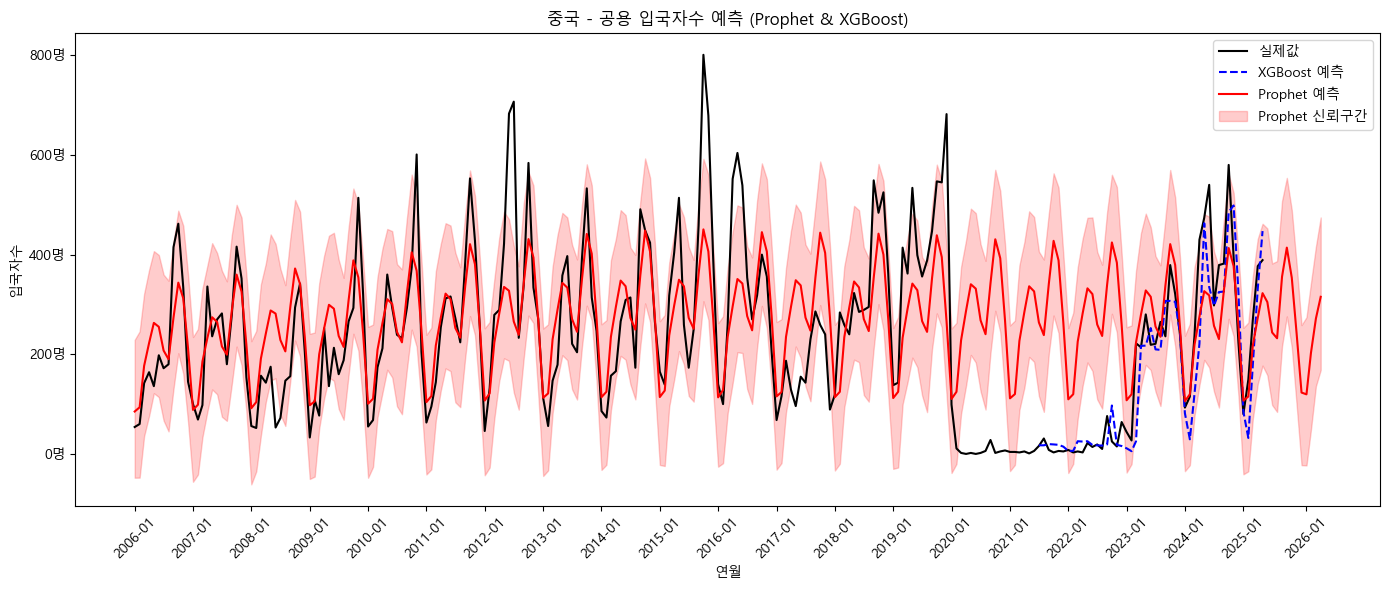


▶️ 관광 처리 시작

📊 [XGBoost 평가 지표]
MSE : 7682512907.50
RMSE: 87649.95
R²  : 0.6320


,연월,실제값,예측값
0,2021-07,1031,6690.448730
1,2021-08,1011,6690.448730
2,2021-09,1264,3065.618164
3,2021-10,1366,3065.618164
4,2021-11,1700,1997.790161
5,2021-12,2151,2142.363281
6,2022-01,1641,3065.618164
7,2022-02,1194,3065.618164
8,2022-03,1480,4507.490234
9,2022-04,1857,4507.490234


16:30:18 - cmdstanpy - INFO - Chain [1] start processing
16:30:18 - cmdstanpy - INFO - Chain [1] done processing


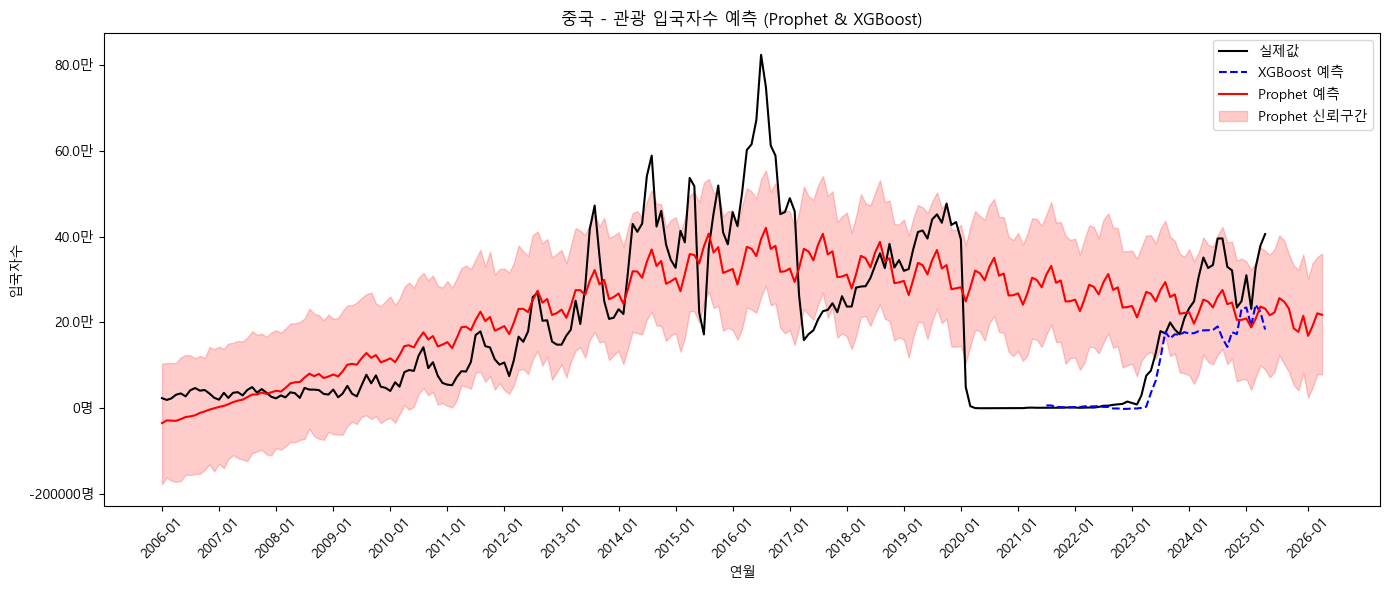


▶️ 상용 처리 시작

📊 [XGBoost 평가 지표]
MSE : 3096820.04
RMSE: 1759.78
R²  : -0.6238


,연월,실제값,예측값
0,2021-07,277,511.247620
1,2021-08,270,511.247620
2,2021-09,354,571.250610
3,2021-10,322,571.250610
4,2021-11,382,571.250610
5,2021-12,283,571.250610
6,2022-01,170,377.705902
7,2022-02,381,377.705902
8,2022-03,303,693.416260
9,2022-04,318,571.250610


16:30:19 - cmdstanpy - INFO - Chain [1] start processing
16:30:19 - cmdstanpy - INFO - Chain [1] done processing


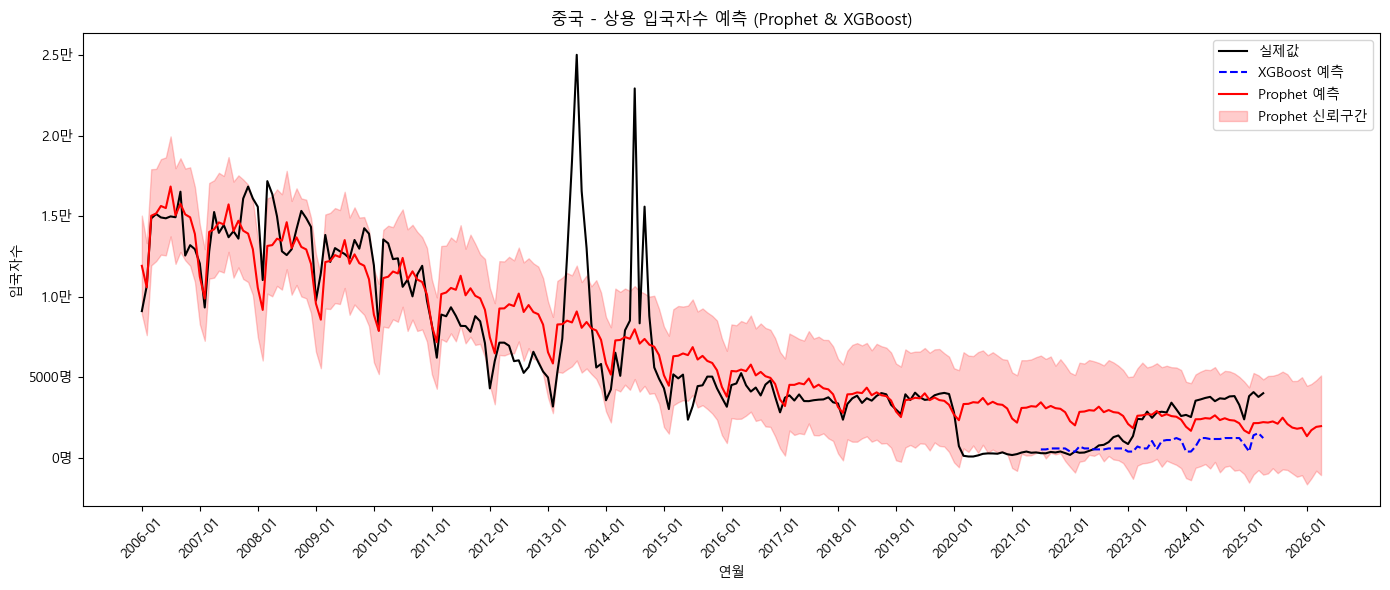


▶️ 유학연수 처리 시작

📊 [XGBoost 평가 지표]
MSE : 84933253.33
RMSE: 9215.92
R²  : 0.4009


,연월,실제값,예측값
0,2021-07,1063,1691.799438
1,2021-08,9031,2542.035645
2,2021-09,7217,4951.700195
3,2021-10,1639,2551.909180
4,2021-11,1035,1804.772705
5,2021-12,848,1441.222900
6,2022-01,264,1962.665283
7,2022-02,7881,5319.472168
8,2022-03,5366,5407.401367
9,2022-04,1034,2649.961914


16:30:20 - cmdstanpy - INFO - Chain [1] start processing
16:30:20 - cmdstanpy - INFO - Chain [1] done processing


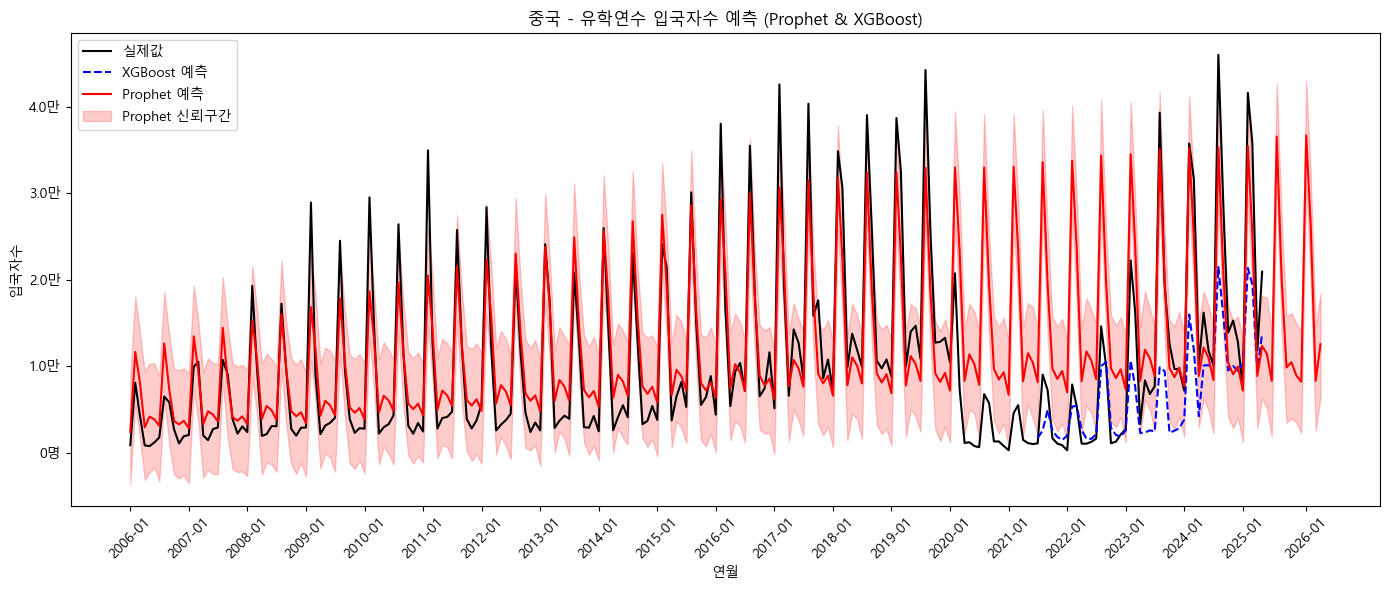

In [2]:
# ✅ [1] 라이브러리 임포트 및 설정
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from prophet import Prophet
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from IPython.display import display

plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# ✅ [2] 데이터 로드
df = pd.read_csv('../../jin/data/processed/외국인입국자_전처리완료_딥러닝용.csv', encoding='utf-8')

# ✅ [3] 사용자 입력
def get_valid_input(column_name, allow_blank=False):
    unique_vals = df[column_name].unique()
    while True:
        user_input = input(f"{column_name} 입력 (없으면 Enter): ").strip().lower().replace(' ', '')
        if allow_blank and user_input == "":
            return None
        match = None
        for val in unique_vals:
            val_clean = val.strip().lower().replace(' ', '')
            if user_input == val_clean:
                match = val
                break
        if match:
            return match
        else:
            print(f"❌ 일치하는 {column_name} 없음. 다시 입력.")

country = get_valid_input('국적')
purpose_input = get_valid_input('목적', allow_blank=True)

df = df[df['국적'] == country]
purpose_list = [purpose_input] if purpose_input else df['목적'].unique()

# ✅ [4] Label Encoding + 파생변수
le_season = LabelEncoder()
le_corona = LabelEncoder()
df['계절'] = le_season.fit_transform(df['계절'])
df['코로나기간'] = le_corona.fit_transform(df['코로나기간'])
df['연월'] = df['연도'].astype(str) + '-' + df['월'].astype(str).str.zfill(2)
df['성수기'] = df['월'].apply(lambda x: 1 if x in [7, 8, 12] else 0) * 1.5
df['명절'] = df['월'].apply(lambda x: 1 if x in [1, 2, 9, 10] else 0) * 2.0

def to_unit(x, pos):
    if x >= 10000:
        return f'{x/10000:.1f}만'
    else:
        return f'{int(x)}명'

# ✅ [5] 목적별 루프
for purpose in purpose_list:
    print(f"\n▶️ {purpose} 처리 시작")
    temp_df = df[df['목적'] == purpose]
    if temp_df.empty:
        print(f"⚠️ 데이터 없음: {purpose}")
        continue

    # 파생 변수
    temp_df = temp_df.copy()
    temp_df['lag_1'] = temp_df['입국자수'].shift(1)
    temp_df['lag_3'] = temp_df['입국자수'].shift(3)
    temp_df['lag_12'] = temp_df['입국자수'].shift(12)
    temp_df['입국자수_cumsum'] = temp_df['입국자수'].cumsum()
    temp_df = temp_df.dropna()

    features = [
        '연도', '월', '분기', '계절', '코로나기간', '성수기', '명절',
        'lag_1', 'lag_3', 'lag_12', '입국자수_cumsum'
    ]
    X = temp_df[features]
    y = temp_df['입국자수']
    ym = temp_df['연월'].reset_index(drop=True)

    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test, ym_train, ym_test = train_test_split(
        X_scaled, y, ym, test_size=0.2, random_state=42, shuffle=False
    )

    params = {'n_estimators': [100], 'learning_rate': [0.05], 'max_depth': [3]}
    grid = GridSearchCV(XGBRegressor(), params, cv=2)
    grid.fit(X_train, y_train)
    xgb_model = grid.best_estimator_

    y_pred = xgb_model.predict(X_test)

    # ✅ 오차 지표 계산
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    print(f"\n📊 [XGBoost 평가 지표]")
    print(f"MSE : {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²  : {r2:.4f}")

    # ✅ 예측값 표 출력
    results = pd.DataFrame({
        '연월': ym_test.values,
        '실제값': y_test.values,
        '예측값': y_pred
    })
    display(results.head(10))

    results['date'] = pd.to_datetime(results['연월'])
    temp_df['date'] = pd.to_datetime(temp_df['연월'])

    # ✅ Prophet 예측
    prophet_df = temp_df[['연월', '입국자수', '월', '코로나기간', '성수기', '명절']].copy()
    prophet_df.rename(columns={'연월': 'ds', '입국자수': 'y'}, inplace=True)
    prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])

    m = Prophet(yearly_seasonality=True, seasonality_mode='multiplicative')
    m.add_regressor('코로나기간')
    m.add_regressor('성수기')
    m.add_regressor('명절')
    m.fit(prophet_df)

    future = m.make_future_dataframe(periods=12, freq='M')
    future['월'] = future['ds'].dt.month
    future['코로나기간'] = 0
    future['성수기'] = future['월'].apply(lambda x: 1 if x in [7, 8, 12] else 0) * 1.5
    future['명절'] = future['월'].apply(lambda x: 1 if x in [1, 2, 9, 10] else 0) * 2.0

    forecast = m.predict(future)
    forecast['date'] = forecast['ds']

    # ✅ 시각화: 실제값, XGBoost, Prophet + 신뢰구간
    all_dates = pd.concat([temp_df['date'], forecast['date']]).drop_duplicates().sort_values()
    year_ticks = all_dates[all_dates.dt.month == 1]

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(temp_df['date'], temp_df['입국자수'], label='실제값', color='black')
    ax.plot(results['date'], results['예측값'], linestyle='--', label='XGBoost 예측', color='blue')
    ax.plot(forecast['date'], forecast['yhat'], linestyle='-', label='Prophet 예측', color='red')
    ax.fill_between(forecast['date'], forecast['yhat_lower'], forecast['yhat_upper'], 
                    color='red', alpha=0.2, label='Prophet 신뢰구간')

    ax.set_xticks(year_ticks)
    ax.set_xticklabels([d.strftime('%Y-%m') for d in year_ticks], rotation=45)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(to_unit))

    ax.set_title(f"{country} - {purpose} 입국자수 예측 (Prophet & XGBoost)")
    ax.set_xlabel('연월')
    ax.set_ylabel('입국자수')
    ax.legend()
    plt.tight_layout()
    plt.show()


Importing plotly failed. Interactive plots will not work.


국적 입력 (없으면 Enter): 중국
목적 입력 (없으면 Enter): 

▶️ 공용 처리 시작

📊 [XGBoost 평가 지표]
MSE (Mean Squared Error)  : 5144.58 → 낮을수록 좋음
RMSE (Root MSE)           : 71.73 → 낮을수록 좋음
R² (결정계수, 설명력)    : 0.8147 → 1에 가까울수록 좋음
📈 R² 해석 : 👍 양호


,연월,실제값,예측값
0,2021-07,16,17.303411
1,2021-08,31,17.303411
2,2021-09,8,19.707922
3,2021-10,3,19.068449
4,2021-11,6,18.267553
5,2021-12,5,14.618917
6,2022-01,8,6.146969
7,2022-02,3,6.146969
8,2022-03,5,25.475943
9,2022-04,3,24.836470


16:37:57 - cmdstanpy - INFO - Chain [1] start processing
16:37:57 - cmdstanpy - INFO - Chain [1] done processing


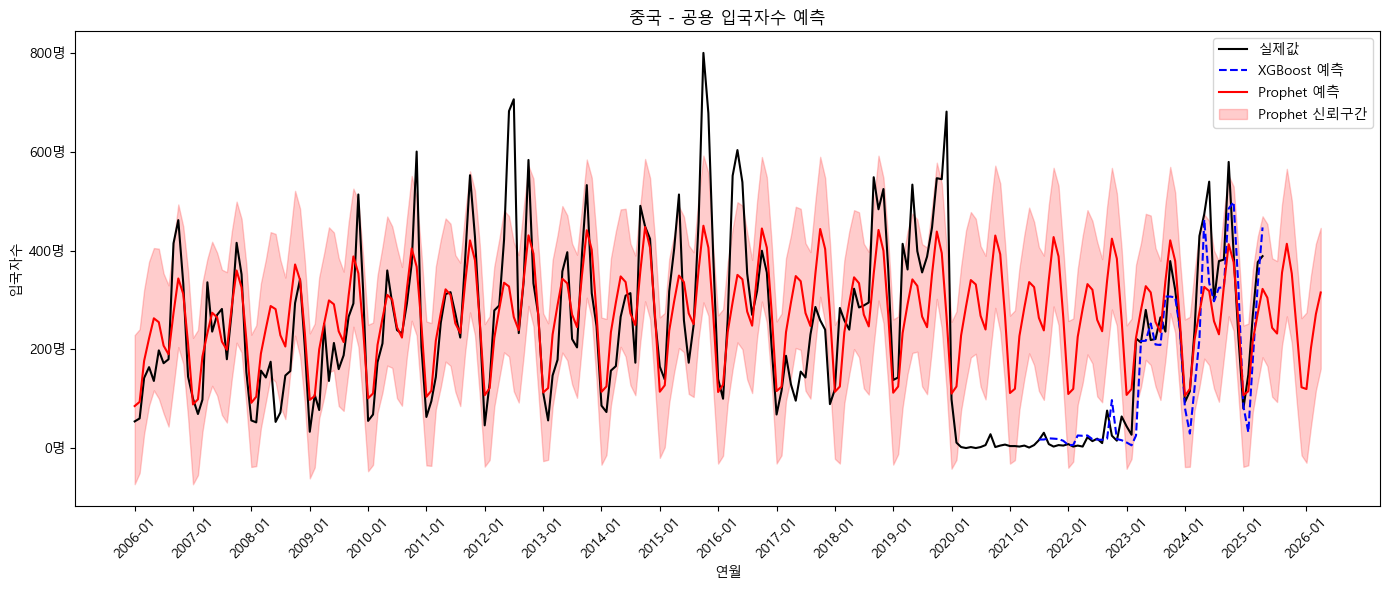


▶️ 관광 처리 시작

📊 [XGBoost 평가 지표]
MSE (Mean Squared Error)  : 7682512907.50 → 낮을수록 좋음
RMSE (Root MSE)           : 87649.95 → 낮을수록 좋음
R² (결정계수, 설명력)    : 0.6320 → 1에 가까울수록 좋음
📈 R² 해석 : ⚠️ 보통


,연월,실제값,예측값
0,2021-07,1031,6690.448730
1,2021-08,1011,6690.448730
2,2021-09,1264,3065.618164
3,2021-10,1366,3065.618164
4,2021-11,1700,1997.790161
5,2021-12,2151,2142.363281
6,2022-01,1641,3065.618164
7,2022-02,1194,3065.618164
8,2022-03,1480,4507.490234
9,2022-04,1857,4507.490234


16:37:57 - cmdstanpy - INFO - Chain [1] start processing
16:37:58 - cmdstanpy - INFO - Chain [1] done processing


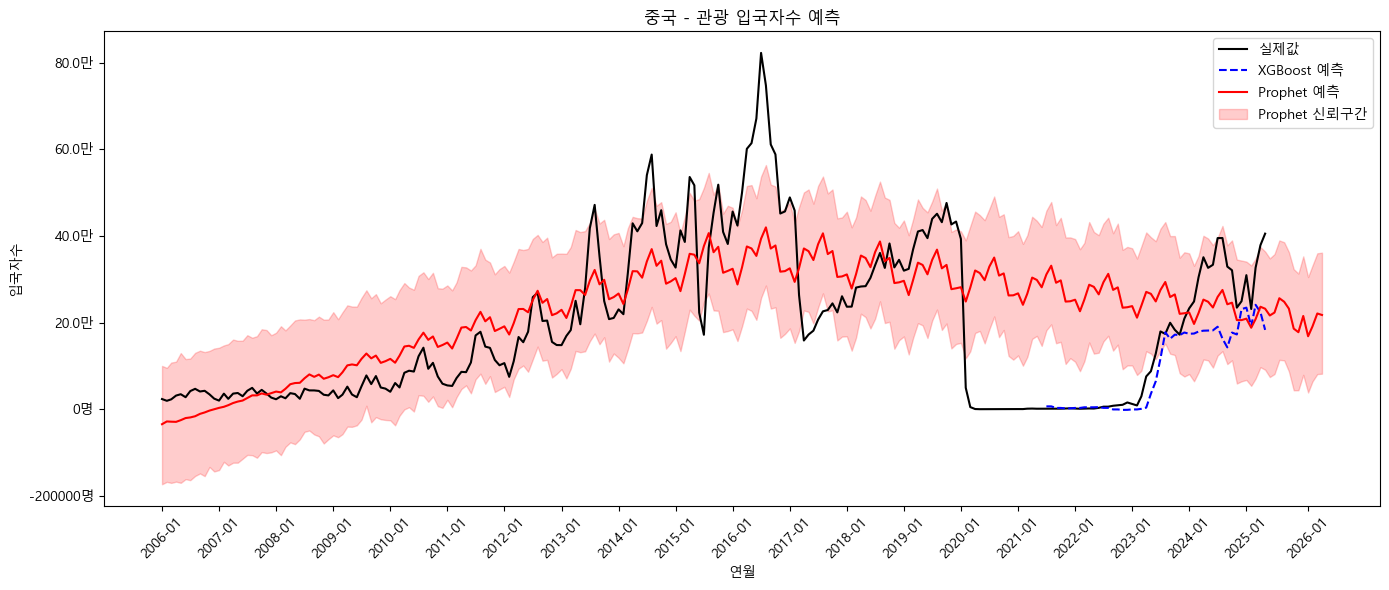


▶️ 상용 처리 시작

📊 [XGBoost 평가 지표]
MSE (Mean Squared Error)  : 3096820.04 → 낮을수록 좋음
RMSE (Root MSE)           : 1759.78 → 낮을수록 좋음
R² (결정계수, 설명력)    : -0.6238 → 1에 가까울수록 좋음
📈 R² 해석 : ❗ 낮음 (개선 필요)


,연월,실제값,예측값
0,2021-07,277,511.247620
1,2021-08,270,511.247620
2,2021-09,354,571.250610
3,2021-10,322,571.250610
4,2021-11,382,571.250610
5,2021-12,283,571.250610
6,2022-01,170,377.705902
7,2022-02,381,377.705902
8,2022-03,303,693.416260
9,2022-04,318,571.250610


16:37:58 - cmdstanpy - INFO - Chain [1] start processing
16:37:58 - cmdstanpy - INFO - Chain [1] done processing


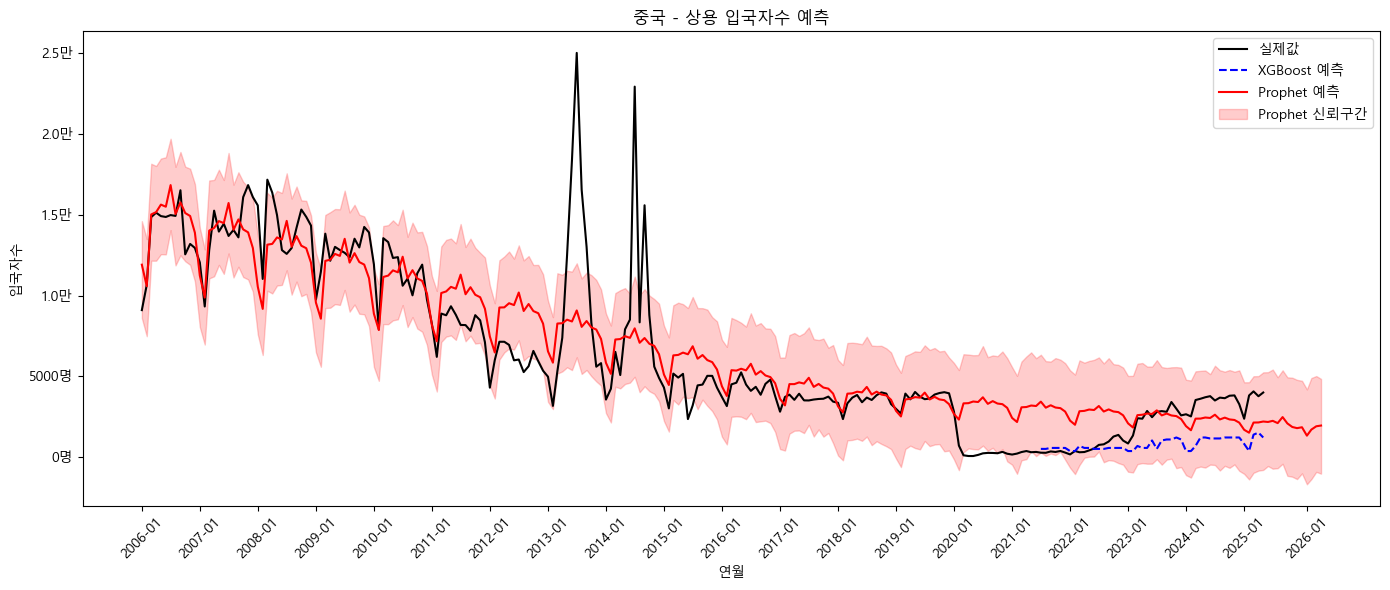


▶️ 유학연수 처리 시작

📊 [XGBoost 평가 지표]
MSE (Mean Squared Error)  : 84933253.33 → 낮을수록 좋음
RMSE (Root MSE)           : 9215.92 → 낮을수록 좋음
R² (결정계수, 설명력)    : 0.4009 → 1에 가까울수록 좋음
📈 R² 해석 : ❗ 낮음 (개선 필요)


,연월,실제값,예측값
0,2021-07,1063,1691.799438
1,2021-08,9031,2542.035645
2,2021-09,7217,4951.700195
3,2021-10,1639,2551.909180
4,2021-11,1035,1804.772705
5,2021-12,848,1441.222900
6,2022-01,264,1962.665283
7,2022-02,7881,5319.472168
8,2022-03,5366,5407.401367
9,2022-04,1034,2649.961914


16:37:59 - cmdstanpy - INFO - Chain [1] start processing
16:37:59 - cmdstanpy - INFO - Chain [1] done processing


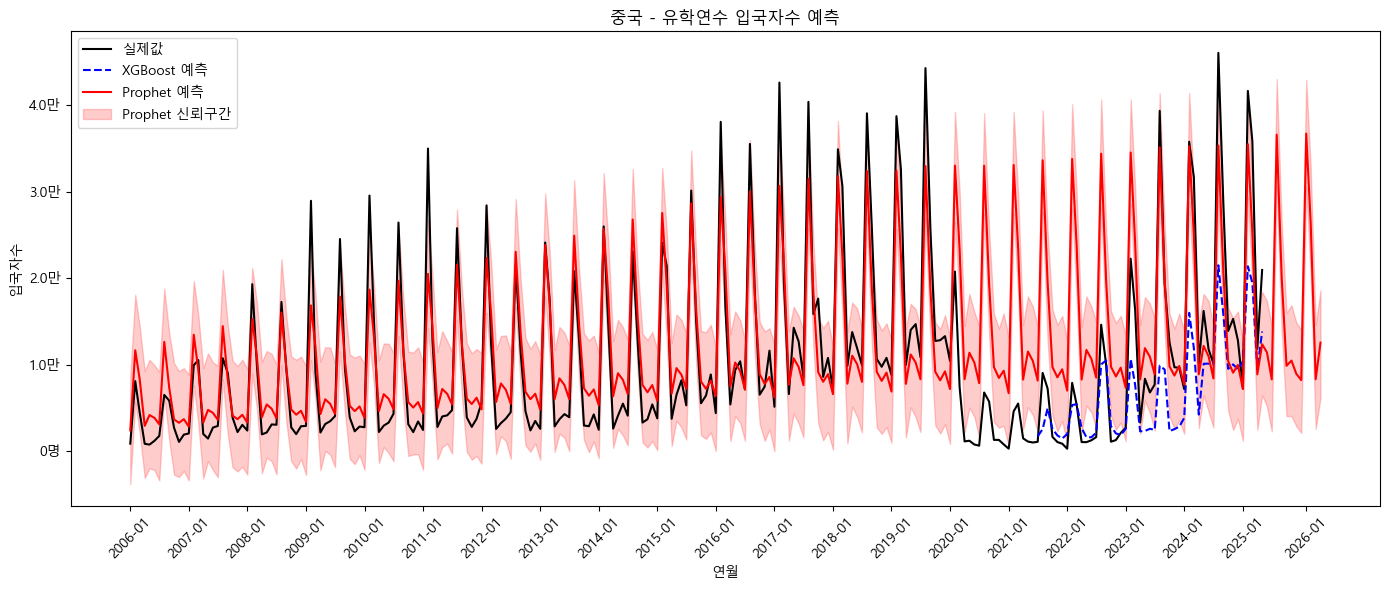


📅 예측 기간 조회
목적 입력 (없으면 Enter): 관광
연도 (예: 2025): 2026
월 (1~12): 4

📌 중국 / 관광 / 2026-04 예상 입국자수 : 217,758명


In [1]:
# ✅ [1] 라이브러리 임포트
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
from prophet import Prophet
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from IPython.display import display
from datetime import datetime

plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# ✅ [2] 데이터 로드
df = pd.read_csv('../../jin/data/processed/외국인입국자_전처리완료_딥러닝용.csv', encoding='utf-8')

# ✅ [3] 사용자 입력
def get_valid_input(column_name, allow_blank=False):
    unique_vals = df[column_name].unique()
    while True:
        user_input = input(f"{column_name} 입력 (없으면 Enter): ").strip().lower().replace(' ', '')
        if allow_blank and user_input == "":
            return None
        match = None
        for val in unique_vals:
            val_clean = val.strip().lower().replace(' ', '')
            if user_input == val_clean:
                match = val
                break
        if match:
            return match
        else:
            print(f"❌ 일치하는 {column_name} 없음. 다시 입력.")

country = get_valid_input('국적')
purpose_input = get_valid_input('목적', allow_blank=True)

df = df[df['국적'] == country]
purpose_list = [purpose_input] if purpose_input else df['목적'].unique()

# ✅ [4] Label Encoding + 파생변수
le_season = LabelEncoder()
le_corona = LabelEncoder()
df['계절'] = le_season.fit_transform(df['계절'])
df['코로나기간'] = le_corona.fit_transform(df['코로나기간'])
df['연월'] = df['연도'].astype(str) + '-' + df['월'].astype(str).str.zfill(2)
df['성수기'] = df['월'].apply(lambda x: 1 if x in [7, 8, 12] else 0) * 1.5
df['명절'] = df['월'].apply(lambda x: 1 if x in [1, 2, 9, 10] else 0) * 2.0

def to_unit(x, pos):
    if x >= 10000:
        return f'{x/10000:.1f}만'
    else:
        return f'{int(x)}명'

# ✅ Prophet 모델 저장용
prophet_models = {}

# ✅ [5] 목적별 루프
for purpose in purpose_list:
    print(f"\n▶️ {purpose} 처리 시작")
    temp_df = df[df['목적'] == purpose]
    if temp_df.empty:
        print(f"⚠️ 데이터 없음: {purpose}")
        continue

    temp_df = temp_df.copy()
    temp_df['lag_1'] = temp_df['입국자수'].shift(1)
    temp_df['lag_3'] = temp_df['입국자수'].shift(3)
    temp_df['lag_12'] = temp_df['입국자수'].shift(12)
    temp_df['입국자수_cumsum'] = temp_df['입국자수'].cumsum()
    temp_df = temp_df.dropna()

    features = [
        '연도', '월', '분기', '계절', '코로나기간', '성수기', '명절',
        'lag_1', 'lag_3', 'lag_12', '입국자수_cumsum'
    ]
    X = temp_df[features]
    y = temp_df['입국자수']
    ym = temp_df['연월'].reset_index(drop=True)

    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test, ym_train, ym_test = train_test_split(
        X_scaled, y, ym, test_size=0.2, random_state=42, shuffle=False
    )

    params = {'n_estimators': [100], 'learning_rate': [0.05], 'max_depth': [3]}
    grid = GridSearchCV(XGBRegressor(), params, cv=2)
    grid.fit(X_train, y_train)
    xgb_model = grid.best_estimator_

    y_pred = xgb_model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print("\n📊 [XGBoost 평가 지표]")
    print(f"MSE (Mean Squared Error)  : {mse:.2f} → 낮을수록 좋음")
    print(f"RMSE (Root MSE)           : {rmse:.2f} → 낮을수록 좋음")
    print(f"R² (결정계수, 설명력)    : {r2:.4f} → 1에 가까울수록 좋음")

    if r2 >= 0.9:
        status = "✅ 매우 우수"
    elif r2 >= 0.7:
        status = "👍 양호"
    elif r2 >= 0.5:
        status = "⚠️ 보통"
    else:
        status = "❗ 낮음 (개선 필요)"
    print(f"📈 R² 해석 : {status}")

    results = pd.DataFrame({
        '연월': ym_test.values,
        '실제값': y_test.values,
        '예측값': y_pred
    })
    display(results.head(10))

    results['date'] = pd.to_datetime(results['연월'])
    temp_df['date'] = pd.to_datetime(temp_df['연월'])

    # ✅ Prophet 예측
    prophet_df = temp_df[['연월', '입국자수', '월', '코로나기간', '성수기', '명절']].copy()
    prophet_df.rename(columns={'연월': 'ds', '입국자수': 'y'}, inplace=True)
    prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])

    m = Prophet(yearly_seasonality=True, seasonality_mode='multiplicative')
    m.add_regressor('코로나기간')
    m.add_regressor('성수기')
    m.add_regressor('명절')
    m.fit(prophet_df)

    future = m.make_future_dataframe(periods=12, freq='M')
    future['월'] = future['ds'].dt.month
    future['코로나기간'] = 0
    future['성수기'] = future['월'].apply(lambda x: 1 if x in [7, 8, 12] else 0) * 1.5
    future['명절'] = future['월'].apply(lambda x: 1 if x in [1, 2, 9, 10] else 0) * 2.0

    forecast = m.predict(future)
    forecast['date'] = forecast['ds']

    prophet_models[purpose] = forecast

    # ✅ 그래프
    all_dates = pd.concat([temp_df['date'], forecast['date']]).drop_duplicates().sort_values()
    year_ticks = all_dates[all_dates.dt.month == 1]

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(temp_df['date'], temp_df['입국자수'], label='실제값', color='black')
    ax.plot(results['date'], results['예측값'], linestyle='--', label='XGBoost 예측', color='blue')
    ax.plot(forecast['date'], forecast['yhat'], linestyle='-', label='Prophet 예측', color='red')
    ax.fill_between(forecast['date'], forecast['yhat_lower'], forecast['yhat_upper'],
                    color='red', alpha=0.2, label='Prophet 신뢰구간')

    ax.set_xticks(year_ticks)
    ax.set_xticklabels([d.strftime('%Y-%m') for d in year_ticks], rotation=45)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(to_unit))

    ax.set_title(f"{country} - {purpose} 입국자수 예측")
    ax.set_xlabel('연월')
    ax.set_ylabel('입국자수')
    ax.legend()
    plt.tight_layout()
    plt.show()

# ✅ [6] 사용자 기간 예측 요청
print("\n📅 예측 기간 조회")
while True:
    query_purpose = get_valid_input('목적', allow_blank=False)
    if query_purpose not in prophet_models:
        print("⚠️ 해당 목적은 처리되지 않았음. 다시 입력.")
        continue
    forecast = prophet_models[query_purpose]

    # 기간 입력 받기
    query_year = int(input("연도 (예: 2025): "))
    query_month = int(input("월 (1~12): "))
    query_date = pd.to_datetime(f"{query_year}-{query_month:02d}-01")

    now = pd.to_datetime(datetime.now())
    max_date = now + pd.DateOffset(months=12)
    if query_date < now or query_date > max_date:
        print(f"⚠️ 입력 기간은 {now.strftime('%Y-%m')} ~ {max_date.strftime('%Y-%m')} 까지만 가능.")
        continue

    row = forecast[forecast['ds'].dt.to_period('M') == query_date.to_period('M')]
    if row.empty:
        print("❗ 해당 기간은 예측 데이터에 없음.")
    else:
        value = row['yhat'].values[0]
        print(f"\n📌 {country} / {query_purpose} / {query_year}-{query_month:02d} 예상 입국자수 : {int(value):,}명")
    break


국적 입력 (없으면 Enter): 
🌍 국적 미입력 → 전체 국가 사용
목적 입력 (없으면 Enter): 

▶️ 공용 처리 시작

📊 [XGBoost 평가 지표]
MSE (평균제곱오차): 629.38 → 낮을수록 좋음
RMSE (평균제곱근오차): 25.09 → 낮을수록 좋음
R² (결정계수): 0.8356 → 1에 가까울수록 좋음
📈 R² 해석 : 👍 양호


,연월,실제값,예측값
0,2021-07,3,4.032517
1,2021-08,16,4.549887
2,2021-09,4,11.597907
3,2021-10,6,4.032517
4,2021-11,12,8.298028
5,2021-12,2,7.865893
6,2022-01,13,4.253949
7,2022-02,6,11.229088
8,2022-03,4,4.870987
9,2022-04,24,6.069591


17:05:21 - cmdstanpy - INFO - Chain [1] start processing
17:05:25 - cmdstanpy - INFO - Chain [1] done processing



▶️ 관광 처리 시작

📊 [XGBoost 평가 지표]
MSE (평균제곱오차): 14686982.73 → 낮을수록 좋음
RMSE (평균제곱근오차): 3832.36 → 낮을수록 좋음
R² (결정계수): 0.9006 → 1에 가까울수록 좋음
📈 R² 해석 : ✅ 매우 우수


,연월,실제값,예측값
0,2021-07,196,527.807373
1,2021-08,267,527.807373
2,2021-09,353,527.807373
3,2021-10,495,555.163025
4,2021-11,476,656.802612
5,2021-12,401,619.188293
6,2022-01,171,608.236572
7,2022-02,205,550.636353
8,2022-03,293,550.636353
9,2022-04,3012,550.636353


...

,연월,실제값,예측값
0,2021-07,18,21.998186
1,2021-08,25,23.045324
2,2021-09,36,26.661331
3,2021-10,43,36.856846
4,2021-11,49,39.762703
5,2021-12,19,44.666824
6,2022-01,15,31.053978
7,2022-02,16,35.493534
8,2022-03,26,21.998186
9,2022-04,22,28.247208


17:05:34 - cmdstanpy - INFO - Chain [1] start processing
17:05:36 - cmdstanpy - INFO - Chain [1] done processing



▶️ 유학연수 처리 시작

📊 [XGBoost 평가 지표]
MSE (평균제곱오차): 2462.94 → 낮을수록 좋음
RMSE (평균제곱근오차): 49.63 → 낮을수록 좋음
R² (결정계수): 0.8594 → 1에 가까울수록 좋음
📈 R² 해석 : 👍 양호


,연월,실제값,예측값
0,2021-07,8,18.528893
1,2021-08,54,16.902107
2,2021-09,15,20.617979
3,2021-10,4,19.544510
4,2021-11,15,18.528893
5,2021-12,8,19.544510
6,2022-01,25,28.136232
7,2022-02,120,50.428337
8,2022-03,15,47.570179
9,2022-04,6,26.493752


17:05:37 - cmdstanpy - INFO - Chain [1] start processing
17:05:40 - cmdstanpy - INFO - Chain [1] done processing


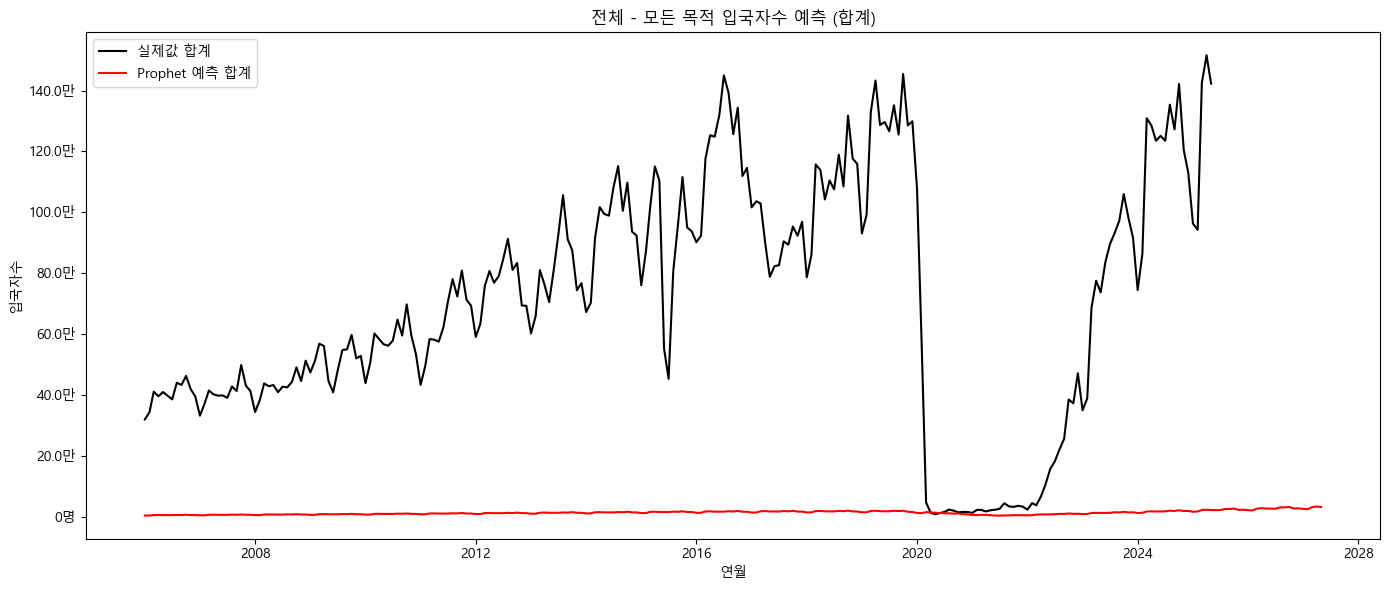


📅 원하는 예측 기간 조회

선택 가능 기간 표 (월 단위):
+---------+---------+---------+---------+---------+---------+
| 2025-07 | 2025-08 | 2025-09 | 2025-10 | 2025-11 | 2025-12 |
+---------+---------+---------+---------+---------+---------+
| 2026-01 | 2026-02 | 2026-03 | 2026-04 | 2026-05 | 2026-06 |
+---------+---------+---------+---------+---------+---------+
| 2026-07 | 2026-08 | 2026-09 | 2026-10 | 2026-11 | 2026-12 |
+---------+---------+---------+---------+---------+---------+
| 2027-01 | 2027-02 | 2027-03 | 2027-04 | 2027-05 | 2027-06 |
+---------+---------+---------+---------+---------+---------+
| 2027-07 |         |         |         |         |         |
+---------+---------+---------+---------+---------+---------+
예측 연월 입력 (예: 202507 또는 2025-07): 202601

📌 전체 / 모든 목적 / 2026-01 예상 입국자수 합계 : 21,402명


In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
from prophet import Prophet
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from IPython.display import display
from datetime import datetime
from tabulate import tabulate

plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# ✅ 데이터 로드
df = pd.read_csv('../../jin/data/processed/외국인입국자_전처리완료_딥러닝용.csv', encoding='utf-8')

# ✅ 입력 함수
def get_valid_input(column_name, allow_blank=False):
    unique_vals = df[column_name].unique()
    while True:
        user_input = input(f"{column_name} 입력 (없으면 Enter): ").strip().lower().replace(' ', '')
        if allow_blank and user_input == "":
            return None
        match = None
        for val in unique_vals:
            val_clean = val.strip().lower().replace(' ', '')
            if user_input == val_clean:
                match = val
                break
        if match:
            return match
        else:
            print(f"❌ 일치하는 {column_name} 없음. 다시 입력.")

# ✅ 국적 선택
country = get_valid_input('국적', allow_blank=True)
if country:
    df = df[df['국적'] == country]
    print(f"🌏 선택된 국적: {country}")
else:
    print("🌍 국적 미입력 → 전체 국가 사용")

# ✅ 목적 선택
purpose_input = get_valid_input('목적', allow_blank=True)
purpose_list = [purpose_input] if purpose_input else df['목적'].unique()

# ✅ 파생 변수 처리
le_season = LabelEncoder()
le_corona = LabelEncoder()
df['계절'] = le_season.fit_transform(df['계절'])
df['코로나기간'] = le_corona.fit_transform(df['코로나기간'])
df['연월'] = df['연도'].astype(str) + '-' + df['월'].astype(str).str.zfill(2)
df['성수기'] = df['월'].apply(lambda x: 1 if x in [7, 8, 12] else 0) * 1.5
df['명절'] = df['월'].apply(lambda x: 1 if x in [1, 2, 9, 10] else 0) * 2.0

def to_unit(x, pos):
    if x >= 10000:
        return f'{x/10000:.1f}만'
    else:
        return f'{int(x)}명'

# ✅ Prophet 결과 담기
prophet_forecasts = []
all_actuals = []

# ✅ 목적별 루프
for purpose in purpose_list:
    print(f"\n▶️ {purpose} 처리 시작")
    temp_df = df[df['목적'] == purpose]
    if temp_df.empty:
        print(f"⚠️ 데이터 없음: {purpose}")
        continue

    temp_df = temp_df.copy()
    temp_df['lag_1'] = temp_df['입국자수'].shift(1)
    temp_df['lag_3'] = temp_df['입국자수'].shift(3)
    temp_df['lag_12'] = temp_df['입국자수'].shift(12)
    temp_df['입국자수_cumsum'] = temp_df['입국자수'].cumsum()
    temp_df = temp_df.dropna()

    features = [
        '연도', '월', '분기', '계절', '코로나기간', '성수기', '명절',
        'lag_1', 'lag_3', 'lag_12', '입국자수_cumsum'
    ]
    X = temp_df[features]
    y = temp_df['입국자수']
    ym = temp_df['연월'].reset_index(drop=True)

    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test, ym_train, ym_test = train_test_split(
        X_scaled, y, ym, test_size=0.2, random_state=42, shuffle=False
    )

    params = {'n_estimators': [100], 'learning_rate': [0.05], 'max_depth': [3]}
    grid = GridSearchCV(XGBRegressor(), params, cv=2)
    grid.fit(X_train, y_train)
    xgb_model = grid.best_estimator_

    y_pred = xgb_model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print("\n📊 [XGBoost 평가 지표]")
    print(f"MSE (평균제곱오차): {mse:.2f} → 낮을수록 좋음")
    print(f"RMSE (평균제곱근오차): {rmse:.2f} → 낮을수록 좋음")
    print(f"R² (결정계수): {r2:.4f} → 1에 가까울수록 좋음")

    if r2 >= 0.9:
        status = "✅ 매우 우수"
    elif r2 >= 0.7:
        status = "👍 양호"
    elif r2 >= 0.5:
        status = "⚠️ 보통"
    else:
        status = "❗ 낮음 (개선 필요)"
    print(f"📈 R² 해석 : {status}")

    results = pd.DataFrame({
        '연월': ym_test.values,
        '실제값': y_test.values,
        '예측값': y_pred
    })
    display(results.head(10))

    # ✅ Prophet 학습
    prophet_df = temp_df[['연월', '입국자수', '월', '코로나기간', '성수기', '명절']].copy()
    prophet_df.rename(columns={'연월': 'ds', '입국자수': 'y'}, inplace=True)
    prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])

    m = Prophet(yearly_seasonality=True, seasonality_mode='multiplicative')
    m.add_regressor('코로나기간')
    m.add_regressor('성수기')
    m.add_regressor('명절')
    m.fit(prophet_df)

    future = m.make_future_dataframe(periods=24, freq='M')
    future['월'] = future['ds'].dt.month
    future['코로나기간'] = 0
    future['성수기'] = future['월'].apply(lambda x: 1 if x in [7, 8, 12] else 0) * 1.5
    future['명절'] = future['월'].apply(lambda x: 1 if x in [1, 2, 9, 10] else 0) * 2.0

    forecast = m.predict(future)
    forecast = forecast[['ds', 'yhat']]
    prophet_forecasts.append(forecast)

    # ✅ 실제값 누적
    temp_df['date'] = pd.to_datetime(temp_df['연월'])
    all_actuals.append(temp_df[['date', '입국자수']])

# ✅ 전체 Prophet 결과 합산
total_prophet = pd.concat(prophet_forecasts).groupby('ds').sum().reset_index()

# ✅ 전체 실제값 합산
total_actuals = pd.concat(all_actuals).groupby('date').sum().reset_index()

# ✅ 그래프: 전체 합계
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(total_actuals['date'], total_actuals['입국자수'], label='실제값 합계', color='black')
ax.plot(total_prophet['ds'], total_prophet['yhat'], label='Prophet 예측 합계', color='red')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(to_unit))
ax.set_title(f"{country if country else '전체'} - 모든 목적 입국자수 예측 (합계)")
ax.set_xlabel('연월')
ax.set_ylabel('입국자수')
ax.legend()
plt.tight_layout()
plt.show()

# ✅ 원하는 기간 조회
print("\n📅 원하는 예측 기간 조회")
now = pd.to_datetime(datetime.now()).replace(day=1)
max_date = now + pd.DateOffset(months=24)
possible_dates = pd.date_range(now, max_date, freq='MS').strftime('%Y-%m').tolist()

rows = [possible_dates[i:i+6] for i in range(0, len(possible_dates), 6)]
print("\n선택 가능 기간 표 (월 단위):")
print(tabulate(rows, tablefmt="grid"))

while True:
    query_input = input("예측 연월 입력 (예: 202507 또는 2025-07): ").strip().replace('-', '')
    if len(query_input) == 6:
        query_input = f"{query_input[:4]}-{query_input[4:]}"
    try:
        query_date = pd.to_datetime(query_input + "-01")
    except:
        print("❌ 형식 오류")
        continue

    if query_input not in possible_dates:
        print("⚠️ 가능한 기간이 아님. 표 참고.")
        continue

    row = total_prophet[total_prophet['ds'].dt.to_period('M') == query_date.to_period('M')]
    if row.empty:
        print("❗ 해당 기간 데이터 없음.")
    else:
        value = row['yhat'].values[0]
        print(f"\n📌 {country if country else '전체'} / 모든 목적 / {query_input} 예상 입국자수 합계 : {int(value):,}명")
    break


국적 입력 (없으면 Enter): 
목적 입력 (없으면 Enter): 
🌍 국적 미선택 → 모든 나라 사용


17:20:43 - cmdstanpy - INFO - Chain [1] start processing
17:20:44 - cmdstanpy - INFO - Chain [1] done processing


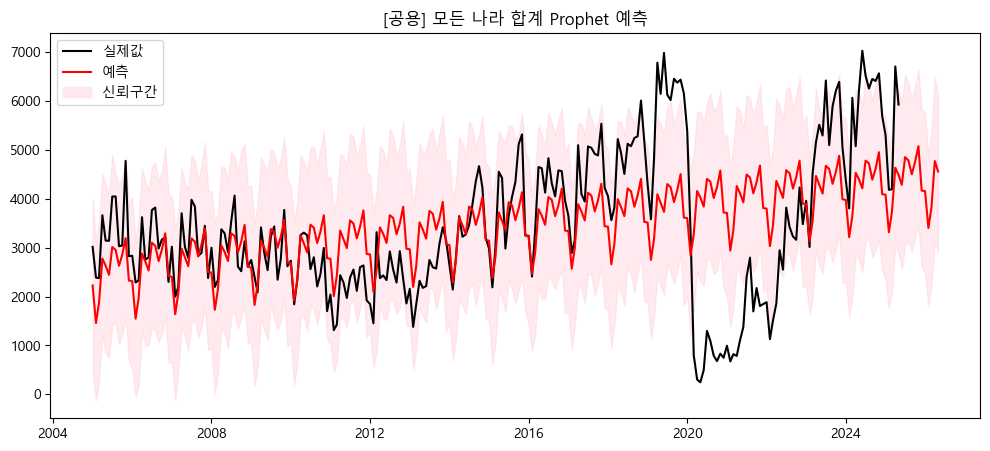

17:20:44 - cmdstanpy - INFO - Chain [1] start processing



✅ 공용 Prophet 결과 샘플
            ds         yhat   yhat_lower   yhat_upper
254 2026-02-28  3823.621719  2241.346803  5400.220750
255 2026-03-31  4772.279322  3125.926643  6474.358208
256 2026-04-30  4557.165657  2894.652250  6121.923794


17:20:44 - cmdstanpy - INFO - Chain [1] done processing


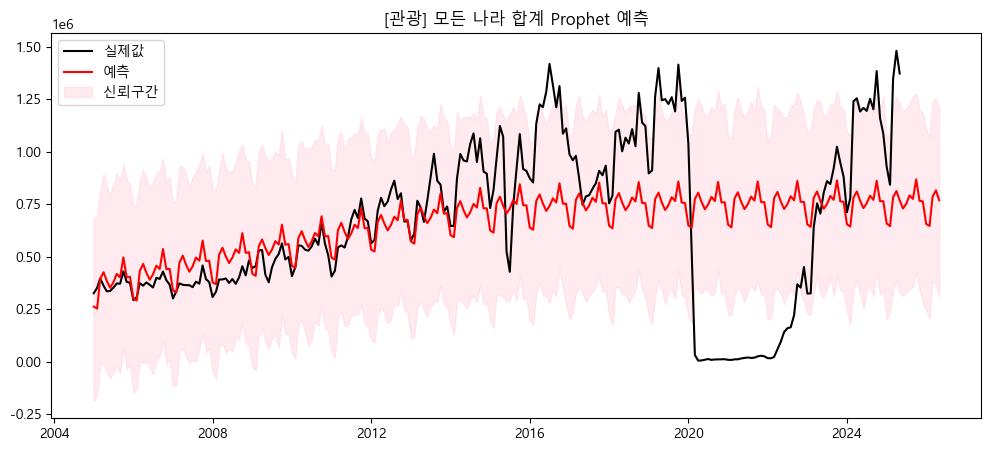

17:20:45 - cmdstanpy - INFO - Chain [1] start processing



✅ 관광 Prophet 결과 샘플
            ds           yhat     yhat_lower    yhat_upper
254 2026-02-28  785054.390933  381461.268750  1.240190e+06
255 2026-03-31  815843.657291  365533.638146  1.254916e+06
256 2026-04-30  768304.241551  310645.541554  1.204636e+06


17:20:45 - cmdstanpy - INFO - Chain [1] done processing


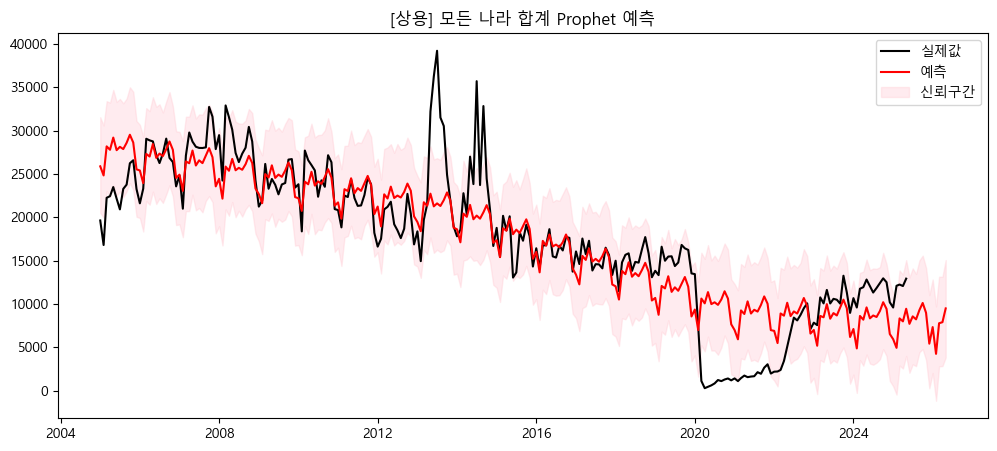

17:20:45 - cmdstanpy - INFO - Chain [1] start processing



✅ 상용 Prophet 결과 샘플
            ds         yhat   yhat_lower    yhat_upper
254 2026-02-28  7776.246062  2800.925221  13145.567026
255 2026-03-31  7898.457492  2832.857049  13139.467104
256 2026-04-30  9489.910818  3834.004449  15066.149031


17:20:45 - cmdstanpy - INFO - Chain [1] done processing


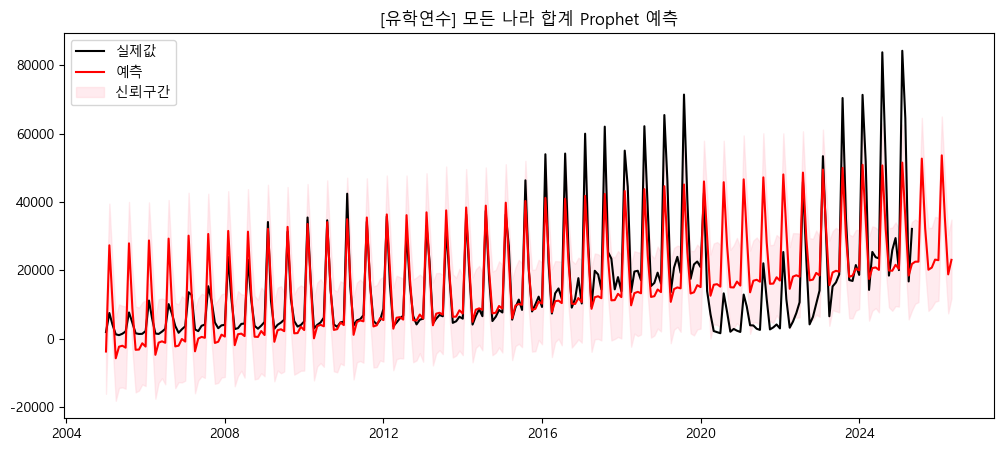


✅ 유학연수 Prophet 결과 샘플
            ds          yhat    yhat_lower    yhat_upper
254 2026-02-28  35553.115733  22785.640745  47610.503839
255 2026-03-31  18784.597050   7367.644655  30294.870795
256 2026-04-30  23033.501172  11780.049243  34827.863795


C:\Users\Admin\AppData\Local\Temp\ipykernel_9516\1353229142.py:75: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  total_actuals = pd.concat(actual_results.values()).groupby('ds').sum().reset_index()


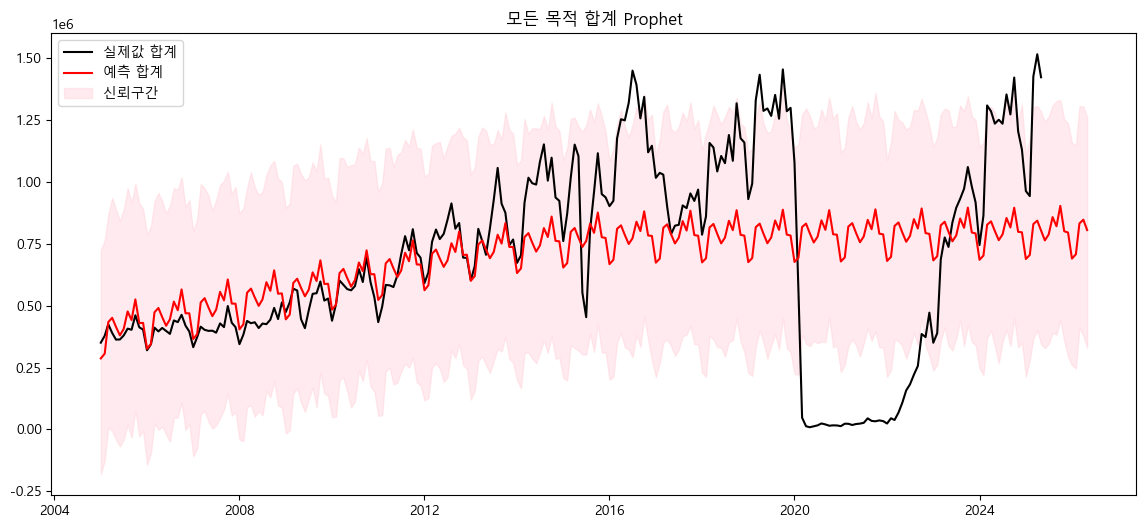


📅 원하는 예측 연월
+---------+---------+---------+---------+---------+---------+
| 2025-07 | 2025-08 | 2025-09 | 2025-10 | 2025-11 | 2025-12 |
+---------+---------+---------+---------+---------+---------+
| 2026-01 | 2026-02 | 2026-03 | 2026-04 | 2026-05 | 2026-06 |
+---------+---------+---------+---------+---------+---------+
| 2026-07 | 2026-08 | 2026-09 | 2026-10 | 2026-11 | 2026-12 |
+---------+---------+---------+---------+---------+---------+
| 2027-01 | 2027-02 | 2027-03 | 2027-04 | 2027-05 | 2027-06 |
+---------+---------+---------+---------+---------+---------+
| 2027-07 |         |         |         |         |         |
+---------+---------+---------+---------+---------+---------+
연월 입력 (202507 또는 2025-07): 202605
⚠️ 공용 에서 2026-05 데이터 없음 → 점 표시 안 함


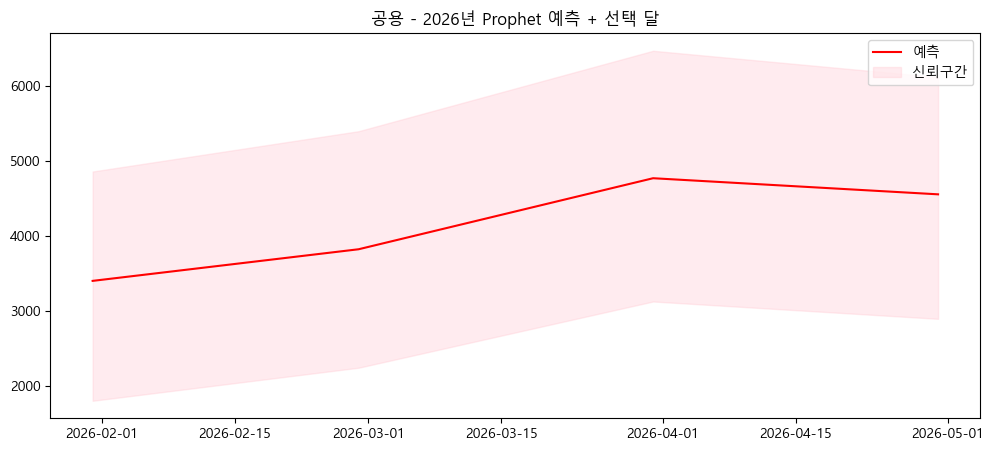

⚠️ 관광 에서 2026-05 데이터 없음 → 점 표시 안 함


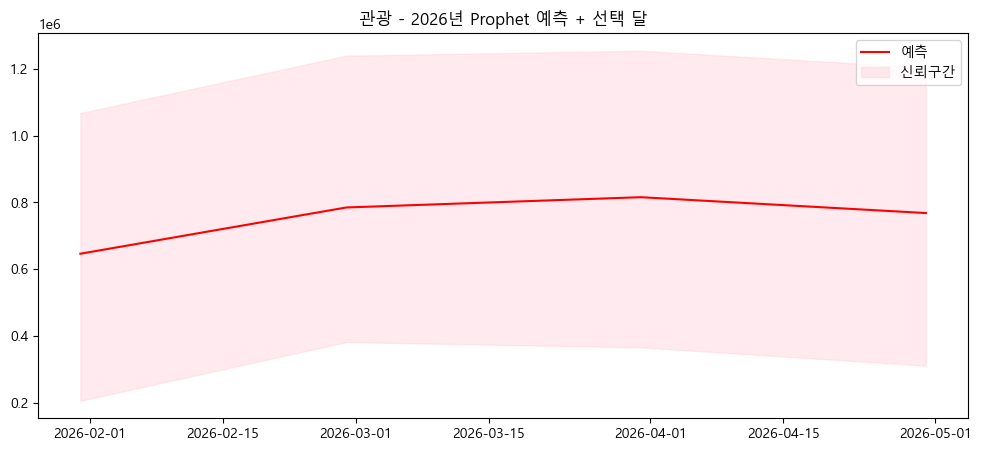

⚠️ 상용 에서 2026-05 데이터 없음 → 점 표시 안 함


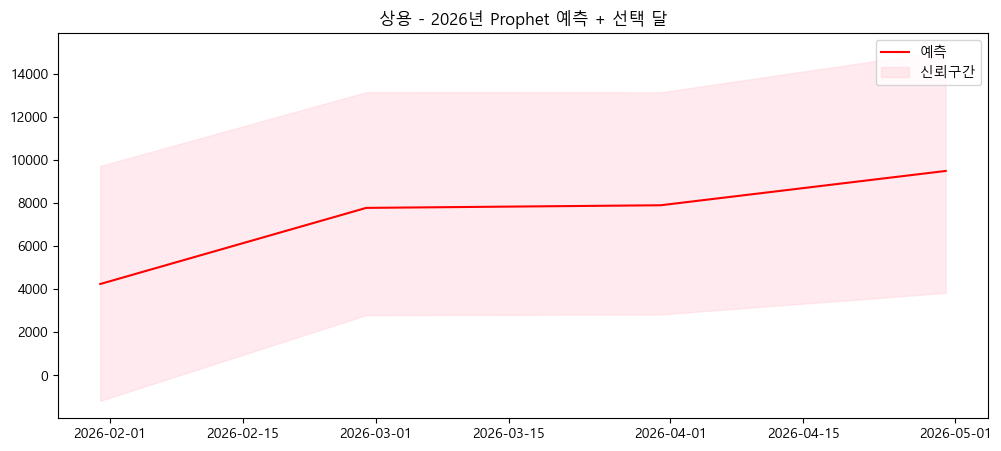

⚠️ 유학연수 에서 2026-05 데이터 없음 → 점 표시 안 함


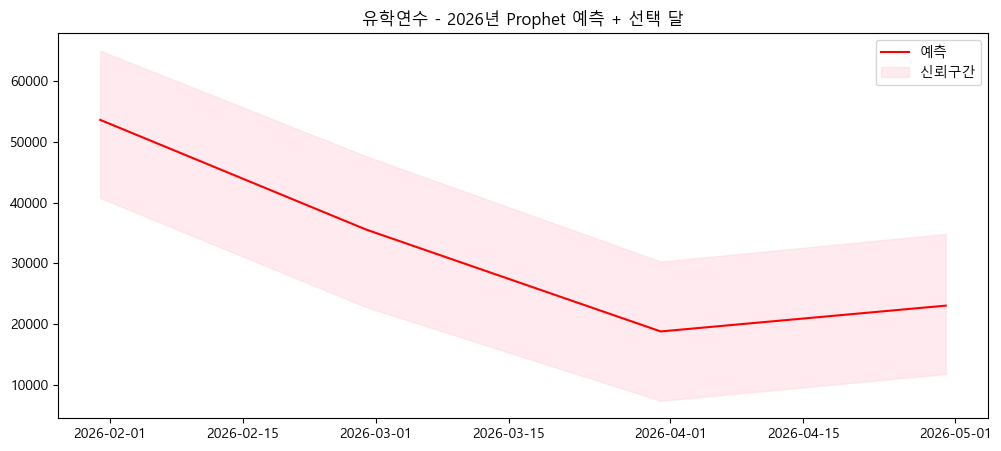

In [10]:
import pandas as pd
import numpy as np
from prophet import Prophet
import matplotlib.pyplot as plt
from datetime import datetime
from tabulate import tabulate

plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# ✅ 데이터 로드
df = pd.read_csv('../../jin/data/processed/외국인입국자_전처리완료_딥러닝용.csv')

# ✅ 입력
country = input("국적 입력 (없으면 Enter): ").strip()
purpose = input("목적 입력 (없으면 Enter): ").strip()

# ✅ 국적 필터
if country:
    df = df[df['국적'] == country]
else:
    print("🌍 국적 미선택 → 모든 나라 사용")

# ✅ 목적 리스트
purpose_list = [purpose] if purpose else df['목적'].unique()

# ✅ 파생
df['연월'] = df['연도'].astype(str) + '-' + df['월'].astype(str).str.zfill(2)

# ✅ 국적 미선택이면 같은 목적별로 모든 나라 데이터 합산
if not country:
    grouped = df.groupby(['연월', '목적'], as_index=False)['입국자수'].sum()
else:
    grouped = df.copy()

prophet_results = {}
actual_results = {}

# ✅ 목적별 루프
for pur in purpose_list:
    temp = grouped[grouped['목적'] == pur].copy()
    if temp.empty:
        print(f"❌ 데이터 없음: {pur}")
        continue

    temp['ds'] = pd.to_datetime(temp['연월'])
    temp['y'] = temp['입국자수']

    # Prophet
    m = Prophet(yearly_seasonality=True)
    m.fit(temp[['ds', 'y']])

    future = m.make_future_dataframe(periods=12, freq='M')
    forecast = m.predict(future)

    prophet_results[pur] = forecast
    actual_results[pur] = temp

    # ✅ 목적별 그래프
    plt.figure(figsize=(12,5))
    plt.plot(temp['ds'], temp['y'], label='실제값', color='black')
    plt.plot(forecast['ds'], forecast['yhat'], label='예측', color='red')
    plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'],
                     color='pink', alpha=0.3, label='신뢰구간')
    plt.title(f"[{pur}] 모든 나라 합계 Prophet 예측")
    plt.legend()
    plt.show()

    print(f"\n✅ {pur} Prophet 결과 샘플")
    print(forecast.tail(3)[['ds', 'yhat', 'yhat_lower', 'yhat_upper']])

# ✅ 목적 미선택이면 전체 목적 합산도
if not purpose:
    total_prophet = pd.concat(prophet_results.values()).groupby('ds').sum().reset_index()
    total_actuals = pd.concat(actual_results.values()).groupby('ds').sum().reset_index()

    plt.figure(figsize=(14,6))
    plt.plot(total_actuals['ds'], total_actuals['y'], label='실제값 합계', color='black')
    plt.plot(total_prophet['ds'], total_prophet['yhat'], label='예측 합계', color='red')
    plt.fill_between(total_prophet['ds'], total_prophet['yhat_lower'], total_prophet['yhat_upper'],
                     alpha=0.3, color='pink', label='신뢰구간')
    plt.title("모든 목적 합계 Prophet")
    plt.legend()
    plt.show()

# ✅ 연월 입력
print("\n📅 원하는 예측 연월")
now = pd.to_datetime(datetime.now()).replace(day=1)
possible_dates = pd.date_range(now, now + pd.DateOffset(months=24), freq='MS').strftime('%Y-%m').tolist()
rows = [possible_dates[i:i+6] for i in range(0, len(possible_dates), 6)]
print(tabulate(rows, tablefmt="grid"))

query = input("연월 입력 (202507 또는 2025-07): ").strip().replace('-', '')
if len(query) == 6:
    query = f"{query[:4]}-{query[4:]}"

query_date = pd.to_datetime(query + "-01")
query_year = query_date.year

# ✅ 목적별로 해당 연도 그래프 + 요청한 달 강조
if purpose:
    targets = [purpose]
else:
    targets = list(prophet_results.keys())

for pur in targets:
    fc = prophet_results[pur]
    one_year = fc[fc['ds'].dt.year == query_year]

    plt.figure(figsize=(12,5))
    plt.plot(one_year['ds'], one_year['yhat'], label='예측', color='red')
    plt.fill_between(one_year['ds'], one_year['yhat_lower'], one_year['yhat_upper'],
                     alpha=0.3, color='pink', label='신뢰구간')

    point = one_year.loc[one_year['ds'] == query_date, 'yhat']
    if not point.empty:
        plt.scatter(query_date, point.values[0],
                    color='blue', label=f'{query} 예측값')
    else:
        print(f"⚠️ {pur} 에서 {query} 데이터 없음 → 점 표시 안 함")

    plt.title(f"{pur} - {query_year}년 Prophet 예측 + 선택 달")
    plt.legend()
    plt.show()

    if not point.empty:
        print(f"📌 {pur} / {query} 예상 입국자수: {int(point.values[0]):,}명")


In [12]:
import pandas as pd
import numpy as np
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from datetime import datetime
from tabulate import tabulate

plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# 데이터 로드
df = pd.read_csv('../../jin/data/processed/외국인입국자_전처리완료_딥러닝용.csv')

country = input("국적 입력 (없으면 Enter): ").strip()
purpose = input("목적 입력 (없으면 Enter): ").strip()

if country:
    df = df[df['국적'] == country]
else:
    print("🌍 국적 미선택 → 모든 나라 사용")

purpose_list = [purpose] if purpose else df['목적'].unique()

df['연월'] = df['연도'].astype(str) + '-' + df['월'].astype(str).str.zfill(2)

# 국적 미선택이면 같은 목적끼리 합계
if not country:
    grouped = df.groupby(['연월', '목적'], as_index=False)['입국자수'].sum()
else:
    grouped = df.copy()

prophet_results = {}
xgb_results = {}
actuals = {}

for pur in purpose_list:
    temp = grouped[grouped['목적'] == pur].copy()
    if temp.empty:
        print(f"❌ 데이터 없음: {pur}")
        continue

    temp['ds'] = pd.to_datetime(temp['연월'])
    temp['y'] = temp['입국자수']

    # ✅ Prophet
    m = Prophet(yearly_seasonality=True)
    m.fit(temp[['ds', 'y']])
    future = m.make_future_dataframe(periods=12, freq='M')
    forecast = m.predict(future)
    prophet_results[pur] = forecast

    # ✅ XGBoost
    temp['연도'] = temp['ds'].dt.year
    temp['월'] = temp['ds'].dt.month
    temp['lag_1'] = temp['y'].shift(1)
    temp = temp.dropna()

    X = temp[['연도', '월', 'lag_1']]
    y = temp['y']
    X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    xgb = XGBRegressor()
    xgb.fit(X_train_scaled, y_train)
    y_pred = xgb.predict(X_test_scaled)

    # test 연월과 예측값 연결
    xgb_df = pd.DataFrame({'ds': temp.iloc[y_test.index]['ds'], 'xgb_yhat': y_pred})
    xgb_results[pur] = xgb_df
    actuals[pur] = temp

    # ✅ 목적별 Prophet + XGBoost 그래프 출력
    plt.figure(figsize=(12,5))
    plt.plot(temp['ds'], temp['y'], label='실제값', color='black')
    plt.plot(forecast['ds'], forecast['yhat'], label='Prophet', color='red')
    plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'],
                     alpha=0.2, color='pink', label='Prophet 신뢰구간')
    plt.plot(xgb_df['ds'], xgb_df['xgb_yhat'], label='XGBoost', color='blue')
    plt.title(f"[{pur}] 모든 나라 Prophet + XGBoost")
    plt.legend()
    plt.show()

# ✅ 목적 미선택이면 Prophet 전체 합계 계산
if not purpose:
    total_prophet = pd.concat(prophet_results.values()).groupby('ds').sum().reset_index()
    total_actuals = pd.concat(actuals.values()).groupby('ds').sum().reset_index()

    plt.figure(figsize=(14,6))
    plt.plot(total_actuals['ds'], total_actuals['y'], label='실제값 합계', color='black')
    plt.plot(total_prophet['ds'], total_prophet['yhat'], label='Prophet 합계', color='red')
    plt.fill_between(total_prophet['ds'], total_prophet['yhat_lower'], total_prophet['yhat_upper'],
                     alpha=0.3, color='pink', label='Prophet 신뢰구간')
    plt.title("모든 목적 합계 Prophet")
    plt.legend()
    plt.show()

# ✅ 원하는 연월
print("\n📅 원하는 연월 선택")
now = pd.to_datetime(datetime.now()).replace(day=1)
possible = pd.date_range(now, now + pd.DateOffset(months=24), freq='MS').strftime('%Y-%m').tolist()
rows = [possible[i:i+6] for i in range(0, len(possible), 6)]
print(tabulate(rows, tablefmt="grid"))

query = input("연월 입력 (202507 또는 2025-07): ").strip().replace('-', '')
if len(query) == 6:
    query = f"{query[:4]}-{query[4:]}"
query_date = pd.to_datetime(query + "-01")
query_year = query_date.year

# ✅ 목적 선택시 → 선택 목적 + 전체 합계 Prophet
if purpose:
    # 개별 목적 Prophet + XGBoost
    fc = prophet_results[purpose]
    one_year = fc[fc['ds'].dt.year == query_year]

    plt.figure(figsize=(12,5))
    plt.plot(one_year['ds'], one_year['yhat'], label='Prophet', color='red')
    plt.fill_between(one_year['ds'], one_year['yhat_lower'], one_year['yhat_upper'],
                     alpha=0.3, color='pink')
    xgb = xgb_results[purpose]
    xgb_year = xgb[xgb['ds'].dt.year == query_year]
    plt.plot(xgb_year['ds'], xgb_year['xgb_yhat'], label='XGBoost', color='blue')

    point = one_year.loc[one_year['ds'] == query_date, 'yhat']
    if not point.empty:
        plt.scatter(query_date, point.values[0], color='black', label='선택달')
    plt.title(f"{purpose} Prophet+XGB ({query_year})")
    plt.legend()
    plt.show()

    print(f"{purpose} / {query}: {int(point.values[0]) if not point.empty else 'N/A'}명")

    # 전체 Prophet 합계
    total_prophet = pd.concat(prophet_results.values()).groupby('ds').sum().reset_index()
    one_year_sum = total_prophet[total_prophet['ds'].dt.year == query_year]
    plt.figure(figsize=(12,5))
    plt.plot(one_year_sum['ds'], one_year_sum['yhat'], label='전체 Prophet', color='red')
    plt.fill_between(one_year_sum['ds'], one_year_sum['yhat_lower'], one_year_sum['yhat_upper'],
                     alpha=0.2, color='pink')
    p2 = one_year_sum.loc[one_year_sum['ds'] == query_date, 'yhat']
    if not p2.empty:
        plt.scatter(query_date, p2.values[0], color='black', label='선택달')
    plt.title(f"모든 목적 Prophet 합계 ({query_year})")
    plt.legend()
    plt.show()
    print(f"모든 목적 합계 / {query}: {int(p2.values[0]) if not p2.empty else 'N/A'}명")

# ✅ 목적 미선택이면 → 전체 Prophet 합계만
if not purpose:
    one_year_sum = total_prophet[total_prophet['ds'].dt.year == query_year]
    plt.figure(figsize=(12,5))
    plt.plot(one_year_sum['ds'], one_year_sum['yhat'], label='전체 Prophet', color='red')
    plt.fill_between(one_year_sum['ds'], one_year_sum['yhat_lower'], one_year_sum['yhat_upper'],
                     alpha=0.2, color='pink')
    p2 = one_year_sum.loc[one_year_sum['ds'] == query_date, 'yhat']
    if not p2.empty:
        plt.scatter(query_date, p2.values[0], color='black', label='선택달')
    plt.title(f"모든 목적 Prophet 합계 ({query_year})")
    plt.legend()
    plt.show()
    print(f"모든 목적 합계 / {query}: {int(p2.values[0]) if not p2.empty else 'N/A'}명")


국적 입력 (없으면 Enter): 
목적 입력 (없으면 Enter): 
🌍 국적 미선택 → 모든 나라 사용


17:31:30 - cmdstanpy - INFO - Chain [1] start processing
17:31:30 - cmdstanpy - INFO - Chain [1] done processing


IndexError: positional indexers are out-of-bounds

국적 입력 (없으면 Enter): 
목적 입력 (없으면 Enter): 
🌍 국적 미선택 → 모든 나라 사용


17:46:35 - cmdstanpy - INFO - Chain [1] start processing
17:46:35 - cmdstanpy - INFO - Chain [1] done processing


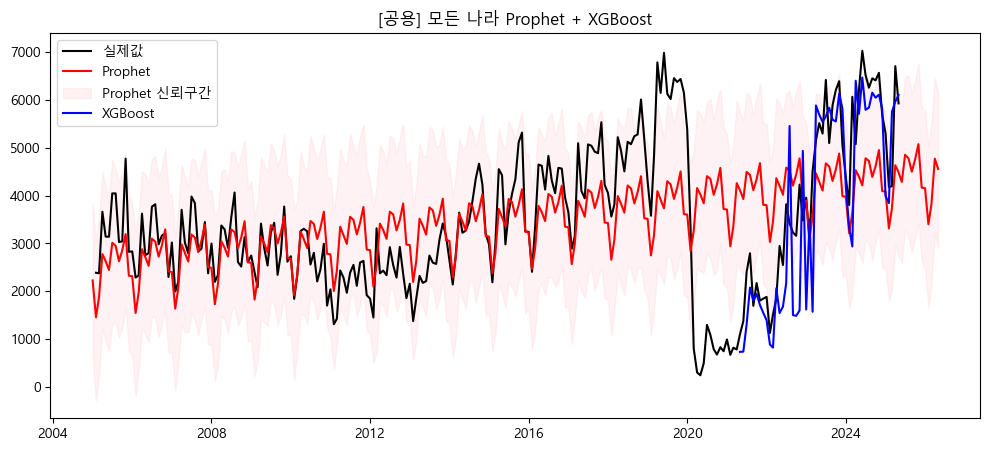

17:46:36 - cmdstanpy - INFO - Chain [1] start processing
17:46:36 - cmdstanpy - INFO - Chain [1] done processing


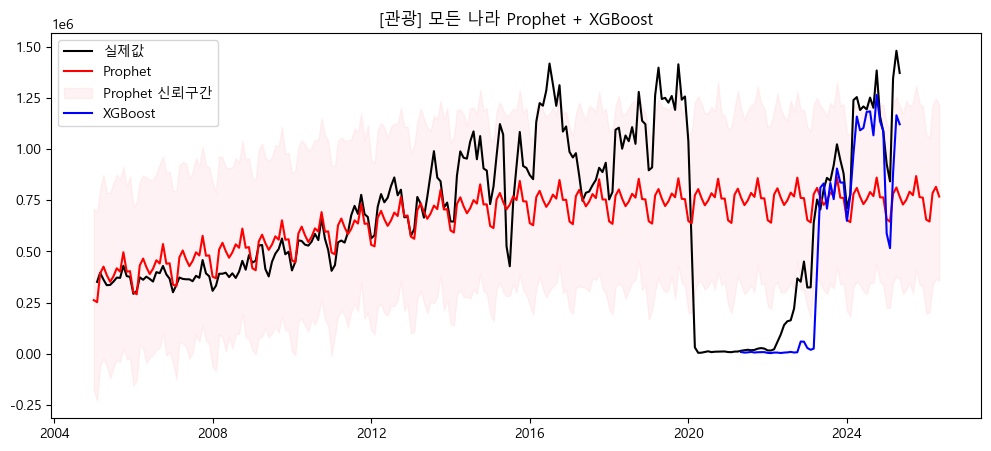

17:46:36 - cmdstanpy - INFO - Chain [1] start processing
17:46:36 - cmdstanpy - INFO - Chain [1] done processing


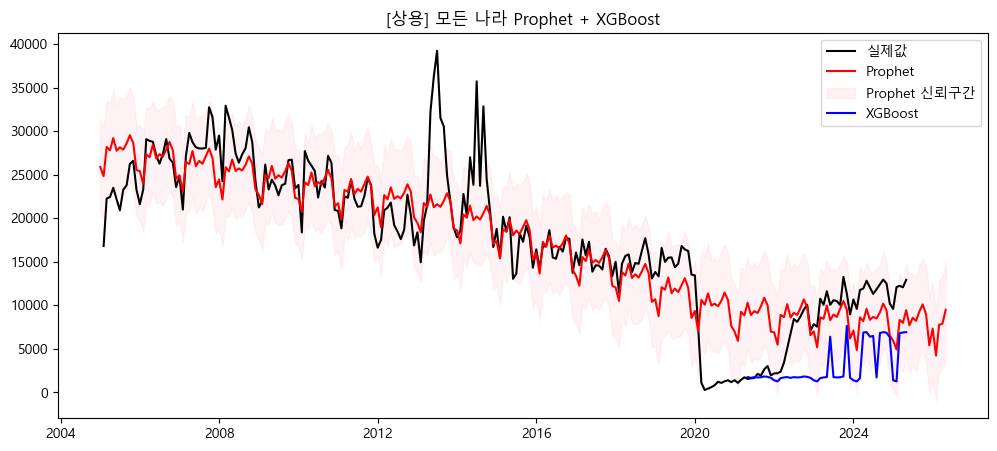

17:46:37 - cmdstanpy - INFO - Chain [1] start processing
17:46:37 - cmdstanpy - INFO - Chain [1] done processing


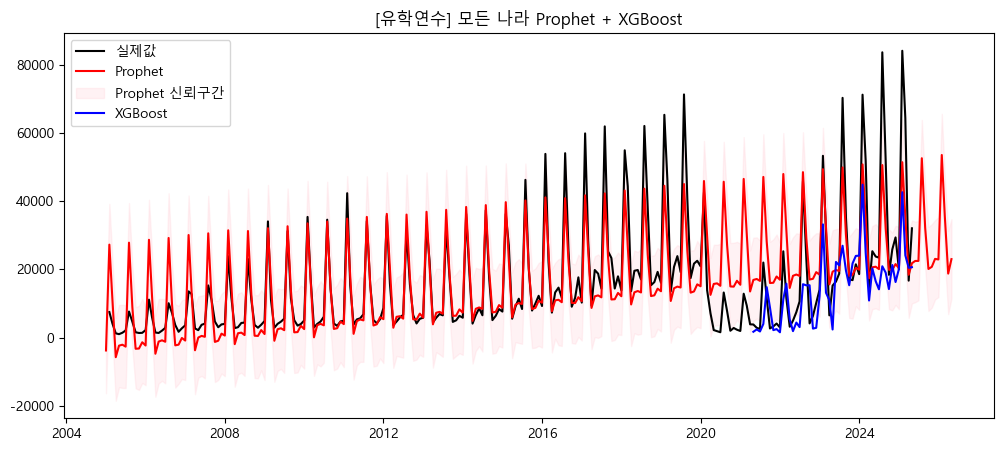

C:\Users\Admin\AppData\Local\Temp\ipykernel_9516\2375994513.py:92: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  total_actuals = pd.concat(actuals.values()).groupby('ds').sum().reset_index()


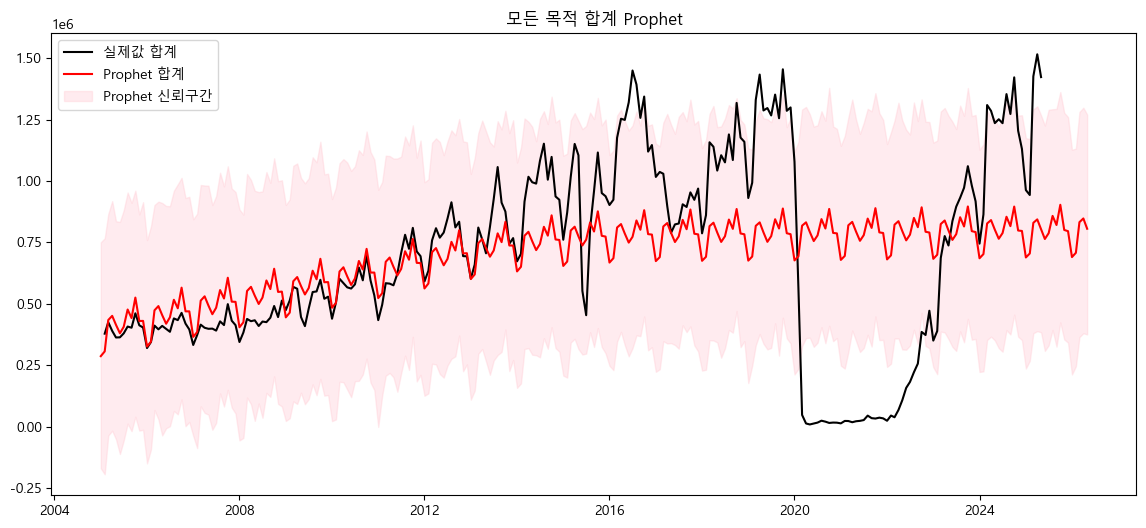


📅 원하는 연월 선택
+---------+---------+---------+---------+---------+---------+
| 2025-07 | 2025-08 | 2025-09 | 2025-10 | 2025-11 | 2025-12 |
+---------+---------+---------+---------+---------+---------+
| 2026-01 | 2026-02 | 2026-03 | 2026-04 | 2026-05 | 2026-06 |
+---------+---------+---------+---------+---------+---------+
| 2026-07 | 2026-08 | 2026-09 | 2026-10 | 2026-11 | 2026-12 |
+---------+---------+---------+---------+---------+---------+
| 2027-01 | 2027-02 | 2027-03 | 2027-04 | 2027-05 | 2027-06 |
+---------+---------+---------+---------+---------+---------+
| 2027-07 |         |         |         |         |         |
+---------+---------+---------+---------+---------+---------+
연월 입력 (202507 또는 2025-07): 202604
❗ 전체 목적 2026-04 데이터 없음


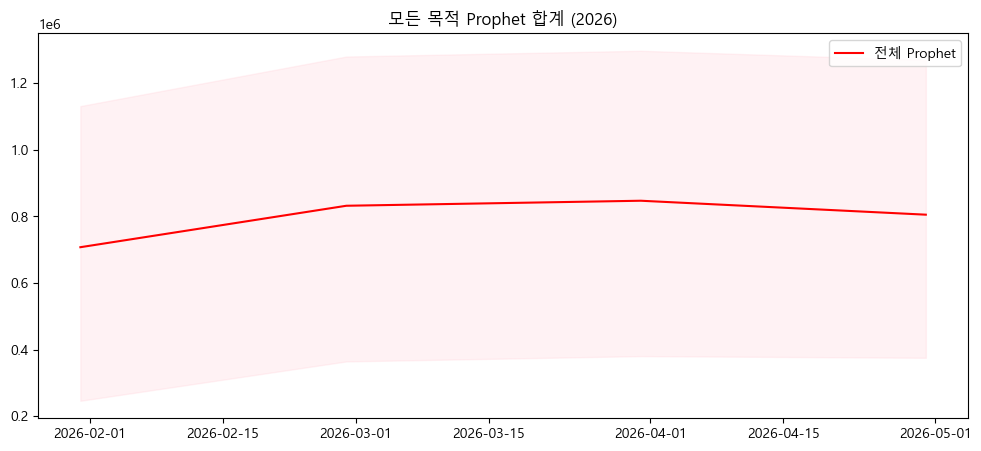

In [14]:
import pandas as pd
import numpy as np
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from datetime import datetime
from tabulate import tabulate

plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# 데이터 로드
df = pd.read_csv('../../jin/data/processed/외국인입국자_전처리완료_딥러닝용.csv')

country = input("국적 입력 (없으면 Enter): ").strip()
purpose = input("목적 입력 (없으면 Enter): ").strip()

if country:
    df = df[df['국적'] == country]
else:
    print("🌍 국적 미선택 → 모든 나라 사용")

purpose_list = [purpose] if purpose else df['목적'].unique()

df['연월'] = df['연도'].astype(str) + '-' + df['월'].astype(str).str.zfill(2)

# 국적 미선택이면 목적별로 합산
if not country:
    grouped = df.groupby(['연월', '목적'], as_index=False)['입국자수'].sum()
else:
    grouped = df.copy()

prophet_results = {}
xgb_results = {}
actuals = {}

# ✅ 목적별 Prophet + XGB
for pur in purpose_list:
    temp = grouped[grouped['목적'] == pur].copy()
    if temp.empty:
        print(f"❌ 데이터 없음: {pur}")
        continue

    temp['ds'] = pd.to_datetime(temp['연월'])
    temp['y'] = temp['입국자수']

    # Prophet
    m = Prophet(yearly_seasonality=True)
    m.fit(temp[['ds', 'y']])
    future = m.make_future_dataframe(periods=12, freq='M')
    forecast = m.predict(future)
    prophet_results[pur] = forecast

    # XGB
    temp['연도'] = temp['ds'].dt.year
    temp['월'] = temp['ds'].dt.month
    temp['lag_1'] = temp['y'].shift(1)
    temp = temp.dropna()

    X = temp[['연도', '월', 'lag_1']]
    y = temp['y']
    X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    xgb = XGBRegressor()
    xgb.fit(X_train_scaled, y_train)
    y_pred = xgb.predict(X_test_scaled)

    xgb_df = pd.DataFrame({'ds': temp.loc[X_test.index, 'ds'].values, 'xgb_yhat': y_pred})
    xgb_results[pur] = xgb_df
    actuals[pur] = temp

    # 목적별 Prophet + XGB 그래프
    plt.figure(figsize=(12,5))
    plt.plot(temp['ds'], temp['y'], label='실제값', color='black')
    plt.plot(forecast['ds'], forecast['yhat'], label='Prophet', color='red')
    plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'],
                     alpha=0.2, color='pink', label='Prophet 신뢰구간')
    plt.plot(xgb_df['ds'], xgb_df['xgb_yhat'], label='XGBoost', color='blue')
    plt.title(f"[{pur}] 모든 나라 Prophet + XGBoost")
    plt.legend()
    plt.show()

# ✅ 목적 미선택이면 전체 Prophet 합계
if not purpose:
    total_prophet = pd.concat(prophet_results.values()).groupby('ds').sum().reset_index()
    total_actuals = pd.concat(actuals.values()).groupby('ds').sum().reset_index()

    plt.figure(figsize=(14,6))
    plt.plot(total_actuals['ds'], total_actuals['y'], label='실제값 합계', color='black')
    plt.plot(total_prophet['ds'], total_prophet['yhat'], label='Prophet 합계', color='red')
    plt.fill_between(total_prophet['ds'], total_prophet['yhat_lower'], total_prophet['yhat_upper'],
                     alpha=0.3, color='pink', label='Prophet 신뢰구간')
    plt.title("모든 목적 합계 Prophet")
    plt.legend()
    plt.show()

# ✅ 원하는 연월
print("\n📅 원하는 연월 선택")
now = pd.to_datetime(datetime.now()).replace(day=1)
possible = pd.date_range(now, now + pd.DateOffset(months=24), freq='MS').strftime('%Y-%m').tolist()
rows = [possible[i:i+6] for i in range(0, len(possible), 6)]
print(tabulate(rows, tablefmt="grid"))

query = input("연월 입력 (202507 또는 2025-07): ").strip().replace('-', '')
if len(query) == 6:
    query = f"{query[:4]}-{query[4:]}"
query_date = pd.to_datetime(query + "-01")
query_year = query_date.year

# ✅ 선택 목적 있으면 → 선택 목적 Prophet+XGB + 전체 Prophet 합계
if purpose:
    fc = prophet_results[purpose]
    one_year = fc[fc['ds'].dt.year == query_year]

    plt.figure(figsize=(12,5))
    plt.plot(one_year['ds'], one_year['yhat'], label='Prophet', color='red')
    plt.fill_between(one_year['ds'], one_year['yhat_lower'], one_year['yhat_upper'],
                     alpha=0.3, color='pink')
    xgb = xgb_results[purpose]
    xgb_year = xgb[xgb['ds'].dt.year == query_year]
    plt.plot(xgb_year['ds'], xgb_year['xgb_yhat'], label='XGBoost', color='blue')

    point = one_year.loc[one_year['ds'] == query_date, 'yhat']
    if not point.empty:
        plt.scatter(query_date, point.values[0], color='black', label='선택달')
        print(f"{purpose} / {query}: {int(point.values[0]):,}명")
    else:
        print(f"❗ {purpose} {query} 데이터 없음")

    plt.title(f"{purpose} Prophet+XGB ({query_year})")
    plt.legend()
    plt.show()

    total_prophet = pd.concat(prophet_results.values()).groupby('ds').sum().reset_index()
    one_year_sum = total_prophet[total_prophet['ds'].dt.year == query_year]

    plt.figure(figsize=(12,5))
    plt.plot(one_year_sum['ds'], one_year_sum['yhat'], label='전체 Prophet', color='red')
    plt.fill_between(one_year_sum['ds'], one_year_sum['yhat_lower'], one_year_sum['yhat_upper'],
                     alpha=0.2, color='pink')

    p2 = one_year_sum.loc[one_year_sum['ds'] == query_date, 'yhat']
    if not p2.empty:
        plt.scatter(query_date, p2.values[0], color='black', label='선택달')
        print(f"모든 목적 합계 / {query}: {int(p2.values[0]):,}명")
    else:
        print(f"❗ 전체 목적 {query} 데이터 없음")

    plt.title(f"모든 목적 Prophet 합계 ({query_year})")
    plt.legend()
    plt.show()

# ✅ 목적 미선택이면 → Prophet 합계만
if not purpose:
    one_year_sum = total_prophet[total_prophet['ds'].dt.year == query_year]

    plt.figure(figsize=(12,5))
    plt.plot(one_year_sum['ds'], one_year_sum['yhat'], label='전체 Prophet', color='red')
    plt.fill_between(one_year_sum['ds'], one_year_sum['yhat_lower'], one_year_sum['yhat_upper'],
                     alpha=0.2, color='pink')

    p2 = one_year_sum.loc[one_year_sum['ds'] == query_date, 'yhat']
    if not p2.empty:
        plt.scatter(query_date, p2.values[0], color='black', label='선택달')
        print(f"모든 목적 합계 / {query}: {int(p2.values[0]):,}명")
    else:
        print(f"❗ 전체 목적 {query} 데이터 없음")

    plt.title(f"모든 목적 Prophet 합계 ({query_year})")
    plt.legend()
    plt.show()


국적 입력 (없으면 Enter): 중국
목적 입력 (없으면 Enter): 


09:34:20 - cmdstanpy - INFO - Chain [1] start processing
09:34:20 - cmdstanpy - INFO - Chain [1] done processing


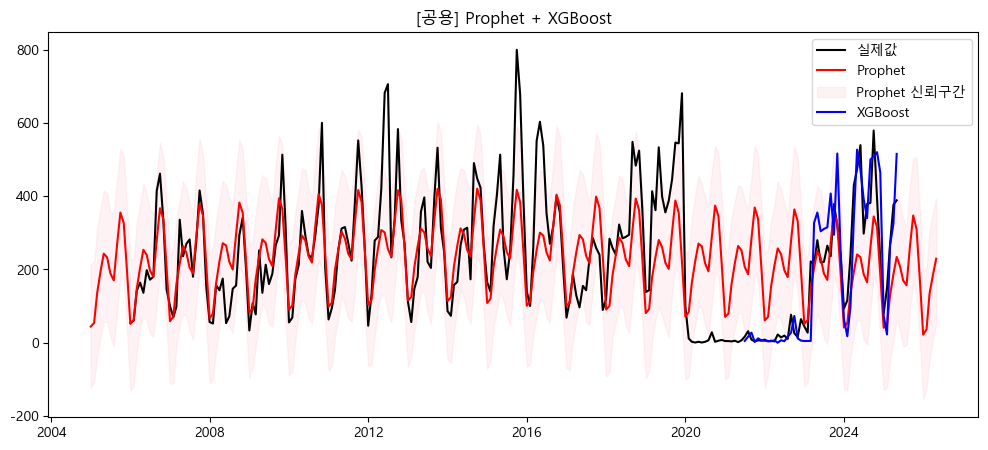

09:34:21 - cmdstanpy - INFO - Chain [1] start processing
09:34:21 - cmdstanpy - INFO - Chain [1] done processing


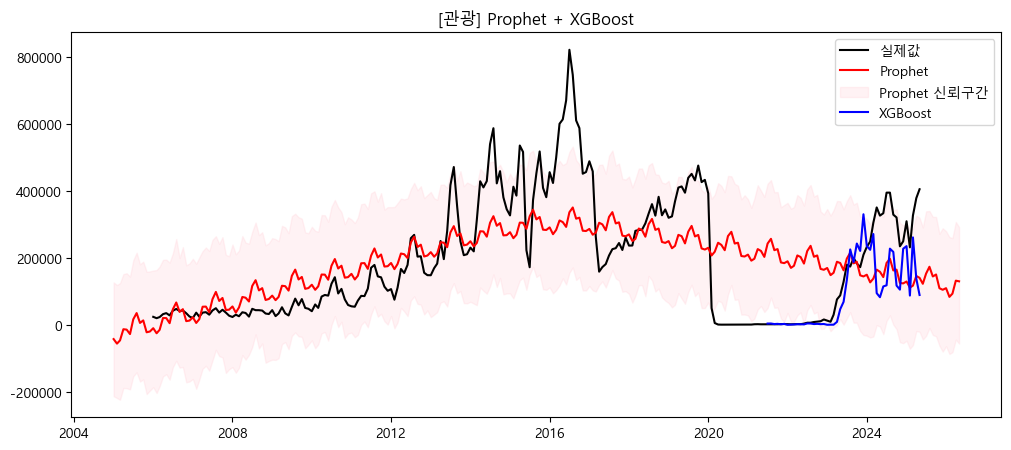

09:34:22 - cmdstanpy - INFO - Chain [1] start processing
09:34:22 - cmdstanpy - INFO - Chain [1] done processing


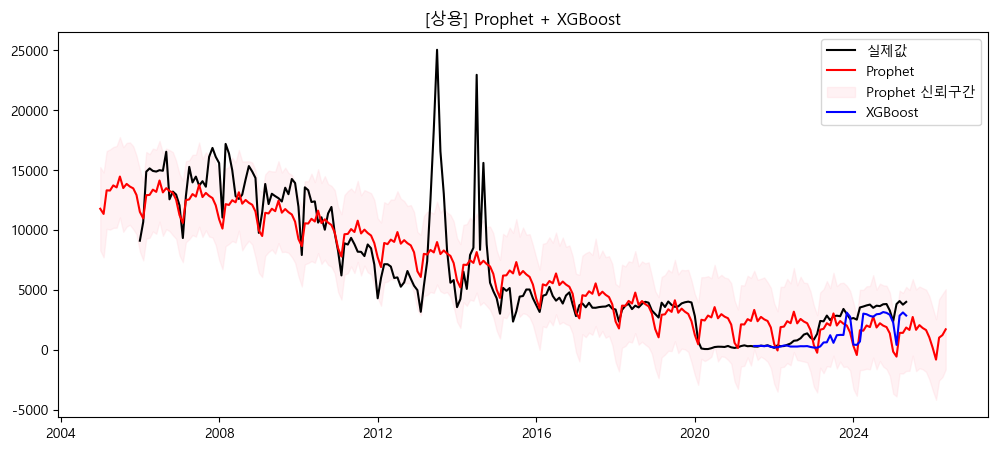

09:34:22 - cmdstanpy - INFO - Chain [1] start processing
09:34:22 - cmdstanpy - INFO - Chain [1] done processing


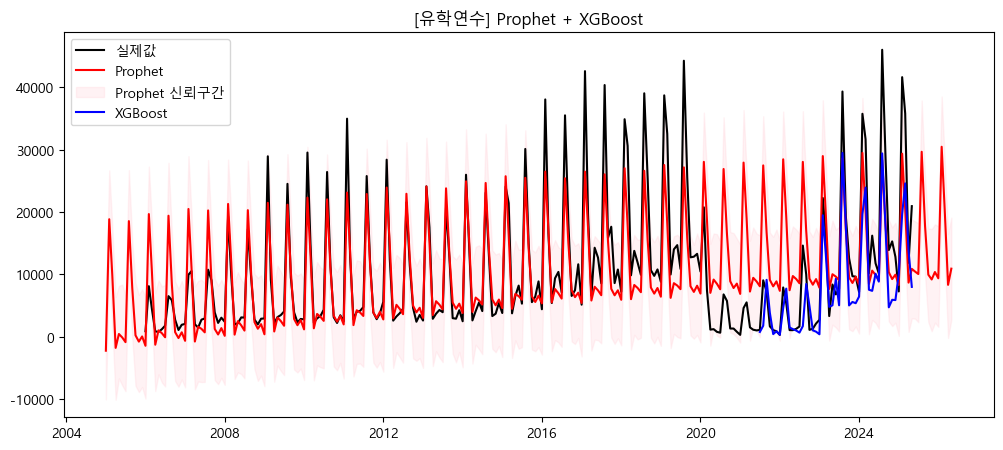

C:\Users\Admin\AppData\Local\Temp\ipykernel_3392\1151280922.py:95: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  total_actuals = pd.concat(actuals.values()).groupby('ds').sum().reset_index()


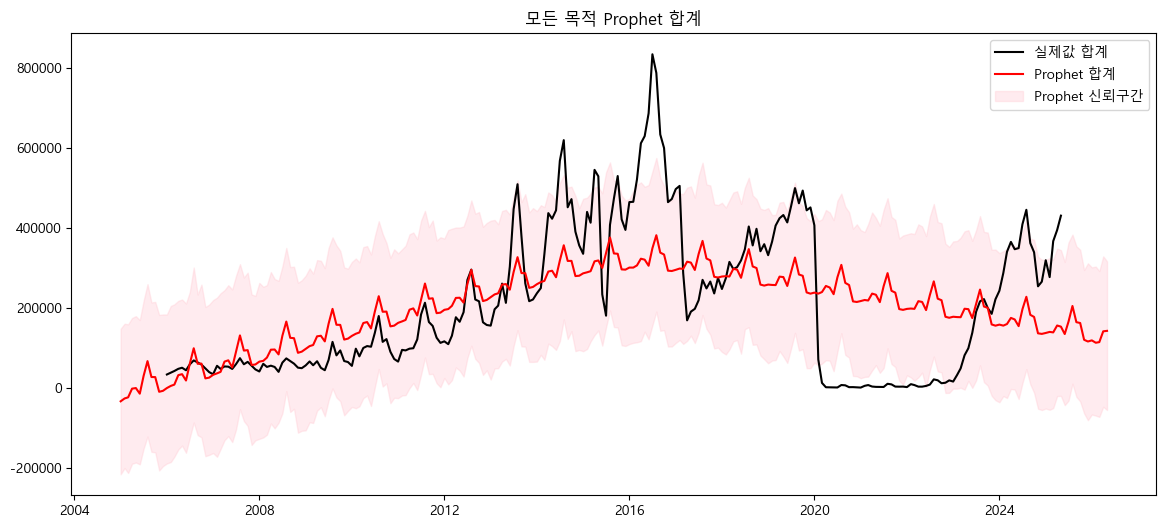


📅 원하는 연월 선택
+---------+---------+---------+---------+---------+---------+
| 2025-07 | 2025-08 | 2025-09 | 2025-10 | 2025-11 | 2025-12 |
+---------+---------+---------+---------+---------+---------+
| 2026-01 | 2026-02 | 2026-03 | 2026-04 | 2026-05 | 2026-06 |
+---------+---------+---------+---------+---------+---------+
| 2026-07 | 2026-08 | 2026-09 | 2026-10 | 2026-11 | 2026-12 |
+---------+---------+---------+---------+---------+---------+
| 2027-01 | 2027-02 | 2027-03 | 2027-04 | 2027-05 | 2027-06 |
+---------+---------+---------+---------+---------+---------+
| 2027-07 |         |         |         |         |         |
+---------+---------+---------+---------+---------+---------+
연월 입력 (202507 또는 2025-07): 202606
❗ 전체 목적 2026-06 데이터 없음


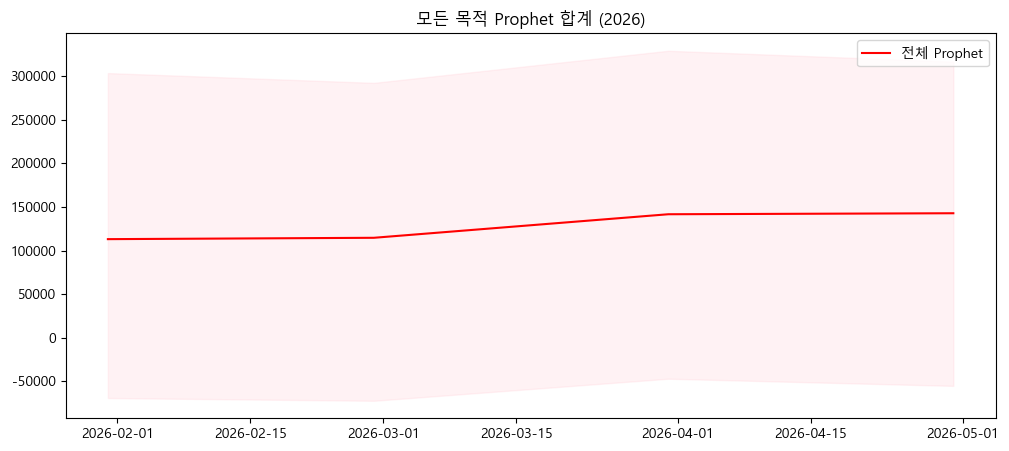

In [4]:
import pandas as pd
import numpy as np
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from datetime import datetime
from tabulate import tabulate

plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# 데이터 로드
df = pd.read_csv('../data/외국인입국자_전처리완료_딥러닝용.csv')

country = input("국적 입력 (없으면 Enter): ").strip()
purpose = input("목적 입력 (없으면 Enter): ").strip()

if country:
    df = df[df['국적'] == country]
else:
    print("🌍 국적 미선택 → 모든 나라 사용")

purpose_list = [purpose] if purpose else df['목적'].unique()

df['연월'] = df['연도'].astype(str) + '-' + df['월'].astype(str).str.zfill(2)

# 국적 미선택이면 목적별로 합산
if not country:
    grouped = df.groupby(['연월', '목적'], as_index=False)['입국자수'].sum()
else:
    grouped = df.copy()

prophet_results = {}
xgb_results = {}
actuals = {}

# ✅ Prophet + XGB 목적별 루프
for pur in purpose_list:
    temp = grouped[grouped['목적'] == pur].copy()
    if temp.empty:
        print(f"❌ 데이터 없음: {pur}")
        continue

    temp['ds'] = pd.to_datetime(temp['연월'])
    temp['y'] = temp['입국자수']

    # Prophet
    m = Prophet(yearly_seasonality=True)
    m.fit(temp[['ds', 'y']])
    future = m.make_future_dataframe(periods=12, freq='M')
    forecast = m.predict(future)
    prophet_results[pur] = forecast

    # XGB
    temp['연도'] = temp['ds'].dt.year
    temp['월'] = temp['ds'].dt.month
    temp['lag_1'] = temp['y'].shift(1)
    temp = temp.dropna()

    X = temp[['연도', '월', 'lag_1']]
    y = temp['y']
    X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    xgb = XGBRegressor()
    xgb.fit(X_train_scaled, y_train)
    y_pred = xgb.predict(X_test_scaled)

    # ✅ 안전 loc로 index 정렬
    xgb_df = pd.DataFrame({
        'ds': temp.loc[X_test.index, 'ds'].values,
        'xgb_yhat': y_pred
    })
    xgb_results[pur] = xgb_df
    actuals[pur] = temp

    # 목적별 Prophet + XGB 그래프
    plt.figure(figsize=(12,5))
    plt.plot(temp['ds'], temp['y'], label='실제값', color='black')
    plt.plot(forecast['ds'], forecast['yhat'], label='Prophet', color='red')
    plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'],
                     alpha=0.2, color='pink', label='Prophet 신뢰구간')
    plt.plot(xgb_df['ds'], xgb_df['xgb_yhat'], label='XGBoost', color='blue')
    plt.title(f"[{pur}] Prophet + XGBoost")
    plt.legend()
    plt.show()

# ✅ 전체 Prophet 합계 (목적 미선택 시)
if not purpose:
    total_prophet = pd.concat(prophet_results.values()).groupby('ds').sum().reset_index()
    total_actuals = pd.concat(actuals.values()).groupby('ds').sum().reset_index()

    plt.figure(figsize=(14,6))
    plt.plot(total_actuals['ds'], total_actuals['y'], label='실제값 합계', color='black')
    plt.plot(total_prophet['ds'], total_prophet['yhat'], label='Prophet 합계', color='red')
    plt.fill_between(total_prophet['ds'], total_prophet['yhat_lower'], total_prophet['yhat_upper'],
                     alpha=0.3, color='pink', label='Prophet 신뢰구간')
    plt.title("모든 목적 Prophet 합계")
    plt.legend()
    plt.show()

# ✅ 원하는 연월
print("\n📅 원하는 연월 선택")
now = pd.to_datetime(datetime.now()).replace(day=1)
possible = pd.date_range(now, now + pd.DateOffset(months=24), freq='MS').strftime('%Y-%m').tolist()
rows = [possible[i:i+6] for i in range(0, len(possible), 6)]
print(tabulate(rows, tablefmt="grid"))

query = input("연월 입력 (202507 또는 2025-07): ").strip().replace('-', '')
if len(query) == 6:
    query = f"{query[:4]}-{query[4:]}"
query_date = pd.to_datetime(query + "-01")
query_year = query_date.year

# ✅ 목적 선택시: Prophet+XGB + 전체 Prophet
if purpose:
    fc = prophet_results[purpose]
    one_year = fc[fc['ds'].dt.year == query_year]

    plt.figure(figsize=(12,5))
    plt.plot(one_year['ds'], one_year['yhat'], label='Prophet', color='red')
    plt.fill_between(one_year['ds'], one_year['yhat_lower'], one_year['yhat_upper'],
                     alpha=0.3, color='pink')

    xgb = xgb_results[purpose]
    xgb_year = xgb[xgb['ds'].dt.year == query_year]
    plt.plot(xgb_year['ds'], xgb_year['xgb_yhat'], label='XGBoost', color='blue')

    # ✅ 선택 달 비교: to_period(M)
    point = one_year[one_year['ds'].dt.to_period('M') == query_date.to_period('M')]
    if not point.empty:
        y_val = point['yhat'].values[0]
        plt.scatter(query_date, y_val, color='black', label='선택달')
        plt.annotate(f"{int(y_val):,}", xy=(query_date, y_val),
                     xytext=(0,10), textcoords='offset points',
                     ha='center', fontsize=10, color='black')
        print(f"{purpose} / {query}: {int(y_val):,}명")
    else:
        print(f"❗ {purpose} {query} 데이터 없음")

    plt.title(f"{purpose} Prophet+XGB ({query_year})")
    plt.legend()
    plt.show()

    # ✅ 전체 Prophet 합계
    total_prophet = pd.concat(prophet_results.values()).groupby('ds').sum().reset_index()
    one_year_sum = total_prophet[total_prophet['ds'].dt.year == query_year]

    plt.figure(figsize=(12,5))
    plt.plot(one_year_sum['ds'], one_year_sum['yhat'], label='전체 Prophet', color='red')
    plt.fill_between(one_year_sum['ds'], one_year_sum['yhat_lower'], one_year_sum['yhat_upper'],
                     alpha=0.2, color='pink')

    p2 = one_year_sum[one_year_sum['ds'].dt.to_period('M') == query_date.to_period('M')]
    if not p2.empty:
        y_val = p2['yhat'].values[0]
        plt.scatter(query_date, y_val, color='black', label='선택달')
        plt.annotate(f"{int(y_val):,}", xy=(query_date, y_val),
                     xytext=(0,10), textcoords='offset points',
                     ha='center', fontsize=10, color='black')
        print(f"모든 목적 합계 / {query}: {int(y_val):,}명")
    else:
        print(f"❗ 전체 목적 {query} 데이터 없음")

    plt.title(f"모든 목적 Prophet 합계 ({query_year})")
    plt.legend()
    plt.show()

# ✅ 목적 미선택이면 Prophet 합계만
if not purpose:
    one_year_sum = total_prophet[total_prophet['ds'].dt.year == query_year]

    plt.figure(figsize=(12,5))
    plt.plot(one_year_sum['ds'], one_year_sum['yhat'], label='전체 Prophet', color='red')
    plt.fill_between(one_year_sum['ds'], one_year_sum['yhat_lower'], one_year_sum['yhat_upper'],
                     alpha=0.2, color='pink')

    p2 = one_year_sum[one_year_sum['ds'].dt.to_period('M') == query_date.to_period('M')]
    if not p2.empty:
        y_val = p2['yhat'].values[0]
        plt.scatter(query_date, y_val, color='black', label='선택달')
        plt.annotate(f"{int(y_val):,}", xy=(query_date, y_val),
                     xytext=(0,10), textcoords='offset points',
                     ha='center', fontsize=10, color='black')
        print(f"모든 목적 합계 / {query}: {int(y_val):,}명")
    else:
        print(f"❗ 전체 목적 {query} 데이터 없음")

    plt.title(f"모든 목적 Prophet 합계 ({query_year})")
    plt.legend()
    plt.show()


In [6]:
# !pip install optuna


   ---------- ----------------------------- 1/4 [colorlog]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ---------------------------------------- 4/4 [optuna]



국적 입력 (없으면 Enter): 
목적 입력 (없으면 Enter): 
🌍 국적 미선택 → 모든 나라 사용


12:18:52 - cmdstanpy - INFO - Chain [1] start processing
12:18:52 - cmdstanpy - INFO - Chain [1] done processing
[I 2025-07-14 12:18:52,778] A new study created in memory with name: no-name-2aff7fc3-7876-4781-a28c-66cf55af25bb
[I 2025-07-14 12:18:52,865] Trial 0 finished with value: 1628276.2965566549 and parameters: {'max_depth': 5, 'learning_rate': 0.17150446443408232, 'n_estimators': 179, 'subsample': 0.7366317377868146}. Best is trial 0 with value: 1628276.2965566549.
[I 2025-07-14 12:18:52,931] Trial 1 finished with value: 2011120.750944797 and parameters: {'max_depth': 2, 'learning_rate': 0.06265702484460196, 'n_estimators': 279, 'subsample': 0.7353063466039663}. Best is trial 0 with value: 1628276.2965566549.
[I 2025-07-14 12:18:52,974] Trial 2 finished with value: 1805656.2584908085 and parameters: {'max_depth': 3, 'learning_rate': 0.10816775039264202, 'n_estimators': 122, 'subsample': 0.9868727870427818}. Best is trial 0 with value: 1628276.2965566549.
[I 2025-07-14 12:18:53,0


[공용] Prophet 예측 정확도 (최근 12개월)
 - RMSE: 3043.7 / MAPE: 45.96% / R²: -10.504 → ❗ 예측력 낮음 (참고용)
[공용] XGBoost 예측 정확도 (테스트셋)
 - RMSE: 1223.2 / MAPE: 25.06% / R²: 0.492 → ❗ 예측력 낮음 (참고용)
[공용] Prophet 미래 마지막달(2027-04) 예측값: 8,736명 (신뢰구간: 7,884 ~ 9,572)


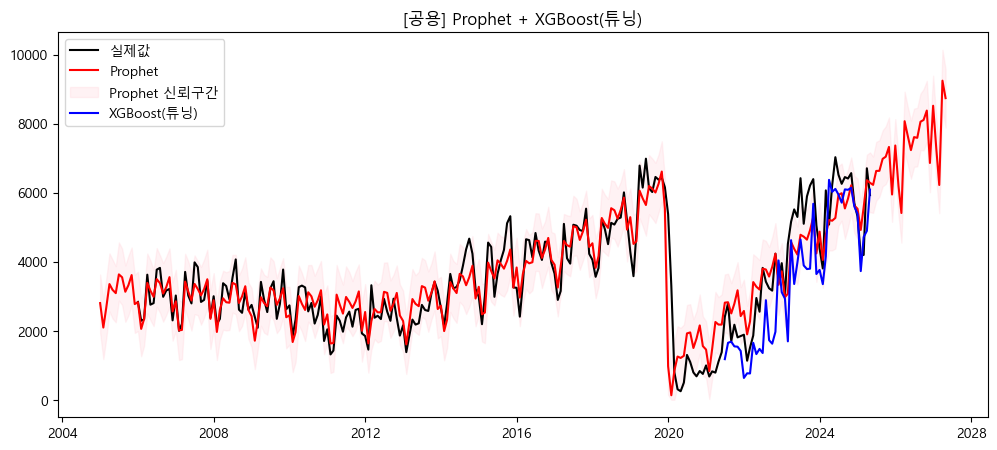

12:18:55 - cmdstanpy - INFO - Chain [1] start processing
12:18:55 - cmdstanpy - INFO - Chain [1] done processing
[I 2025-07-14 12:18:55,360] A new study created in memory with name: no-name-8e5fd5ae-b707-447a-805a-a516062ae415
[I 2025-07-14 12:18:55,413] Trial 0 finished with value: 56050764350.412254 and parameters: {'max_depth': 2, 'learning_rate': 0.04993751074993171, 'n_estimators': 197, 'subsample': 0.7196712120161884}. Best is trial 0 with value: 56050764350.412254.
[I 2025-07-14 12:18:55,494] Trial 1 finished with value: 40699846078.93351 and parameters: {'max_depth': 4, 'learning_rate': 0.13354583914223353, 'n_estimators': 157, 'subsample': 0.8984847949842623}. Best is trial 1 with value: 40699846078.93351.
[I 2025-07-14 12:18:55,572] Trial 2 finished with value: 42598661104.89068 and parameters: {'max_depth': 5, 'learning_rate': 0.07113501170576464, 'n_estimators': 134, 'subsample': 0.9451843178371145}. Best is trial 1 with value: 40699846078.93351.
[I 2025-07-14 12:18:55,599]


[관광] Prophet 예측 정확도 (최근 12개월)
 - RMSE: 968448.0 / MAPE: 78.34% / R²: -28.451 → ❗ 예측력 낮음 (참고용)
[관광] XGBoost 예측 정확도 (테스트셋)
 - RMSE: 194341.9 / MAPE: 36.53% / R²: 0.840 → 👍 예측력 양호
[관광] Prophet 미래 마지막달(2027-04) 예측값: 1,613,814명 (신뢰구간: 1,391,296 ~ 1,842,571)


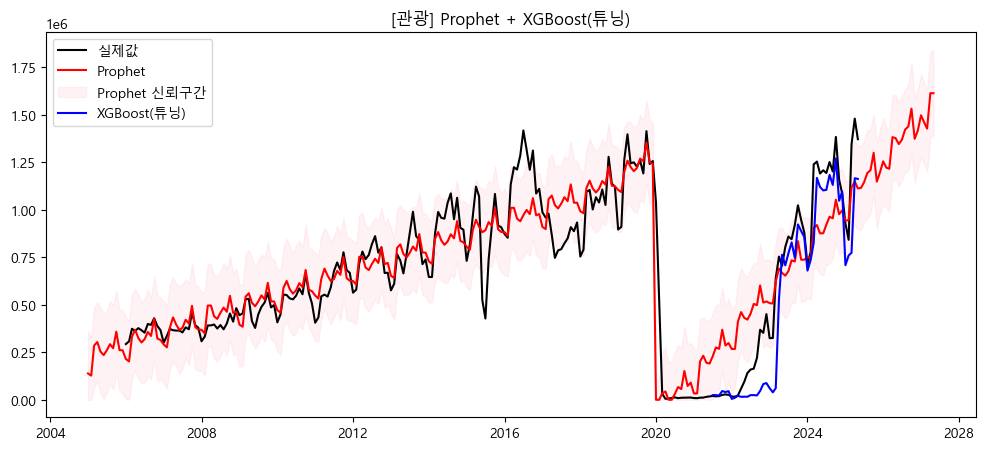

12:18:57 - cmdstanpy - INFO - Chain [1] start processing
12:18:57 - cmdstanpy - INFO - Chain [1] done processing
[I 2025-07-14 12:18:57,761] A new study created in memory with name: no-name-12b40531-6013-46fa-9a19-29887713d0f9
[I 2025-07-14 12:18:57,867] Trial 0 finished with value: 39199152.21328406 and parameters: {'max_depth': 5, 'learning_rate': 0.027953931707330286, 'n_estimators': 248, 'subsample': 0.9612409086524413}. Best is trial 0 with value: 39199152.21328406.
[I 2025-07-14 12:18:57,888] Trial 1 finished with value: 36512756.59193242 and parameters: {'max_depth': 2, 'learning_rate': 0.18120002855634468, 'n_estimators': 50, 'subsample': 0.9665447745632759}. Best is trial 1 with value: 36512756.59193242.
[I 2025-07-14 12:18:57,934] Trial 2 finished with value: 36271984.126290895 and parameters: {'max_depth': 5, 'learning_rate': 0.046258564428577204, 'n_estimators': 79, 'subsample': 0.9400368079551996}. Best is trial 2 with value: 36271984.126290895.
[I 2025-07-14 12:18:57,967]


[상용] Prophet 예측 정확도 (최근 12개월)
 - RMSE: 15019.6 / MAPE: 127.57% / R²: -232.824 → ❗ 예측력 낮음 (참고용)
[상용] XGBoost 예측 정확도 (테스트셋)
 - RMSE: 4727.5 / MAPE: 45.59% / R²: -0.605 → ❗ 예측력 낮음 (참고용)
[상용] Prophet 미래 마지막달(2027-04) 예측값: 16,603명 (신뢰구간: 12,481 ~ 21,134)


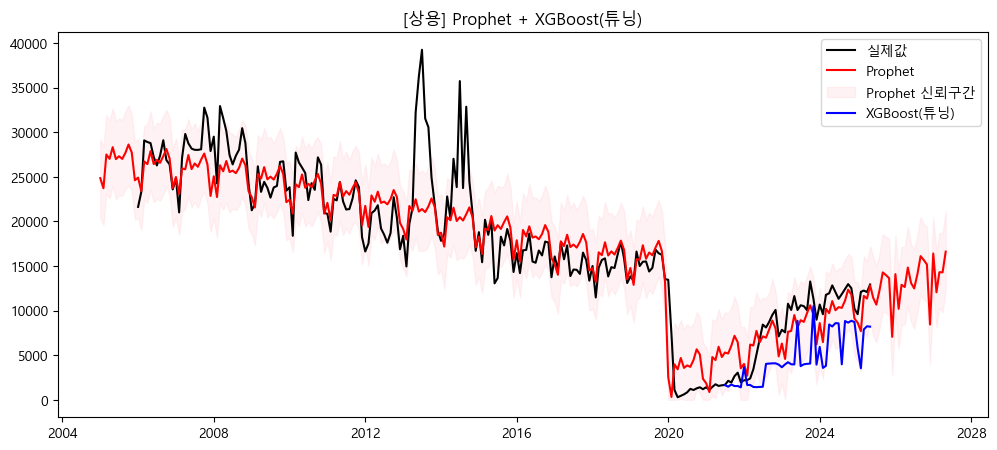

12:19:00 - cmdstanpy - INFO - Chain [1] start processing
12:19:00 - cmdstanpy - INFO - Chain [1] done processing
[I 2025-07-14 12:19:00,248] A new study created in memory with name: no-name-68a1fb88-e9c0-416b-b096-6e690966035d
[I 2025-07-14 12:19:00,408] Trial 0 finished with value: 341626733.8052629 and parameters: {'max_depth': 6, 'learning_rate': 0.09895955642622817, 'n_estimators': 300, 'subsample': 0.8529258389626482}. Best is trial 0 with value: 341626733.8052629.
[I 2025-07-14 12:19:00,500] Trial 1 finished with value: 394359009.069925 and parameters: {'max_depth': 6, 'learning_rate': 0.19434606710377658, 'n_estimators': 156, 'subsample': 0.7219856159785041}. Best is trial 0 with value: 341626733.8052629.
[I 2025-07-14 12:19:00,602] Trial 2 finished with value: 402054144.27668184 and parameters: {'max_depth': 4, 'learning_rate': 0.07316259873004058, 'n_estimators': 288, 'subsample': 0.7524621065738758}. Best is trial 0 with value: 341626733.8052629.
[I 2025-07-14 12:19:00,652] T


[유학연수] Prophet 예측 정확도 (최근 12개월)
 - RMSE: 42768.9 / MAPE: 84.08% / R²: -2.166 → ❗ 예측력 낮음 (참고용)
[유학연수] XGBoost 예측 정확도 (테스트셋)
 - RMSE: 18483.1 / MAPE: 38.24% / R²: 0.267 → ❗ 예측력 낮음 (참고용)
[유학연수] Prophet 미래 마지막달(2027-04) 예측값: 39,758명 (신뢰구간: 31,139 ~ 47,754)


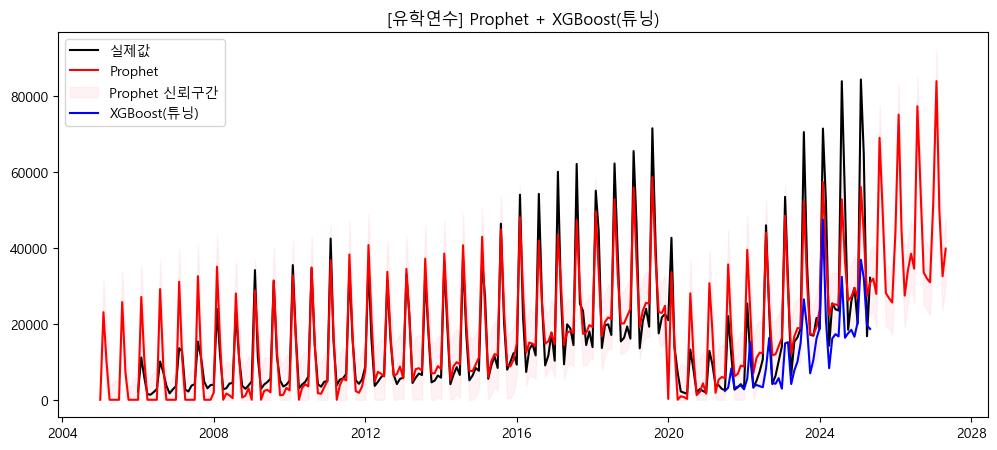

C:\Users\Admin\AppData\Local\Temp\ipykernel_17376\3744620554.py:151: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  total_actuals = pd.concat(actuals.values()).groupby('ds').sum().reset_index()



[전체 목적] Prophet 예측 정확도 (최근 12개월)
 - RMSE: 989306.8 / MAPE: 76.52% / R²: -31.284 → ❗ 예측력 낮음 (참고용)
[전체 목적] Prophet 미래 마지막달(2027-04) 예측값: 1,678,913명 (신뢰구간: 1,442,801 ~ 1,921,033)


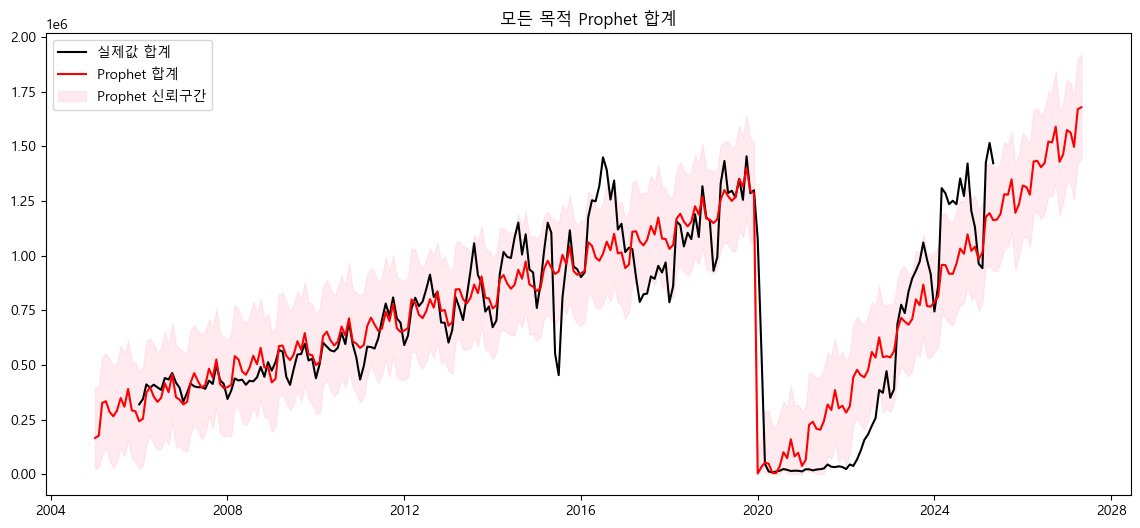


📅 원하는 연월 선택
+---------+---------+---------+---------+---------+---------+
| 2025-07 | 2025-08 | 2025-09 | 2025-10 | 2025-11 | 2025-12 |
+---------+---------+---------+---------+---------+---------+
| 2026-01 | 2026-02 | 2026-03 | 2026-04 | 2026-05 | 2026-06 |
+---------+---------+---------+---------+---------+---------+
| 2026-07 | 2026-08 | 2026-09 | 2026-10 | 2026-11 | 2026-12 |
+---------+---------+---------+---------+---------+---------+
| 2027-01 | 2027-02 | 2027-03 | 2027-04 | 2027-05 | 2027-06 |
+---------+---------+---------+---------+---------+---------+
| 2027-07 |         |         |         |         |         |
+---------+---------+---------+---------+---------+---------+
연월 입력 (202507 또는 2025-07): 202705


C:\Users\Admin\AppData\Local\Temp\ipykernel_17376\3744620554.py:268: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  one_year_sum[['yhat', 'yhat_lower', 'yhat_upper']] = one_year_sum[['yhat', 'yhat_lower', 'yhat_upper']].clip(lower=0)


❗ 전체 목적 2027-05 데이터 없음


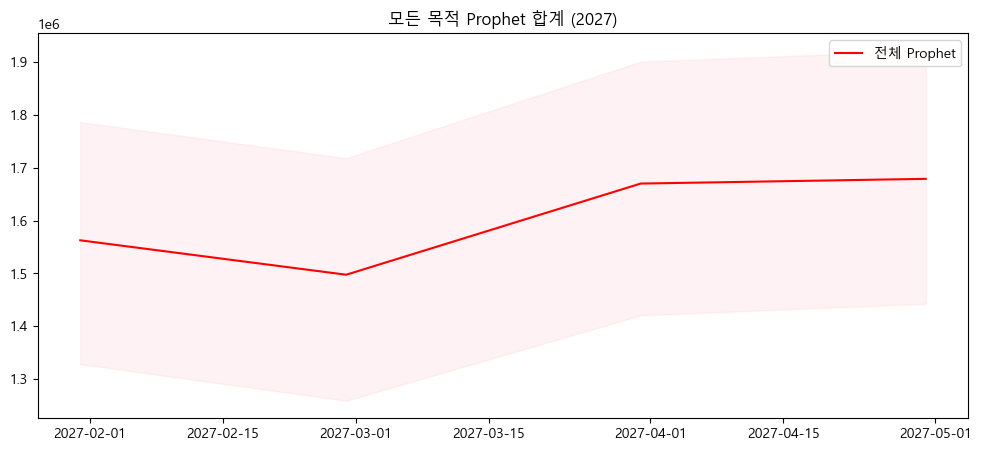

In [4]:
import pandas as pd
import numpy as np
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
import optuna
import matplotlib.pyplot as plt
from datetime import datetime
from tabulate import tabulate

plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

df = pd.read_csv('../data/외국인입국자_전처리완료_딥러닝용.csv')
df['성수기'] = df['월'].isin([7, 8, 12]).astype(int)
df['명절'] = df['월'].isin([1, 2, 9, 10]).astype(int)
df['코로나'] = (df['연도'] >= 2020).astype(int)

country = input("국적 입력 (없으면 Enter): ").strip()
purpose = input("목적 입력 (없으면 Enter): ").strip()

if country:
    df = df[df['국적'] == country]
else:
    print("🌍 국적 미선택 → 모든 나라 사용")

purpose_list = [purpose] if purpose else df['목적'].unique()
df['연월'] = df['연도'].astype(str) + '-' + df['월'].astype(str).str.zfill(2)

if not country:
    grouped = df.groupby(['연월', '목적', '성수기', '명절', '코로나'], as_index=False)['입국자수'].sum()
else:
    grouped = df.copy()

prophet_results = {}
xgb_results = {}
actuals = {}

def explain_score(r2, mape):
    if r2 >= 0.9:
        return "✅ 예측력 매우 우수 (신뢰도 높음)"
    elif r2 >= 0.7:
        return "👍 예측력 양호"
    elif r2 >= 0.5:
        return "⚠️ 예측력 보통 (개선 가능)"
    else:
        return "❗ 예측력 낮음 (참고용)"

def tune_xgb(X, y):
    def objective(trial):
        params = {
            'max_depth': trial.suggest_int('max_depth', 2, 6),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        }
        model = XGBRegressor(**params)
        X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, shuffle=False)
        model.fit(X_tr, y_tr)
        pred = model.predict(X_val)
        return np.mean((y_val - pred) ** 2)
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=20, show_progress_bar=False)
    return study.best_params

for pur in purpose_list:
    temp = grouped[grouped['목적'] == pur].copy()
    if temp.empty:
        print(f"❌ 데이터 없음: {pur}")
        continue

    temp['ds'] = pd.to_datetime(temp['연월'])
    temp['y'] = temp['입국자수']

    # Prophet + 설명변수
    m = Prophet(yearly_seasonality=True)
    m.add_regressor('성수기')
    m.add_regressor('명절')
    m.add_regressor('코로나')
    m.fit(temp[['ds', 'y', '성수기', '명절', '코로나']])
    future = m.make_future_dataframe(periods=24, freq='M')
    future['월'] = future['ds'].dt.month
    future['성수기'] = future['월'].isin([7, 8, 12]).astype(int)
    future['명절'] = future['월'].isin([1, 2, 9, 10]).astype(int)
    future['코로나'] = (future['ds'].dt.year >= 2020).astype(int)
    forecast = m.predict(future)
    # ======= 마이너스 0으로 보정 =======
    forecast[['yhat', 'yhat_lower', 'yhat_upper']] = forecast[['yhat', 'yhat_lower', 'yhat_upper']].clip(lower=0)
    prophet_results[pur] = forecast

    # XGB (튜닝)
    temp['연도'] = temp['ds'].dt.year
    temp['월'] = temp['ds'].dt.month
    temp['lag_1'] = temp['y'].shift(1)
    temp['lag_3'] = temp['y'].shift(3)
    temp['lag_12'] = temp['y'].shift(12)
    temp = temp.dropna()
    features = ['연도', '월', 'lag_1', 'lag_3', 'lag_12', '성수기', '명절', '코로나']
    X = temp[features]
    y = temp['y']
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    best_params = tune_xgb(X_scaled, y)
    xgb = XGBRegressor(**best_params)
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, shuffle=False, test_size=0.2)
    xgb.fit(X_train, y_train)
    y_pred = xgb.predict(X_test)

    xgb_df = pd.DataFrame({
        'ds': temp.iloc[-len(y_test):]['ds'].values,
        'xgb_yhat': y_pred
    })
    # ======= 마이너스 0으로 보정 =======
    xgb_df['xgb_yhat'] = xgb_df['xgb_yhat'].clip(lower=0)
    xgb_results[pur] = xgb_df
    actuals[pur] = temp

    # ========== 예측값 및 평가 해석 ==========
    real = temp['y'][-12:].values
    fcst = forecast['yhat'][:len(real)]  # 과거 구간 prophet 예측
    rmse_p = np.sqrt(mean_squared_error(real, fcst))
    r2_p = r2_score(real, fcst)
    mape_p = mean_absolute_percentage_error(real, fcst) * 100
    print(f"\n[{pur}] Prophet 예측 정확도 (최근 12개월)")
    print(f" - RMSE: {rmse_p:.1f} / MAPE: {mape_p:.2f}% / R²: {r2_p:.3f} → {explain_score(r2_p, mape_p)}")

    rmse_x = np.sqrt(mean_squared_error(y_test, y_pred))
    r2_x = r2_score(y_test, y_pred)
    mape_x = mean_absolute_percentage_error(y_test, y_pred) * 100
    print(f"[{pur}] XGBoost 예측 정확도 (테스트셋)")
    print(f" - RMSE: {rmse_x:.1f} / MAPE: {mape_x:.2f}% / R²: {r2_x:.3f} → {explain_score(r2_x, mape_x)}")

    last = forecast.iloc[-1]
    print(f"[{pur}] Prophet 미래 마지막달({last['ds'].strftime('%Y-%m')}) 예측값: {int(last['yhat']):,}명 (신뢰구간: {int(last['yhat_lower']):,} ~ {int(last['yhat_upper']):,})")

    plt.figure(figsize=(12,5))
    plt.plot(temp['ds'], temp['y'], label='실제값', color='black')
    plt.plot(forecast['ds'], forecast['yhat'], label='Prophet', color='red')
    plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'],
                     alpha=0.2, color='pink', label='Prophet 신뢰구간')
    plt.plot(xgb_df['ds'], xgb_df['xgb_yhat'], label='XGBoost(튜닝)', color='blue')
    plt.title(f"[{pur}] Prophet + XGBoost(튜닝)")
    plt.legend()
    plt.show()

if not purpose:
    total_prophet = pd.concat(prophet_results.values()).groupby('ds').sum().reset_index()
    total_actuals = pd.concat(actuals.values()).groupby('ds').sum().reset_index()
    # ======= 마이너스 0으로 보정 =======
    total_prophet[['yhat', 'yhat_lower', 'yhat_upper']] = total_prophet[['yhat', 'yhat_lower', 'yhat_upper']].clip(lower=0)
    real = total_actuals['y'][-12:].values
    fcst = total_prophet['yhat'][:len(real)]
    rmse_p = np.sqrt(mean_squared_error(real, fcst))
    r2_p = r2_score(real, fcst)
    mape_p = mean_absolute_percentage_error(real, fcst) * 100
    print(f"\n[전체 목적] Prophet 예측 정확도 (최근 12개월)")
    print(f" - RMSE: {rmse_p:.1f} / MAPE: {mape_p:.2f}% / R²: {r2_p:.3f} → {explain_score(r2_p, mape_p)}")

    last = total_prophet.iloc[-1]
    print(f"[전체 목적] Prophet 미래 마지막달({last['ds'].strftime('%Y-%m')}) 예측값: {int(last['yhat']):,}명 (신뢰구간: {int(last['yhat_lower']):,} ~ {int(last['yhat_upper']):,})")

    plt.figure(figsize=(14,6))
    plt.plot(total_actuals['ds'], total_actuals['y'], label='실제값 합계', color='black')
    plt.plot(total_prophet['ds'], total_prophet['yhat'], label='Prophet 합계', color='red')
    plt.fill_between(total_prophet['ds'], total_prophet['yhat_lower'], total_prophet['yhat_upper'],
                     alpha=0.3, color='pink', label='Prophet 신뢰구간')
    plt.title("모든 목적 Prophet 합계")
    plt.legend()
    plt.show()

print("\n📅 원하는 연월 선택")
now = pd.to_datetime(datetime.now()).replace(day=1)
possible = pd.date_range(now, now + pd.DateOffset(months=24), freq='MS').strftime('%Y-%m').tolist()
rows = [possible[i:i+6] for i in range(0, len(possible), 6)]
print(tabulate(rows, tablefmt="grid"))

query = input("연월 입력 (202507 또는 2025-07): ").strip().replace('-', '')
if len(query) == 6:
    query = f"{query[:4]}-{query[4:]}"
query_input = query
query_year = int(query_input[:4])

if purpose:
    fc = prophet_results[purpose]
    fc[['yhat', 'yhat_lower', 'yhat_upper']] = fc[['yhat', 'yhat_lower', 'yhat_upper']].clip(lower=0)
    one_year = fc[fc['ds'].dt.year == query_year]
    mask = one_year['ds'].dt.strftime('%Y-%m') == query_input
    point = one_year[mask]
    plt.figure(figsize=(12,5))
    plt.plot(one_year['ds'], one_year['yhat'], label='Prophet', color='red')
    plt.fill_between(one_year['ds'], one_year['yhat_lower'], one_year['yhat_upper'],
                     alpha=0.3, color='pink')
    xgb = xgb_results[purpose]
    xgb_year = xgb[xgb['ds'].dt.year == query_year]
    plt.plot(xgb_year['ds'], xgb_year['xgb_yhat'], label='XGBoost(튜닝)', color='blue')
    if not point.empty:
        row = point.iloc[0]
        y_val = row['yhat']
        yhat_low = row['yhat_lower']
        yhat_up = row['yhat_upper']
        plt.scatter(row['ds'], y_val, color='black', label='선택달')
        plt.annotate(f"{int(y_val):,}", xy=(row['ds'], y_val),
                     xytext=(0,10), textcoords='offset points',
                     ha='center', fontsize=10, color='black')
        print(f"\n[{purpose}] {query_input} 예측: {int(y_val):,}명 (신뢰구간: {int(yhat_low):,} ~ {int(yhat_up):,})")
    else:
        # 가장 가까운 미래치라도 안내
        next_point = one_year[one_year['ds'] > pd.to_datetime(query_input + "-01")].head(1)
        if not next_point.empty:
            row = next_point.iloc[0]
            y_val = row['yhat']
            yhat_low = row['yhat_lower']
            yhat_up = row['yhat_upper']
            print(f"❗ 정확히 {query_input} 예측값은 없음. 가장 가까운 예측({row['ds'].strftime('%Y-%m')}): {int(y_val):,}명 (신뢰구간: {int(yhat_low):,} ~ {int(yhat_up):,})")
            plt.scatter(row['ds'], y_val, color='black', label='가까운 예측')
            plt.annotate(f"{int(y_val):,}", xy=(row['ds'], y_val),
                         xytext=(0,10), textcoords='offset points',
                         ha='center', fontsize=10, color='black')
        else:
            print(f"❗ {purpose} {query_input} 데이터 없음")
    plt.title(f"{purpose} Prophet+XGB ({query_year})")
    plt.legend()
    plt.show()

    # 전체 Prophet 합계
    total_prophet = pd.concat(prophet_results.values()).groupby('ds').sum().reset_index()
    total_prophet[['yhat', 'yhat_lower', 'yhat_upper']] = total_prophet[['yhat', 'yhat_lower', 'yhat_upper']].clip(lower=0)
    one_year_sum = total_prophet[total_prophet['ds'].dt.year == query_year]
    mask = one_year_sum['ds'].dt.strftime('%Y-%m') == query_input
    p2 = one_year_sum[mask]
    plt.figure(figsize=(12,5))
    plt.plot(one_year_sum['ds'], one_year_sum['yhat'], label='전체 Prophet', color='red')
    plt.fill_between(one_year_sum['ds'], one_year_sum['yhat_lower'], one_year_sum['yhat_upper'],
                     alpha=0.2, color='pink')
    if not p2.empty:
        row = p2.iloc[0]
        y_val = row['yhat']
        yhat_low = row['yhat_lower']
        yhat_up = row['yhat_upper']
        plt.scatter(row['ds'], y_val, color='black', label='선택달')
        plt.annotate(f"{int(y_val):,}", xy=(row['ds'], y_val),
                     xytext=(0,10), textcoords='offset points',
                     ha='center', fontsize=10, color='black')
        print(f"[모든 목적 합계] {query_input} 예측: {int(y_val):,}명 (신뢰구간: {int(yhat_low):,} ~ {int(yhat_up):,})")
    else:
        next_point = one_year_sum[one_year_sum['ds'] > pd.to_datetime(query_input + "-01")].head(1)
        if not next_point.empty:
            row = next_point.iloc[0]
            y_val = row['yhat']
            yhat_low = row['yhat_lower']
            yhat_up = row['yhat_upper']
            print(f"❗ 정확히 {query_input} 예측값은 없음. 가장 가까운 예측({row['ds'].strftime('%Y-%m')}): {int(y_val):,}명 (신뢰구간: {int(yhat_low):,} ~ {int(yhat_up):,})")
            plt.scatter(row['ds'], y_val, color='black', label='가까운 예측')
            plt.annotate(f"{int(y_val):,}", xy=(row['ds'], y_val),
                         xytext=(0,10), textcoords='offset points',
                         ha='center', fontsize=10, color='black')
        else:
            print(f"❗ 전체 목적 {query_input} 데이터 없음")
    plt.title(f"모든 목적 Prophet 합계 ({query_year})")
    plt.legend()
    plt.show()

if not purpose:
    one_year_sum = total_prophet[total_prophet['ds'].dt.year == query_year]
    one_year_sum[['yhat', 'yhat_lower', 'yhat_upper']] = one_year_sum[['yhat', 'yhat_lower', 'yhat_upper']].clip(lower=0)
    mask = one_year_sum['ds'].dt.strftime('%Y-%m') == query_input
    p2 = one_year_sum[mask]
    plt.figure(figsize=(12,5))
    plt.plot(one_year_sum['ds'], one_year_sum['yhat'], label='전체 Prophet', color='red')
    plt.fill_between(one_year_sum['ds'], one_year_sum['yhat_lower'], one_year_sum['yhat_upper'],
                     alpha=0.2, color='pink')
    if not p2.empty:
        row = p2.iloc[0]
        y_val = row['yhat']
        yhat_low = row['yhat_lower']
        yhat_up = row['yhat_upper']
        plt.scatter(row['ds'], y_val, color='black', label='선택달')
        plt.annotate(f"{int(y_val):,}", xy=(row['ds'], y_val),
                     xytext=(0,10), textcoords='offset points',
                     ha='center', fontsize=10, color='black')
        print(f"\n[모든 목적 합계] {query_input} 예측: {int(y_val):,}명 (신뢰구간: {int(yhat_low):,} ~ {int(yhat_up):,})")
    else:
        next_point = one_year_sum[one_year_sum['ds'] > pd.to_datetime(query_input + "-01")].head(1)
        if not next_point.empty:
            row = next_point.iloc[0]
            y_val = row['yhat']
            yhat_low = row['yhat_lower']
            yhat_up = row['yhat_upper']
            print(f"❗ 정확히 {query_input} 예측값은 없음. 가장 가까운 예측({row['ds'].strftime('%Y-%m')}): {int(y_val):,}명 (신뢰구간: {int(yhat_low):,} ~ {int(yhat_up):,})")
            plt.scatter(row['ds'], y_val, color='black', label='가까운 예측')
            plt.annotate(f"{int(y_val):,}", xy=(row['ds'], y_val),
                         xytext=(0,10), textcoords='offset points',
                         ha='center', fontsize=10, color='black')
        else:
            print(f"❗ 전체 목적 {query_input} 데이터 없음")
    plt.title(f"모든 목적 Prophet 합계 ({query_year})")
    plt.legend()
    plt.show()


In [14]:
import pandas as pd
import numpy as np
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
import optuna
import matplotlib.pyplot as plt
from datetime import datetime
from tabulate import tabulate

plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

df = pd.read_csv('../data/외국인입국자_전처리완료_딥러닝용.csv')
df['성수기'] = df['월'].isin([7, 8, 12]).astype(int)
df['명절'] = df['월'].isin([1, 2, 9, 10]).astype(int)
df['코로나'] = (df['연도'] >= 2020).astype(int)

country = input("국적 입력 (없으면 Enter): ").strip()
purpose = input("목적 입력 (없으면 Enter): ").strip()

if country:
    df = df[df['국적'] == country]
else:
    print("🌍 국적 미선택 → 모든 나라 사용")

purpose_list = [purpose] if purpose else df['목적'].unique()
df['연월'] = df['연도'].astype(str) + '-' + df['월'].astype(str).str.zfill(2)

if not country:
    grouped = df.groupby(['연월', '목적', '성수기', '명절', '코로나'], as_index=False)['입국자수'].sum()
else:
    grouped = df.copy()

prophet_results = {}
xgb_results = {}
actuals = {}

def explain_score(r2, mape):
    if r2 >= 0.9:
        return "✅ 예측력 매우 우수 (신뢰도 높음)"
    elif r2 >= 0.7:
        return "👍 예측력 양호"
    elif r2 >= 0.5:
        return "⚠️ 예측력 보통 (개선 가능)"
    else:
        return "❗ 예측력 낮음 (참고용)"

def tune_xgb(X, y):
    def objective(trial):
        params = {
            'max_depth': trial.suggest_int('max_depth', 2, 6),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        }
        model = XGBRegressor(**params)
        X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, shuffle=False)
        model.fit(X_tr, y_tr)
        pred = model.predict(X_val)
        return np.mean((y_val - pred) ** 2)
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=20, show_progress_bar=False)
    return study.best_params

for pur in purpose_list:
    temp = grouped[grouped['목적'] == pur].copy()
    if temp.empty:
        print(f"❌ 데이터 없음: {pur}")
        continue

    temp['ds'] = pd.to_datetime(temp['연월'])
    temp['y'] = temp['입국자수']

    # Prophet + 설명변수
    m = Prophet(yearly_seasonality=True)
    m.add_regressor('성수기')
    m.add_regressor('명절')
    m.add_regressor('코로나')
    m.fit(temp[['ds', 'y', '성수기', '명절', '코로나']])
    future = m.make_future_dataframe(periods=24, freq='M')
    future['월'] = future['ds'].dt.month
    future['성수기'] = future['월'].isin([7, 8, 12]).astype(int)
    future['명절'] = future['월'].isin([1, 2, 9, 10]).astype(int)
    future['코로나'] = (future['ds'].dt.year >= 2020).astype(int)
    forecast = m.predict(future)
    # ======= 마이너스 0으로 보정 =======
    forecast[['yhat', 'yhat_lower', 'yhat_upper']] = forecast[['yhat', 'yhat_lower', 'yhat_upper']].clip(lower=0)
    prophet_results[pur] = forecast

    # XGB (튜닝)
    temp['연도'] = temp['ds'].dt.year
    temp['월'] = temp['ds'].dt.month
    temp['lag_1'] = temp['y'].shift(1)
    temp['lag_3'] = temp['y'].shift(3)
    temp['lag_12'] = temp['y'].shift(12)
    temp = temp.dropna()
    features = ['연도', '월', 'lag_1', 'lag_3', 'lag_12', '성수기', '명절', '코로나']
    X = temp[features]
    y = temp['y']
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    best_params = tune_xgb(X_scaled, y)
    xgb = XGBRegressor(**best_params)
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, shuffle=False, test_size=0.2)
    xgb.fit(X_train, y_train)
    y_pred = xgb.predict(X_test)

    xgb_df = pd.DataFrame({
        'ds': temp.iloc[-len(y_test):]['ds'].values,
        'xgb_yhat': y_pred
    })
    # ======= 마이너스 0으로 보정 =======
    xgb_df['xgb_yhat'] = xgb_df['xgb_yhat'].clip(lower=0)
    xgb_results[pur] = xgb_df
    actuals[pur] = temp

    # ========== 예측값 및 평가 해석 ==========
    real = temp['y'][-12:].values
    fcst = forecast['yhat'][:len(real)]  # 과거 구간 prophet 예측
    rmse_p = np.sqrt(mean_squared_error(real, fcst))
    r2_p = r2_score(real, fcst)
    mape_p = mean_absolute_percentage_error(real, fcst) * 100
    print(f"\n[{pur}] Prophet 예측 정확도 (최근 12개월)")
    print(f" - RMSE: {rmse_p:.1f} / MAPE: {mape_p:.2f}% / R²: {r2_p:.3f} → {explain_score(r2_p, mape_p)}")

    rmse_x = np.sqrt(mean_squared_error(y_test, y_pred))
    r2_x = r2_score(y_test, y_pred)
    mape_x = mean_absolute_percentage_error(y_test, y_pred) * 100
    print(f"[{pur}] XGBoost 예측 정확도 (테스트셋)")
    print(f" - RMSE: {rmse_x:.1f} / MAPE: {mape_x:.2f}% / R²: {r2_x:.3f} → {explain_score(r2_x, mape_x)}")

    last = forecast.iloc[-1]
    print(f"[{pur}] Prophet 미래 마지막달({last['ds'].strftime('%Y-%m')}) 예측값: {int(last['yhat']):,}명 (신뢰구간: {int(last['yhat_lower']):,} ~ {int(last['yhat_upper']):,})")

    plt.figure(figsize=(12,5))
    plt.plot(temp['ds'], temp['y'], label='실제값', color='black')
    plt.plot(forecast['ds'], forecast['yhat'], label='Prophet', color='red')
    plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'],
                     alpha=0.2, color='pink', label='Prophet 신뢰구간')
    plt.plot(xgb_df['ds'], xgb_df['xgb_yhat'], label='XGBoost(튜닝)', color='blue')
    plt.title(f"[{pur}] Prophet + XGBoost(튜닝)")
    plt.legend()
    plt.show()

if not purpose:
    total_prophet = pd.concat(prophet_results.values()).groupby('ds').sum().reset_index()
    total_actuals = pd.concat(actuals.values()).groupby('ds').sum().reset_index()
    # ======= 마이너스 0으로 보정 =======
    total_prophet[['yhat', 'yhat_lower', 'yhat_upper']] = total_prophet[['yhat', 'yhat_lower', 'yhat_upper']].clip(lower=0)
    real = total_actuals['y'][-12:].values
    fcst = total_prophet['yhat'][:len(real)]
    rmse_p = np.sqrt(mean_squared_error(real, fcst))
    r2_p = r2_score(real, fcst)
    mape_p = mean_absolute_percentage_error(real, fcst) * 100
    print(f"\n[전체 목적] Prophet 예측 정확도 (최근 12개월)")
    print(f" - RMSE: {rmse_p:.1f} / MAPE: {mape_p:.2f}% / R²: {r2_p:.3f} → {explain_score(r2_p, mape_p)}")

    last = total_prophet.iloc[-1]
    print(f"[전체 목적] Prophet 미래 마지막달({last['ds'].strftime('%Y-%m')}) 예측값: {int(last['yhat']):,}명 (신뢰구간: {int(last['yhat_lower']):,} ~ {int(last['yhat_upper']):,})")

    plt.figure(figsize=(14,6))
    plt.plot(total_actuals['ds'], total_actuals['y'], label='실제값 합계', color='black')
    plt.plot(total_prophet['ds'], total_prophet['yhat'], label='Prophet 합계', color='red')
    plt.fill_between(total_prophet['ds'], total_prophet['yhat_lower'], total_prophet['yhat_upper'],
                     alpha=0.3, color='pink', label='Prophet 신뢰구간')
    plt.title("모든 목적 Prophet 합계")
    plt.legend()
    plt.show()

print("\n📅 원하는 연월 선택")
now = pd.to_datetime(datetime.now()).replace(day=1)
possible = pd.date_range(now, now + pd.DateOffset(months=24), freq='MS').strftime('%Y-%m').tolist()
rows = [possible[i:i+6] for i in range(0, len(possible), 6)]
print(tabulate(rows, tablefmt="grid"))

query = input("연월 입력 (202507 또는 2025-07): ").strip().replace('-', '')
if len(query) == 6:
    query = f"{query[:4]}-{query[4:]}"
query_input = query
query_year = int(query_input[:4])

if purpose:
    fc = prophet_results[purpose]
    fc[['yhat', 'yhat_lower', 'yhat_upper']] = fc[['yhat', 'yhat_lower', 'yhat_upper']].clip(lower=0)
    one_year = fc[fc['ds'].dt.year == query_year]
    mask = one_year['ds'].dt.strftime('%Y-%m') == query_input
    point = one_year[mask]
    plt.figure(figsize=(12,5))
    plt.plot(one_year['ds'], one_year['yhat'], label='Prophet', color='red')
    plt.fill_between(one_year['ds'], one_year['yhat_lower'], one_year['yhat_upper'],
                     alpha=0.3, color='pink')
    xgb = xgb_results[purpose]
    xgb_year = xgb[xgb['ds'].dt.year == query_year]
    plt.plot(xgb_year['ds'], xgb_year['xgb_yhat'], label='XGBoost(튜닝)', color='blue')
    if not point.empty:
        row = point.iloc[0]
        y_val = row['yhat']
        yhat_low = row['yhat_lower']
        yhat_up = row['yhat_upper']
        plt.scatter(row['ds'], y_val, color='black', label='선택달')
        plt.annotate(f"{int(y_val):,}", xy=(row['ds'], y_val),
                     xytext=(0,10), textcoords='offset points',
                     ha='center', fontsize=10, color='black')
        print(f"\n[{purpose}] {query_input} 예측: {int(y_val):,}명 (신뢰구간: {int(yhat_low):,} ~ {int(yhat_up):,})")
    else:
        # 가장 가까운 미래치라도 안내
        next_point = one_year[one_year['ds'] > pd.to_datetime(query_input + "-01")].head(1)
        if not next_point.empty:
            row = next_point.iloc[0]
            y_val = row['yhat']
            yhat_low = row['yhat_lower']
            yhat_up = row['yhat_upper']
            print(f"❗ 정확히 {query_input} 예측값은 없음. 가장 가까운 예측({row['ds'].strftime('%Y-%m')}): {int(y_val):,}명 (신뢰구간: {int(yhat_low):,} ~ {int(yhat_up):,})")
            plt.scatter(row['ds'], y_val, color='black', label='가까운 예측')
            plt.annotate(f"{int(y_val):,}", xy=(row['ds'], y_val),
                         xytext=(0,10), textcoords='offset points',
                         ha='center', fontsize=10, color='black')
        else:
            print(f"❗ {purpose} {query_input} 데이터 없음")
    plt.title(f"{purpose} Prophet+XGB ({query_year})")
    plt.legend()
    plt.show()

    # 전체 Prophet 합계
    total_prophet = pd.concat(prophet_results.values()).groupby('ds').sum().reset_index()
    total_prophet[['yhat', 'yhat_lower', 'yhat_upper']] = total_prophet[['yhat', 'yhat_lower', 'yhat_upper']].clip(lower=0)
    one_year_sum = total_prophet[total_prophet['ds'].dt.year == query_year]
    mask = one_year_sum['ds'].dt.strftime('%Y-%m') == query_input
    p2 = one_year_sum[mask]
    plt.figure(figsize=(12,5))
    plt.plot(one_year_sum['ds'], one_year_sum['yhat'], label='전체 Prophet', color='red')
    plt.fill_between(one_year_sum['ds'], one_year_sum['yhat_lower'], one_year_sum['yhat_upper'],
                     alpha=0.2, color='pink')
    if not p2.empty:
        row = p2.iloc[0]
        y_val = row['yhat']
        yhat_low = row['yhat_lower']
        yhat_up = row['yhat_upper']
        plt.scatter(row['ds'], y_val, color='black', label='선택달')
        plt.annotate(f"{int(y_val):,}", xy=(row['ds'], y_val),
                     xytext=(0,10), textcoords='offset points',
                     ha='center', fontsize=10, color='black')
        print(f"[모든 목적 합계] {query_input} 예측: {int(y_val):,}명 (신뢰구간: {int(yhat_low):,} ~ {int(yhat_up):,})")
    else:
        next_point = one_year_sum[one_year_sum['ds'] > pd.to_datetime(query_input + "-01")].head(1)
        if not next_point.empty:
            row = next_point.iloc[0]
            y_val = row['yhat']
            yhat_low = row['yhat_lower']
            yhat_up = row['yhat_upper']
            print(f"❗ 정확히 {query_input} 예측값은 없음. 가장 가까운 예측({row['ds'].strftime('%Y-%m')}): {int(y_val):,}명 (신뢰구간: {int(yhat_low):,} ~ {int(yhat_up):,})")
            plt.scatter(row['ds'], y_val, color='black', label='가까운 예측')
            plt.annotate(f"{int(y_val):,}", xy=(row['ds'], y_val),
                         xytext=(0,10), textcoords='offset points',
                         ha='center', fontsize=10, color='black')
        else:
            print(f"❗ 전체 목적 {query_input} 데이터 없음")
    plt.title(f"모든 목적 Prophet 합계 ({query_year})")
    plt.legend()
    plt.show()

if not purpose:
    one_year_sum = total_prophet[total_prophet['ds'].dt.year == query_year]
    one_year_sum[['yhat', 'yhat_lower', 'yhat_upper']] = one_year_sum[['yhat', 'yhat_lower', 'yhat_upper']].clip(lower=0)
    mask = one_year_sum['ds'].dt.strftime('%Y-%m') == query_input
    p2 = one_year_sum[mask]
    plt.figure(figsize=(12,5))
    plt.plot(one_year_sum['ds'], one_year_sum['yhat'], label='전체 Prophet', color='red')
    plt.fill_between(one_year_sum['ds'], one_year_sum['yhat_lower'], one_year_sum['yhat_upper'],
                     alpha=0.2, color='pink')
    
    
    ds_months = one_year_sum['ds'].dt.strftime('%Y-%m')
    print("예측 가능 월:", ds_months.values)
    print("입력값:", query_input)

    if query_input in ds_months.values:
        row = one_year_sum[ds_months == query_input].iloc[0]
        y_val = row['yhat']
        yhat_low = row['yhat_lower']
        yhat_up = row['yhat_upper']
        plt.scatter(row['ds'], y_val, color='black', label='선택달')
        plt.annotate(f"{int(y_val):,}", xy=(row['ds'], y_val),
                     xytext=(0,10), textcoords='offset points',
                     ha='center', fontsize=10, color='black')
        print(f"\n[모든 목적 합계] {query_input} 예측: {int(y_val):,}명 (신뢰구간: {int(yhat_low):,} ~ {int(yhat_up):,})")
    else:
        # 가장 가까운 미래 예측 안내
        after = one_year_sum[one_year_sum['ds'] > pd.to_datetime(query_input + '-01')]
        if not after.empty:
            row = after.iloc[0]
            y_val = row['yhat']
            yhat_low = row['yhat_lower']
            yhat_up = row['yhat_upper']
            print(f"❗ {query_input}는 없음. 가장 가까운 예측({row['ds'].strftime('%Y-%m')}): {int(y_val):,}명 (신뢰구간: {int(yhat_low):,} ~ {int(yhat_up):,})")
            plt.scatter(row['ds'], y_val, color='black', label='가까운 예측')
            plt.annotate(f"{int(y_val):,}", xy=(row['ds'], y_val),
                         xytext=(0,10), textcoords='offset points',
                         ha='center', fontsize=10, color='black')
        else:
            print(f"❗ {query_input} 이후 예측값 없음")

    plt.title(f"모든 목적 Prophet 합계 ({query_year})")
    plt.legend()
    plt.show()


🌍 국적 미선택 → 모든 나라 사용


15:26:35 - cmdstanpy - INFO - Chain [1] start processing
15:26:35 - cmdstanpy - INFO - Chain [1] done processing
15:26:35 - cmdstanpy - ERROR - Chain [1] error: terminated by signal 3221225657 
Optimization terminated abnormally. Falling back to Newton.
15:26:35 - cmdstanpy - INFO - Chain [1] start processing
15:26:35 - cmdstanpy - INFO - Chain [1] done processing
15:26:35 - cmdstanpy - ERROR - Chain [1] error: terminated by signal 3221225657 


RuntimeError: Error during optimization! Command 'C:\Users\Admin\anaconda3\envs\han\Lib\site-packages\prophet\stan_model\prophet_model.bin random seed=86392 data file=C:\Users\Admin\AppData\Local\Temp\tmppw5ue0mv\uzymhz2d.json init=C:\Users\Admin\AppData\Local\Temp\tmppw5ue0mv\dtiruqtq.json output file=C:\Users\Admin\AppData\Local\Temp\tmppw5ue0mv\prophet_modelkn2e14d4\prophet_model-20250714152635.csv method=optimize algorithm=newton iter=10000' failed: 

🌍 국적 미선택 → 전체 사용
🎯 목적 미선택 → 전체 사용


15:58:00 - cmdstanpy - INFO - Chain [1] start processing
15:58:00 - cmdstanpy - INFO - Chain [1] done processing
15:58:00 - cmdstanpy - ERROR - Chain [1] error: terminated by signal 3221225657 
Optimization terminated abnormally. Falling back to Newton.
15:58:00 - cmdstanpy - INFO - Chain [1] start processing
15:58:00 - cmdstanpy - INFO - Chain [1] done processing
15:58:00 - cmdstanpy - ERROR - Chain [1] error: terminated by signal 3221225657 
[I 2025-07-14 15:58:00,676] A new study created in memory with name: no-name-29ec40e1-3a5c-40e8-ab05-4769a6598d1e
[I 2025-07-14 15:58:00,854] Trial 0 finished with value: 1584888.6848867708 and parameters: {'max_depth': 6, 'learning_rate': 0.0714906647931559, 'n_estimators': 298, 'subsample': 0.8425474597500849}. Best is trial 0 with value: 1584888.6848867708.


❌ Prophet 학습 실패(공용): Error during optimization! Command 'C:\Users\Admin\anaconda3\envs\han\Lib\site-packages\prophet\stan_model\prophet_model.bin random seed=43786 data file=C:\Users\Admin\AppData\Local\Temp\tmppw5ue0mv\_ehczz8v.json init=C:\Users\Admin\AppData\Local\Temp\tmppw5ue0mv\gkd6rkjc.json output file=C:\Users\Admin\AppData\Local\Temp\tmppw5ue0mv\prophet_modelp4un45x8\prophet_model-20250714155800.csv method=optimize algorithm=newton iter=10000' failed: 


[I 2025-07-14 15:58:00,922] Trial 1 finished with value: 1804576.5288523035 and parameters: {'max_depth': 5, 'learning_rate': 0.09361078460342238, 'n_estimators': 127, 'subsample': 0.7569728228257736}. Best is trial 0 with value: 1584888.6848867708.
[I 2025-07-14 15:58:00,981] Trial 2 finished with value: 1542410.634496319 and parameters: {'max_depth': 4, 'learning_rate': 0.08665044632761403, 'n_estimators': 144, 'subsample': 0.9950777407466453}. Best is trial 2 with value: 1542410.634496319.
[I 2025-07-14 15:58:01,109] Trial 3 finished with value: 1867175.8543974985 and parameters: {'max_depth': 5, 'learning_rate': 0.04611920501621191, 'n_estimators': 268, 'subsample': 0.7712392352715162}. Best is trial 2 with value: 1542410.634496319.
[I 2025-07-14 15:58:01,143] Trial 4 finished with value: 1748161.014024024 and parameters: {'max_depth': 3, 'learning_rate': 0.03726993606199442, 'n_estimators': 85, 'subsample': 0.8417650235063454}. Best is trial 2 with value: 1542410.634496319.
[I 202

[공용] Prophet 예측 불가 (XGB만 사용)
[공용] XGBoost 예측 정확도 (테스트셋)
 - RMSE: 1241.9 / MAPE: 23.84% / R²: 0.476 → ❗ 예측력 낮음 (참고용)
[공용] Prophet 예측 없음 (XGB 결과만 참고)


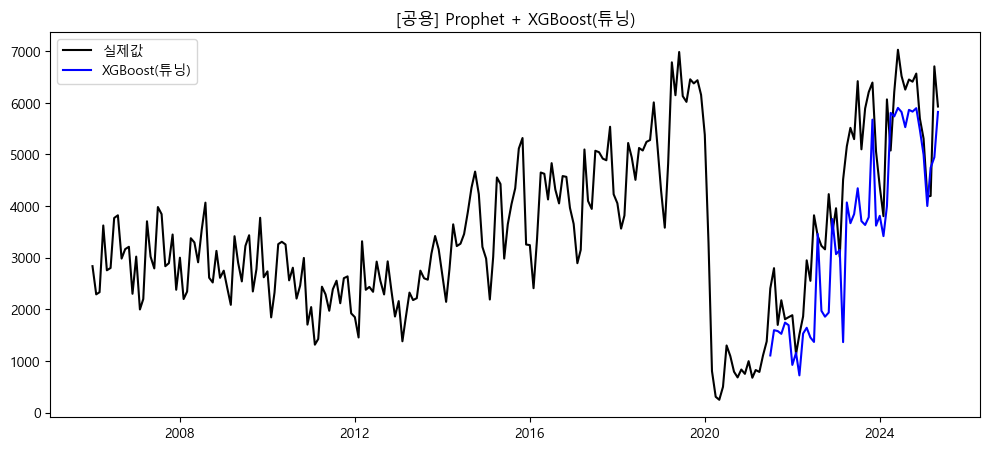

15:58:03 - cmdstanpy - INFO - Chain [1] start processing
15:58:03 - cmdstanpy - INFO - Chain [1] done processing
15:58:03 - cmdstanpy - ERROR - Chain [1] error: terminated by signal 3221225657 
Optimization terminated abnormally. Falling back to Newton.
15:58:03 - cmdstanpy - INFO - Chain [1] start processing
15:58:03 - cmdstanpy - INFO - Chain [1] done processing
15:58:03 - cmdstanpy - ERROR - Chain [1] error: terminated by signal 3221225657 
[I 2025-07-14 15:58:03,093] A new study created in memory with name: no-name-005ae0b3-b123-4d60-9af6-64416ed881ae
[I 2025-07-14 15:58:03,159] Trial 0 finished with value: 43678806642.15411 and parameters: {'max_depth': 4, 'learning_rate': 0.05057661444745359, 'n_estimators': 176, 'subsample': 0.7548392154975346}. Best is trial 0 with value: 43678806642.15411.
[I 2025-07-14 15:58:03,268] Trial 1 finished with value: 55909547050.46901 and parameters: {'max_depth': 5, 'learning_rate': 0.15048322746611936, 'n_estimators': 238, 'subsample': 0.82269001

❌ Prophet 학습 실패(관광): Error during optimization! Command 'C:\Users\Admin\anaconda3\envs\han\Lib\site-packages\prophet\stan_model\prophet_model.bin random seed=72303 data file=C:\Users\Admin\AppData\Local\Temp\tmppw5ue0mv\ztu0jpoy.json init=C:\Users\Admin\AppData\Local\Temp\tmppw5ue0mv\umq6gvg6.json output file=C:\Users\Admin\AppData\Local\Temp\tmppw5ue0mv\prophet_model67wj_qyy\prophet_model-20250714155803.csv method=optimize algorithm=newton iter=10000' failed: 


[I 2025-07-14 15:58:03,329] Trial 2 finished with value: 50705359097.259415 and parameters: {'max_depth': 2, 'learning_rate': 0.14358529985737858, 'n_estimators': 256, 'subsample': 0.8395792437404997}. Best is trial 0 with value: 43678806642.15411.
[I 2025-07-14 15:58:03,405] Trial 3 finished with value: 51156816162.49544 and parameters: {'max_depth': 6, 'learning_rate': 0.039251525828163554, 'n_estimators': 133, 'subsample': 0.7973574983743967}. Best is trial 0 with value: 43678806642.15411.
[I 2025-07-14 15:58:03,486] Trial 4 finished with value: 42335617366.359634 and parameters: {'max_depth': 5, 'learning_rate': 0.02140080691681297, 'n_estimators': 173, 'subsample': 0.9146568701064228}. Best is trial 4 with value: 42335617366.359634.
[I 2025-07-14 15:58:03,525] Trial 5 finished with value: 55410917204.89774 and parameters: {'max_depth': 2, 'learning_rate': 0.08908903423313656, 'n_estimators': 140, 'subsample': 0.8102408195670029}. Best is trial 4 with value: 42335617366.359634.
[I 

[관광] Prophet 예측 불가 (XGB만 사용)
[관광] XGBoost 예측 정확도 (테스트셋)
 - RMSE: 200769.7 / MAPE: 35.28% / R²: 0.830 → 👍 예측력 양호
[관광] Prophet 예측 없음 (XGB 결과만 참고)


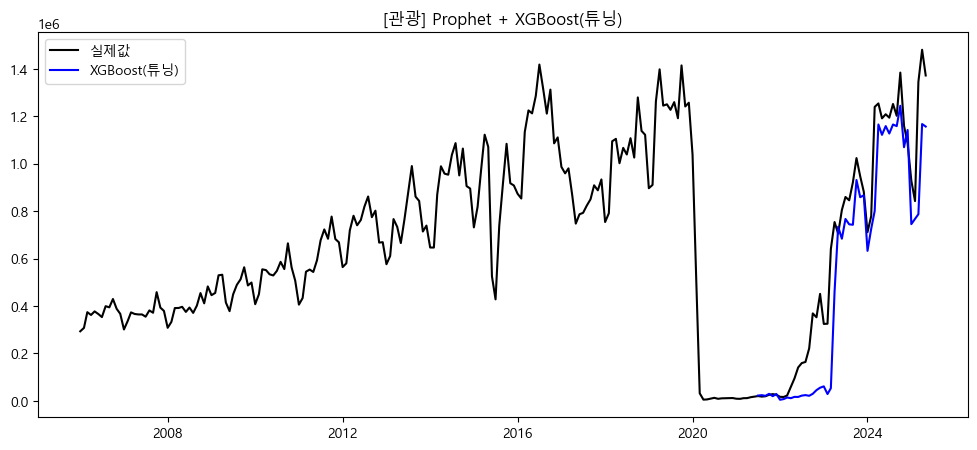

15:58:05 - cmdstanpy - INFO - Chain [1] start processing
15:58:05 - cmdstanpy - INFO - Chain [1] done processing
15:58:05 - cmdstanpy - ERROR - Chain [1] error: terminated by signal 3221225657 
Optimization terminated abnormally. Falling back to Newton.
15:58:05 - cmdstanpy - INFO - Chain [1] start processing
15:58:05 - cmdstanpy - INFO - Chain [1] done processing
15:58:05 - cmdstanpy - ERROR - Chain [1] error: terminated by signal 3221225657 
[I 2025-07-14 15:58:05,532] A new study created in memory with name: no-name-1cbc33fe-10bf-4e4e-9368-12fcf4234200
[I 2025-07-14 15:58:05,564] Trial 0 finished with value: 28983466.91455394 and parameters: {'max_depth': 2, 'learning_rate': 0.174090946512137, 'n_estimators': 107, 'subsample': 0.7206015871696434}. Best is trial 0 with value: 28983466.91455394.
[I 2025-07-14 15:58:05,640] Trial 1 finished with value: 42268439.20043189 and parameters: {'max_depth': 3, 'learning_rate': 0.07454338230017112, 'n_estimators': 267, 'subsample': 0.8497603277

❌ Prophet 학습 실패(상용): Error during optimization! Command 'C:\Users\Admin\anaconda3\envs\han\Lib\site-packages\prophet\stan_model\prophet_model.bin random seed=80071 data file=C:\Users\Admin\AppData\Local\Temp\tmppw5ue0mv\x6u6hl_o.json init=C:\Users\Admin\AppData\Local\Temp\tmppw5ue0mv\gmxnoz2t.json output file=C:\Users\Admin\AppData\Local\Temp\tmppw5ue0mv\prophet_modelr54_x5xj\prophet_model-20250714155805.csv method=optimize algorithm=newton iter=10000' failed: 


[I 2025-07-14 15:58:05,720] Trial 2 finished with value: 38315674.57909037 and parameters: {'max_depth': 6, 'learning_rate': 0.14608748642784664, 'n_estimators': 130, 'subsample': 0.8217705745537621}. Best is trial 0 with value: 28983466.91455394.
[I 2025-07-14 15:58:05,847] Trial 3 finished with value: 38748727.17304747 and parameters: {'max_depth': 6, 'learning_rate': 0.02725036424174531, 'n_estimators': 232, 'subsample': 0.9598939074049053}. Best is trial 0 with value: 28983466.91455394.
[I 2025-07-14 15:58:05,990] Trial 4 finished with value: 31402539.097005423 and parameters: {'max_depth': 6, 'learning_rate': 0.02301416887108184, 'n_estimators': 266, 'subsample': 0.8024906765785518}. Best is trial 0 with value: 28983466.91455394.
[I 2025-07-14 15:58:06,022] Trial 5 finished with value: 23345913.826582476 and parameters: {'max_depth': 4, 'learning_rate': 0.07943291589560873, 'n_estimators': 70, 'subsample': 0.7619977280629189}. Best is trial 5 with value: 23345913.826582476.
[I 202

[상용] Prophet 예측 불가 (XGB만 사용)
[상용] XGBoost 예측 정확도 (테스트셋)
 - RMSE: 3230.2 / MAPE: 68.58% / R²: 0.250 → ❗ 예측력 낮음 (참고용)
[상용] Prophet 예측 없음 (XGB 결과만 참고)


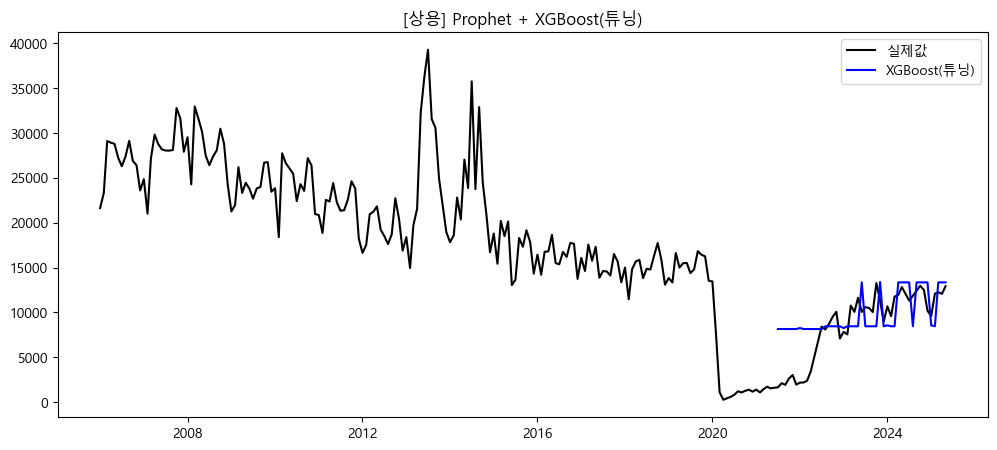

15:58:07 - cmdstanpy - INFO - Chain [1] start processing
15:58:07 - cmdstanpy - INFO - Chain [1] done processing
15:58:07 - cmdstanpy - ERROR - Chain [1] error: terminated by signal 3221225657 
Optimization terminated abnormally. Falling back to Newton.
15:58:07 - cmdstanpy - INFO - Chain [1] start processing
15:58:07 - cmdstanpy - INFO - Chain [1] done processing
15:58:07 - cmdstanpy - ERROR - Chain [1] error: terminated by signal 3221225657 
[I 2025-07-14 15:58:07,508] A new study created in memory with name: no-name-e331db74-8437-4de9-8829-7a7853bacf06
[I 2025-07-14 15:58:07,596] Trial 0 finished with value: 353465657.12670344 and parameters: {'max_depth': 6, 'learning_rate': 0.1087083142002958, 'n_estimators': 151, 'subsample': 0.9291709458926936}. Best is trial 0 with value: 353465657.12670344.
[I 2025-07-14 15:58:07,654] Trial 1 finished with value: 394339193.421194 and parameters: {'max_depth': 4, 'learning_rate': 0.03510458852549015, 'n_estimators': 140, 'subsample': 0.73949044

❌ Prophet 학습 실패(유학연수): Error during optimization! Command 'C:\Users\Admin\anaconda3\envs\han\Lib\site-packages\prophet\stan_model\prophet_model.bin random seed=61798 data file=C:\Users\Admin\AppData\Local\Temp\tmppw5ue0mv\k2mcwlmf.json init=C:\Users\Admin\AppData\Local\Temp\tmppw5ue0mv\s8qs8wjb.json output file=C:\Users\Admin\AppData\Local\Temp\tmppw5ue0mv\prophet_modeleyrirxwr\prophet_model-20250714155807.csv method=optimize algorithm=newton iter=10000' failed: 


[I 2025-07-14 15:58:07,789] Trial 2 finished with value: 411646437.9234917 and parameters: {'max_depth': 3, 'learning_rate': 0.13407483758806812, 'n_estimators': 288, 'subsample': 0.8041594454093807}. Best is trial 0 with value: 353465657.12670344.
[I 2025-07-14 15:58:07,816] Trial 3 finished with value: 420242516.9953955 and parameters: {'max_depth': 2, 'learning_rate': 0.11501822039837743, 'n_estimators': 87, 'subsample': 0.9400081044302442}. Best is trial 0 with value: 353465657.12670344.
[I 2025-07-14 15:58:07,928] Trial 4 finished with value: 327648176.13072795 and parameters: {'max_depth': 5, 'learning_rate': 0.17954549924389154, 'n_estimators': 242, 'subsample': 0.9782262364572287}. Best is trial 4 with value: 327648176.13072795.
[I 2025-07-14 15:58:07,973] Trial 5 finished with value: 362235478.39746726 and parameters: {'max_depth': 4, 'learning_rate': 0.13009967937660571, 'n_estimators': 106, 'subsample': 0.9183875857512159}. Best is trial 4 with value: 327648176.13072795.
[I 

[유학연수] Prophet 예측 불가 (XGB만 사용)
[유학연수] XGBoost 예측 정확도 (테스트셋)
 - RMSE: 18101.1 / MAPE: 38.19% / R²: 0.297 → ❗ 예측력 낮음 (참고용)
[유학연수] Prophet 예측 없음 (XGB 결과만 참고)


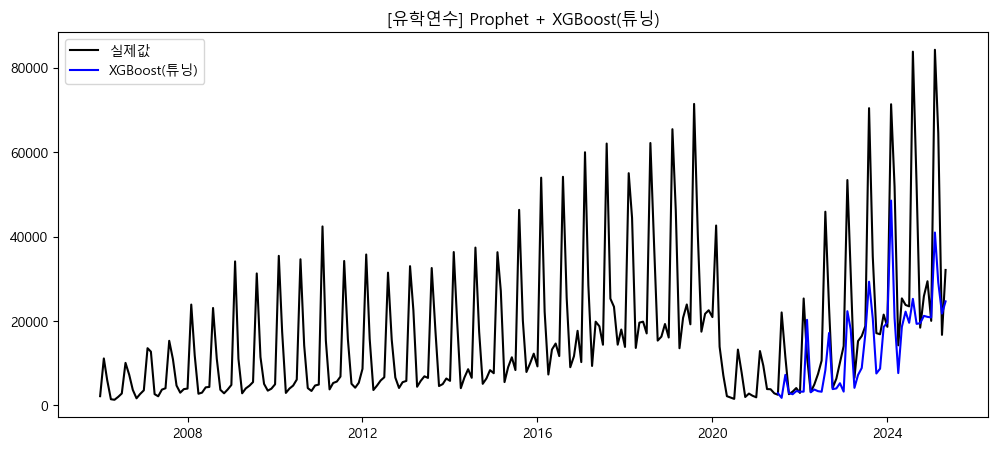


📅 원하는 연월 선택
+---------+---------+---------+---------+---------+---------+
| 2025-07 | 2025-08 | 2025-09 | 2025-10 | 2025-11 | 2025-12 |
+---------+---------+---------+---------+---------+---------+
| 2026-01 | 2026-02 | 2026-03 | 2026-04 | 2026-05 | 2026-06 |
+---------+---------+---------+---------+---------+---------+
| 2026-07 | 2026-08 | 2026-09 | 2026-10 | 2026-11 | 2026-12 |
+---------+---------+---------+---------+---------+---------+
| 2027-01 | 2027-02 | 2027-03 | 2027-04 | 2027-05 | 2027-06 |
+---------+---------+---------+---------+---------+---------+
| 2027-07 |         |         |         |         |         |
+---------+---------+---------+---------+---------+---------+


ValueError: invalid literal for int() with base 10: ''

In [20]:
import pandas as pd
import numpy as np
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
import optuna
import matplotlib.pyplot as plt
from datetime import datetime
from tabulate import tabulate

plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# === 데이터 로드 및 한글 깨짐 방지 ===
df = pd.read_csv('../data/외국인입국자_전처리완료_딥러닝용.csv')
df['성수기'] = df['월'].isin([7, 8, 12]).astype(int)
df['명절'] = df['월'].isin([1, 2, 9, 10]).astype(int)
df['코로나'] = (df['연도'] >= 2020).astype(int)
df['연월'] = df['연도'].astype(str) + '-' + df['월'].astype(str).str.zfill(2)

# === 입력 검증 함수 (공백, 대소문자 무시) ===
def normalize(text):
    return str(text).replace(' ', '').lower()

def match_input(user_input, valid_list):
    # 유사 입력 찾기(정확, 대소문자, 공백 무시)
    norm_input = normalize(user_input)
    norm_map = {normalize(x): x for x in valid_list}
    return norm_map.get(norm_input, None)

# === 국가 입력 ===
countries = sorted(df['국적'].unique())
while True:
    country = input(f"국적 입력(예시: {countries[0]} / 전체 Enter): ").strip()
    if not country:
        sel_country = None
        break
    found = match_input(country, countries)
    if found:
        sel_country = found
        break
    print("❗ 입력한 국적이 목록에 없음. 다시 입력하세요.")

# === 목적 입력 ===
purposes = sorted(df['목적'].unique())
while True:
    purpose = input(f"목적 입력(예시: {purposes[0]} / 전체 Enter): ").strip()
    if not purpose:
        sel_purpose = None
        break
    found = match_input(purpose, purposes)
    if found:
        sel_purpose = found
        break
    print("❗ 입력한 목적이 목록에 없음. 다시 입력하세요.")

# === 국가/목적 필터 ===
if sel_country:
    df = df[df['국적'] == sel_country]
else:
    print("🌍 국적 미선택 → 전체 사용")
if sel_purpose:
    df = df[df['목적'] == sel_purpose]
    print(f"선택 목적: {sel_purpose}")
else:
    print("🎯 목적 미선택 → 전체 사용")

purpose_list = [sel_purpose] if sel_purpose else df['목적'].unique()

# === 그룹핑(목적 미선택이면 합산) ===
if not sel_country:
    grouped = df.groupby(['연월', '목적', '성수기', '명절', '코로나'], as_index=False)['입국자수'].sum()
else:
    grouped = df.copy()

prophet_results = {}
xgb_results = {}
actuals = {}

def explain_score(r2, mape):
    if r2 >= 0.9:
        return "✅ 예측력 매우 우수 (신뢰도 높음)"
    elif r2 >= 0.7:
        return "👍 예측력 양호"
    elif r2 >= 0.5:
        return "⚠️ 예측력 보통 (개선 필요)"
    else:
        return "❗ 예측력 낮음 (참고용)"

def tune_xgb(X, y):
    def objective(trial):
        params = {
            'max_depth': trial.suggest_int('max_depth', 2, 6),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        }
        model = XGBRegressor(**params)
        X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, shuffle=False)
        model.fit(X_tr, y_tr)
        pred = model.predict(X_val)
        return np.mean((y_val - pred) ** 2)
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=20, show_progress_bar=False)
    return study.best_params

# === 메인 예측 루프 ===
for pur in purpose_list:
    temp = grouped[grouped['목적'] == pur].copy()
    if temp.empty or temp.shape[0] < 24:
        print(f"❌ 데이터 부족/없음: {pur} ({temp.shape[0]}행)")
        continue

    temp['ds'] = pd.to_datetime(temp['연월'])
    temp['y'] = temp['입국자수']

    # --- regressor 자동 예외처리 ---
    reg_cols = []
    for col in ['성수기', '명절', '코로나']:
        nun = temp[col].nunique()
        nan = temp[col].isna().sum()
        if nun > 1 and nan == 0:
            reg_cols.append(col)
        else:
            print(f"⚠️ Prophet regressor 제외: {col} (고정값/결측)")

    m = Prophet(yearly_seasonality=True)
    for col in reg_cols:
        m.add_regressor(col)
    fit_cols = ['ds', 'y'] + reg_cols
    temp[fit_cols] = temp[fit_cols].fillna(0)

    try:
        m.fit(temp[fit_cols])
        future = m.make_future_dataframe(periods=24, freq='M')
        future['월'] = future['ds'].dt.month
        if '성수기' in reg_cols:
            future['성수기'] = future['월'].isin([7, 8, 12]).astype(int)
        if '명절' in reg_cols:
            future['명절'] = future['월'].isin([1, 2, 9, 10]).astype(int)
        if '코로나' in reg_cols:
            future['코로나'] = (future['ds'].dt.year >= 2020).astype(int)
        forecast = m.predict(future)
        forecast[['yhat', 'yhat_lower', 'yhat_upper']] = forecast[['yhat', 'yhat_lower', 'yhat_upper']].clip(lower=0)
        prophet_results[pur] = forecast
    except Exception as e:
        print(f"❌ Prophet 학습 실패({pur}): {str(e)}")
        forecast = None

    # === XGB 피처 엔지니어링 ===
    temp['연도'] = temp['ds'].dt.year
    temp['월'] = temp['ds'].dt.month
    temp['lag_1'] = temp['y'].shift(1)
    temp['lag_3'] = temp['y'].shift(3)
    temp['lag_12'] = temp['y'].shift(12)
    temp = temp.dropna()
    features = ['연도', '월', 'lag_1', 'lag_3', 'lag_12', '성수기', '명절', '코로나']
    X = temp[features]
    y = temp['y']
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    best_params = tune_xgb(X_scaled, y)
    xgb = XGBRegressor(**best_params)
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, shuffle=False, test_size=0.2)
    xgb.fit(X_train, y_train)
    y_pred = xgb.predict(X_test)

    xgb_df = pd.DataFrame({
        'ds': temp.iloc[-len(y_test):]['ds'].values,
        'xgb_yhat': np.clip(y_pred, 0, None)
    })
    xgb_results[pur] = xgb_df
    actuals[pur] = temp

    # === 성능 평가 및 해석 ===
    if forecast is not None:
        real = temp['y'][-12:].values
        fcst = forecast['yhat'][:len(real)]
        rmse_p = np.sqrt(mean_squared_error(real, fcst))
        r2_p = r2_score(real, fcst)
        mape_p = mean_absolute_percentage_error(real, fcst) * 100
        print(f"\n[{pur}] Prophet 예측 정확도 (최근 12개월)")
        print(f" - RMSE: {rmse_p:.1f} / MAPE: {mape_p:.2f}% / R²: {r2_p:.3f} → {explain_score(r2_p, mape_p)}")
    else:
        print(f"[{pur}] Prophet 예측 불가 (XGB만 사용)")

    rmse_x = np.sqrt(mean_squared_error(y_test, y_pred))
    r2_x = r2_score(y_test, y_pred)
    mape_x = mean_absolute_percentage_error(y_test, y_pred) * 100
    print(f"[{pur}] XGBoost 예측 정확도 (테스트셋)")
    print(f" - RMSE: {rmse_x:.1f} / MAPE: {mape_x:.2f}% / R²: {r2_x:.3f} → {explain_score(r2_x, mape_x)}")

    if forecast is not None:
        last = forecast.iloc[-1]
        print(f"[{pur}] Prophet 미래 마지막달({last['ds'].strftime('%Y-%m')}) 예측값: {int(last['yhat']):,}명 (신뢰구간: {int(last['yhat_lower']):,} ~ {int(last['yhat_upper']):,})")
    else:
        print(f"[{pur}] Prophet 예측 없음 (XGB 결과만 참고)")

    # === 결과 시각화 ===
    plt.figure(figsize=(12,5))
    plt.plot(temp['ds'], temp['y'], label='실제값', color='black')
    if forecast is not None:
        plt.plot(forecast['ds'], forecast['yhat'], label='Prophet', color='red')
        plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'],
                         alpha=0.2, color='pink', label='Prophet 신뢰구간')
    plt.plot(xgb_df['ds'], xgb_df['xgb_yhat'], label='XGBoost(튜닝)', color='blue')
    plt.title(f"[{pur}] Prophet + XGBoost(튜닝)")
    plt.legend()
    plt.show()

# === 전체 목적 Prophet 합계(항상 출력) ===
if prophet_results:
    total_prophet = pd.concat([v for v in prophet_results.values() if v is not None]).groupby('ds').sum().reset_index()
    total_actuals = pd.concat(actuals.values()).groupby('ds').sum().reset_index()
    total_prophet[['yhat', 'yhat_lower', 'yhat_upper']] = total_prophet[['yhat', 'yhat_lower', 'yhat_upper']].clip(lower=0)
    real = total_actuals['y'][-12:].values
    fcst = total_prophet['yhat'][:len(real)]
    rmse_p = np.sqrt(mean_squared_error(real, fcst))
    r2_p = r2_score(real, fcst)
    mape_p = mean_absolute_percentage_error(real, fcst) * 100
    print(f"\n[전체 목적] Prophet 예측 정확도 (최근 12개월)")
    print(f" - RMSE: {rmse_p:.1f} / MAPE: {mape_p:.2f}% / R²: {r2_p:.3f} → {explain_score(r2_p, mape_p)}")

    last = total_prophet.iloc[-1]
    print(f"[전체 목적] Prophet 미래 마지막달({last['ds'].strftime('%Y-%m')}) 예측값: {int(last['yhat']):,}명 (신뢰구간: {int(last['yhat_lower']):,} ~ {int(last['yhat_upper']):,})")

    plt.figure(figsize=(14,6))
    plt.plot(total_actuals['ds'], total_actuals['y'], label='실제값 합계', color='black')
    plt.plot(total_prophet['ds'], total_prophet['yhat'], label='Prophet 합계', color='red')
    plt.fill_between(total_prophet['ds'], total_prophet['yhat_lower'], total_prophet['yhat_upper'],
                     alpha=0.3, color='pink', label='Prophet 신뢰구간')
    plt.title("모든 목적 Prophet 합계")
    plt.legend()
    plt.show()

# === 사용자 맞춤 월 예측 (월선택, 입력값 미리보기) ===
print("\n📅 원하는 연월 선택")
now = pd.to_datetime(datetime.now()).replace(day=1)
possible = pd.date_range(now, now + pd.DateOffset(months=24), freq='MS').strftime('%Y-%m').tolist()
rows = [possible[i:i+6] for i in range(0, len(possible), 6)]
print(tabulate(rows, tablefmt="grid"))

query = input("연월 입력 (202507 또는 2025-07): ").strip().replace('-', '')
if len(query) == 6:
    query = f"{query[:4]}-{query[4:]}"
query_input = query
query_year = int(query_input[:4])

if prophet_results:
    one_year_sum = total_prophet[total_prophet['ds'].dt.year == query_year]
    mask = one_year_sum['ds'].dt.strftime('%Y-%m') == query_input
    p2 = one_year_sum[mask]
    plt.figure(figsize=(12,5))
    plt.plot(one_year_sum['ds'], one_year_sum['yhat'], label='전체 Prophet', color='red')
    plt.fill_between(one_year_sum['ds'], one_year_sum['yhat_lower'], one_year_sum['yhat_upper'],
                     alpha=0.2, color='pink')
    ds_months = one_year_sum['ds'].dt.strftime('%Y-%m')
    if query_input in ds_months.values:
        row = one_year_sum[ds_months == query_input].iloc[0]
        y_val = row['yhat']
        yhat_low = row['yhat_lower']
        yhat_up = row['yhat_upper']
        plt.scatter(row['ds'], y_val, color='black', label='선택달')
        plt.annotate(f"{int(y_val):,}", xy=(row['ds'], y_val),
                     xytext=(0,10), textcoords='offset points',
                     ha='center', fontsize=10, color='black')
        print(f"\n[모든 목적 합계] {query_input} 예측: {int(y_val):,}명 (신뢰구간: {int(yhat_low):,} ~ {int(yhat_up):,})")
    else:
        after = one_year_sum[one_year_sum['ds'] > pd.to_datetime(query_input + '-01')]
        if not after.empty:
            row = after.iloc[0]
            y_val = row['yhat']
            yhat_low = row['yhat_lower']
            yhat_up = row['yhat_upper']
            print(f"❗ {query_input}는 없음. 가장 가까운 예측({row['ds'].strftime('%Y-%m')}): {int(y_val):,}명 (신뢰구간: {int(yhat_low):,} ~ {int(yhat_up):,})")
            plt.scatter(row['ds'], y_val, color='black', label='가까운 예측')
            plt.annotate(f"{int(y_val):,}", xy=(row['ds'], y_val),
                         xytext=(0,10), textcoords='offset points',
                         ha='center', fontsize=10, color='black')
        else:
            print(f"❗ {query_input} 이후 예측값 없음")
    plt.title(f"모든 목적 Prophet 합계 ({query_year})")
    plt.legend()
    plt.show()


In [2]:
import pandas as pd
import numpy as np
from prophet import Prophet
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import TimeSeriesSplit, train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from datetime import datetime
from tabulate import tabulate

plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# 1. 데이터 로드 및 파생변수 추가
df = pd.read_csv('../data/외국인입국자_전처리완료_딥러닝용.csv')
df['성수기'] = df['월'].isin([7, 8, 12]).astype(int)
df['명절'] = df['월'].isin([1, 2, 9, 10]).astype(int)
df['코로나'] = (df['연도'] >= 2020).astype(int)
df['연월'] = df['연도'].astype(str) + '-' + df['월'].astype(str).str.zfill(2)
df['lag_1'] = df['입국자수'].shift(1)
df['lag_3'] = df['입국자수'].shift(3)
df['lag_12'] = df['입국자수'].shift(12)
df['rolling_3']  = df.groupby(['국적','목적'])['입국자수'].transform(lambda x: x.rolling(3, min_periods=1).mean())
df['rolling_6']  = df.groupby(['국적','목적'])['입국자수'].transform(lambda x: x.rolling(6, min_periods=1).mean())
df['rolling_12'] = df.groupby(['국적','목적'])['입국자수'].transform(lambda x: x.rolling(12, min_periods=1).mean())
df['입국자수_cumsum'] = df.groupby(['국적','목적'])['입국자수'].cumsum()
df['yoy'] = df['입국자수'] / df['입국자수'].shift(12) - 1
df['log_y'] = np.log1p(df['입국자수'].clip(lower=0))
df = df.replace([np.inf, -np.inf], np.nan).dropna()

country = input("국적 입력 (없으면 Enter): ").strip()
purpose = input("목적 입력 (없으면 Enter): ").strip()

if country:
    df = df[df['국적'] == country]
else:
    print("🌍 국적 미선택 → 모든 나라 사용")

purpose_list = [purpose] if purpose else df['목적'].unique()

# groupby시 연도/월 파생 재생성
if not country:
    grouped = df.groupby(
        ['연월', '목적', '성수기', '명절', '코로나'], as_index=False
    ).agg({
        '입국자수':'sum',
        'lag_1':'sum',
        'lag_3':'sum',
        'lag_12':'sum',
        'rolling_3':'sum',
        'rolling_6':'sum',
        'rolling_12':'sum',
        'yoy':'mean',
        'log_y':'sum'
    })
    grouped['연도'] = grouped['연월'].str[:4].astype(int)
    grouped['월'] = grouped['연월'].str[-2:].astype(int)
else:
    grouped = df.copy()

prophet_results = {}
ml_results = {}
actuals = {}

def explain_score(r2, mape):
    if r2 >= 0.9:
        return "✅ 예측력 매우 우수 (신뢰도 높음)"
    elif r2 >= 0.7:
        return "👍 예측력 양호"
    elif r2 >= 0.5:
        return "⚠️ 예측력 보통 (개선 가능)"
    else:
        return "❗ 예측력 낮음 (참고용)"

# ML 하이퍼튜닝 (XGB+LGBM 지원)
def tune_ml(X, y, model='xgb'):
    tscv = TimeSeriesSplit(n_splits=3)
    if model == 'xgb':
        reg = XGBRegressor()
        param_grid = {
            'max_depth': [3, 4, 5],
            'learning_rate': [0.03, 0.05, 0.1],
            'n_estimators': [80, 100, 150],
            'subsample': [0.8, 1.0],
            'colsample_bytree': [0.7, 1.0]
        }
    else:
        reg = LGBMRegressor()
        param_grid = {
            'max_depth': [3, 4, 5],
            'learning_rate': [0.03, 0.05, 0.1],
            'n_estimators': [80, 100, 150],
            'subsample': [0.8, 1.0],
            'colsample_bytree': [0.7, 1.0]
        }
    grid = GridSearchCV(reg, param_grid, cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1)
    grid.fit(X, y)
    return grid.best_estimator_

for pur in purpose_list:
    temp = grouped[grouped['목적'] == pur].copy() if '목적' in grouped else grouped.copy()
    if temp.empty:
        print(f"❌ 데이터 없음: {pur}")
        continue

    temp['ds'] = pd.to_datetime(temp['연월'])
    temp['y'] = temp['입국자수']

    # Prophet (비교/시각화용)
    m = Prophet(yearly_seasonality=True)
    m.add_regressor('성수기')
    m.add_regressor('명절')
    m.add_regressor('코로나')
    m.fit(temp[['ds', 'y', '성수기', '명절', '코로나']])
    future = m.make_future_dataframe(periods=24, freq='M')
    future['월'] = future['ds'].dt.month
    future['성수기'] = future['월'].isin([7, 8, 12]).astype(int)
    future['명절'] = future['월'].isin([1, 2, 9, 10]).astype(int)
    future['코로나'] = (future['ds'].dt.year >= 2020).astype(int)
    forecast = m.predict(future)
    forecast[['yhat', 'yhat_lower', 'yhat_upper']] = forecast[['yhat', 'yhat_lower', 'yhat_upper']].clip(lower=0)
    prophet_results[pur] = forecast

    # ML 모델(XGB/LGBM)
    temp = temp.dropna()
    features = [
        '연도', '월', 'lag_1', 'lag_3', 'lag_12', 'rolling_3', 'rolling_6', 'rolling_12', 'yoy', '성수기', '명절', '코로나'
    ]
    X = temp[features].values
    y = temp['y'].values

    best_model = tune_ml(X, y, model='xgb')
    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]
    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_test)
    ml_df = pd.DataFrame({
        'ds': temp.iloc[-len(y_test):]['ds'].values,
        'ml_yhat': np.clip(y_pred, 0, None)
    })
    ml_results[pur] = ml_df
    actuals[pur] = temp

    # 예측 정확도 해석
    real = y[-12:]
    fcst = forecast['yhat'][:len(real)]
    rmse_p = np.sqrt(mean_squared_error(real, fcst))
    r2_p = r2_score(real, fcst)
    mape_p = mean_absolute_percentage_error(real, fcst) * 100
    print(f"\n[{pur}] Prophet 예측 정확도 (최근 12개월)")
    print(f" - RMSE: {rmse_p:.1f} / MAPE: {mape_p:.2f}% / R²: {r2_p:.3f} → {explain_score(r2_p, mape_p)}")

    rmse_ml = np.sqrt(mean_squared_error(y_test, y_pred))
    r2_ml = r2_score(y_test, y_pred)
    mape_ml = mean_absolute_percentage_error(y_test, y_pred) * 100
    print(f"[{pur}] XGBoost 예측 정확도 (테스트셋)")
    print(f" - RMSE: {rmse_ml:.1f} / MAPE: {mape_ml:.2f}% / R²: {r2_ml:.3f} → {explain_score(r2_ml, mape_ml)}")

    last = forecast.iloc[-1]
    print(f"[{pur}] Prophet 미래 마지막달({last['ds'].strftime('%Y-%m')}) 예측값: {int(last['yhat']):,}명 (신뢰구간: {int(last['yhat_lower']):,} ~ {int(last['yhat_upper']):,})")

    plt.figure(figsize=(12,5))
    plt.plot(temp['ds'], temp['y'], label='실제값', color='black')
    plt.plot(forecast['ds'], forecast['yhat'], label='Prophet', color='red')
    plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'],
                     alpha=0.2, color='pink', label='Prophet 신뢰구간')
    plt.plot(ml_df['ds'], ml_df['ml_yhat'], label='XGBoost(튜닝)', color='blue')
    plt.title(f"[{pur}] Prophet + XGBoost(튜닝)")
    plt.legend()
    plt.show()

# 전체 목적 Prophet 합계 (목적 미선택 시)
if not purpose:
    total_prophet = pd.concat(prophet_results.values()).groupby('ds').sum().reset_index()
    total_actuals = pd.concat(actuals.values()).groupby('ds').sum().reset_index()
    total_prophet[['yhat', 'yhat_lower', 'yhat_upper']] = total_prophet[['yhat', 'yhat_lower', 'yhat_upper']].clip(lower=0)
    real = total_actuals['y'][-12:].values
    fcst = total_prophet['yhat'][:len(real)]
    rmse_p = np.sqrt(mean_squared_error(real, fcst))
    r2_p = r2_score(real, fcst)
    mape_p = mean_absolute_percentage_error(real, fcst) * 100
    print(f"\n[전체 목적] Prophet 예측 정확도 (최근 12개월)")
    print(f" - RMSE: {rmse_p:.1f} / MAPE: {mape_p:.2f}% / R²: {r2_p:.3f} → {explain_score(r2_p, mape_p)}")

    last = total_prophet.iloc[-1]
    print(f"[전체 목적] Prophet 미래 마지막달({last['ds'].strftime('%Y-%m')}) 예측값: {int(last['yhat']):,}명 (신뢰구간: {int(last['yhat_lower']):,} ~ {int(last['yhat_upper']):,})")

    plt.figure(figsize=(14,6))
    plt.plot(total_actuals['ds'], total_actuals['y'], label='실제값 합계', color='black')
    plt.plot(total_prophet['ds'], total_prophet['yhat'], label='Prophet 합계', color='red')
    plt.fill_between(total_prophet['ds'], total_prophet['yhat_lower'], total_prophet['yhat_upper'],
                     alpha=0.3, color='pink', label='Prophet 신뢰구간')
    plt.title("모든 목적 Prophet 합계")
    plt.legend()
    plt.show()

# 원하는 연월 예측
print("\n📅 원하는 연월 선택")
now = pd.to_datetime(datetime.now()).replace(day=1)
possible = pd.date_range(now, now + pd.DateOffset(months=24), freq='MS').strftime('%Y-%m').tolist()
rows = [possible[i:i+6] for i in range(0, len(possible), 6)]
print(tabulate(rows, tablefmt="grid"))

query = input("연월 입력 (202507 또는 2025-07): ").strip().replace('-', '')
if len(query) == 6:
    query = f"{query[:4]}-{query[4:]}"
query_input = query
query_year = int(query_input[:4])

if purpose:
    fc = prophet_results[purpose]
    fc[['yhat', 'yhat_lower', 'yhat_upper']] = fc[['yhat', 'yhat_lower', 'yhat_upper']].clip(lower=0)
    one_year = fc[fc['ds'].dt.year == query_year]
    mask = one_year['ds'].dt.strftime('%Y-%m') == query_input
    point = one_year[mask]
    plt.figure(figsize=(12,5))
    plt.plot(one_year['ds'], one_year['yhat'], label='Prophet', color='red')
    plt.fill_between(one_year['ds'], one_year['yhat_lower'], one_year['yhat_upper'],
                     alpha=0.3, color='pink')
    ml = ml_results[purpose]
    ml_year = ml[ml['ds'].dt.year == query_year]
    plt.plot(ml_year['ds'], ml_year['ml_yhat'], label='XGBoost(튜닝)', color='blue')
    if not point.empty:
        row = point.iloc[0]
        y_val = row['yhat']
        yhat_low = row['yhat_lower']
        yhat_up = row['yhat_upper']
        plt.scatter(row['ds'], y_val, color='black', label='선택달')
        plt.annotate(f"{int(y_val):,}", xy=(row['ds'], y_val),
                     xytext=(0,10), textcoords='offset points',
                     ha='center', fontsize=10, color='black')
        print(f"\n[{purpose}] {query_input} 예측: {int(y_val):,}명 (신뢰구간: {int(yhat_low):,} ~ {int(yhat_up):,})")
    else:
        next_point = one_year[one_year['ds'] > pd.to_datetime(query_input + "-01")].head(1)
        if not next_point.empty:
            row = next_point.iloc[0]
            y_val = row['yhat']
            yhat_low = row['yhat_lower']
            yhat_up = row['yhat_upper']
            print(f"❗ 정확히 {query_input} 예측값은 없음. 가장 가까운 예측({row['ds'].strftime('%Y-%m')}): {int(y_val):,}명 (신뢰구간: {int(yhat_low):,} ~ {int(yhat_up):,})")
            plt.scatter(row['ds'], y_val, color='black', label='가까운 예측')
            plt.annotate(f"{int(y_val):,}", xy=(row['ds'], y_val),
                         xytext=(0,10), textcoords='offset points',
                         ha='center', fontsize=10, color='black')
        else:
            print(f"❗ {purpose} {query_input} 데이터 없음")
    plt.title(f"{purpose} Prophet+XGB ({query_year})")
    plt.legend()
    plt.show()

    # 전체 Prophet 합계
    total_prophet = pd.concat(prophet_results.values()).groupby('ds').sum().reset_index()
    total_prophet[['yhat', 'yhat_lower', 'yhat_upper']] = total_prophet[['yhat', 'yhat_lower', 'yhat_upper']].clip(lower=0)
    one_year_sum = total_prophet[total_prophet['ds'].dt.year == query_year]
    mask = one_year_sum['ds'].dt.strftime('%Y-%m') == query_input
    p2 = one_year_sum[mask]
    plt.figure(figsize=(12,5))
    plt.plot(one_year_sum['ds'], one_year_sum['yhat'], label='전체 Prophet', color='red')
    plt.fill_between(one_year_sum['ds'], one_year_sum['yhat_lower'], one_year_sum['yhat_upper'],
                     alpha=0.2, color='pink')
    if not p2.empty:
        row = p2.iloc[0]
        y_val = row['yhat']
        yhat_low = row['yhat_lower']
        yhat_up = row['yhat_upper']
        plt.scatter(row['ds'], y_val, color='black', label='선택달')
        plt.annotate(f"{int(y_val):,}", xy=(row['ds'], y_val),
                     xytext=(0,10), textcoords='offset points',
                     ha='center', fontsize=10, color='black')
        print(f"[모든 목적 합계] {query_input} 예측: {int(y_val):,}명 (신뢰구간: {int(yhat_low):,} ~ {int(yhat_up):,})")
    else:
        next_point = one_year_sum[one_year_sum['ds'] > pd.to_datetime(query_input + "-01")].head(1)
        if not next_point.empty:
            row = next_point.iloc[0]
            y_val = row['yhat']
            yhat_low = row['yhat_lower']
            yhat_up = row['yhat_upper']
            print(f"❗ 정확히 {query_input} 예측값은 없음. 가장 가까운 예측({row['ds'].strftime('%Y-%m')}): {int(y_val):,}명 (신뢰구간: {int(yhat_low):,} ~ {int(yhat_up):,})")
            plt.scatter(row['ds'], y_val, color='black', label='가까운 예측')
            plt.annotate(f"{int(y_val):,}", xy=(row['ds'], y_val),
                         xytext=(0,10), textcoords='offset points',
                         ha='center', fontsize=10, color='black')
        else:
            print(f"❗ 전체 목적 {query_input} 데이터 없음")
    plt.title(f"모든 목적 Prophet 합계 ({query_year})")
    plt.legend()
    plt.show()

if not purpose:
    one_year_sum = total_prophet[total_prophet['ds'].dt.year == query_year]
    one_year_sum[['yhat', 'yhat_lower', 'yhat_upper']] = one_year_sum[['yhat', 'yhat_lower', 'yhat_upper']].clip(lower=0)
    mask = one_year_sum['ds'].dt.strftime('%Y-%m') == query_input
    p2 = one_year_sum[mask]
    plt.figure(figsize=(12,5))
    plt.plot(one_year_sum['ds'], one_year_sum['yhat'], label='전체 Prophet', color='red')
    plt.fill_between(one_year_sum['ds'], one_year_sum['yhat_lower'], one_year_sum['yhat_upper'],
                     alpha=0.2, color='pink')
    ds_months = one_year_sum['ds'].dt.strftime('%Y-%m')
    if query_input in ds_months.values:
        row = one_year_sum[ds_months == query_input].iloc[0]
        y_val = row['yhat']
        yhat_low = row['yhat_lower']
        yhat_up = row['yhat_upper']
        plt.scatter(row['ds'], y_val, color='black', label='선택달')
        plt.annotate(f"{int(y_val):,}", xy=(row['ds'], y_val),
                     xytext=(0,10), textcoords='offset points',
                     ha='center', fontsize=10, color='black')
        print(f"\n[모든 목적 합계] {query_input} 예측: {int(y_val):,}명 (신뢰구간: {int(yhat_low):,} ~ {int(yhat_up):,})")
    else:
        after = one_year_sum[one_year_sum['ds'] > pd.to_datetime(query_input + '-01')]
        if not after.empty:
            row = after.iloc[0]
            y_val = row['yhat']
            yhat_low = row['yhat_lower']
            yhat_up = row['yhat_upper']
            print(f"❗ {query_input}는 없음. 가장 가까운 예측({row['ds'].strftime('%Y-%m')}): {int(y_val):,}명 (신뢰구간: {int(yhat_low):,} ~ {int(yhat_up):,})")
            plt.scatter(row['ds'], y_val, color='black', label='가까운 예측')
            plt.annotate(f"{int(y_val):,}", xy=(row['ds'], y_val),
                         xytext=(0,10), textcoords='offset points',
                         ha='center', fontsize=10, color='black')
        else:
            print(f"❗ {query_input} 이후 예측값 없음")
    plt.title(f"모든 목적 Prophet 합계 ({query_year})")
    plt.legend()
    plt.show()


ModuleNotFoundError: No module named 'prophet'

🌍 모든 나라 사용


15:46:07 - cmdstanpy - INFO - Chain [1] start processing
15:46:07 - cmdstanpy - INFO - Chain [1] done processing
15:46:07 - cmdstanpy - ERROR - Chain [1] error: terminated by signal 3221225657 
Optimization terminated abnormally. Falling back to Newton.
15:46:08 - cmdstanpy - INFO - Chain [1] start processing
15:46:08 - cmdstanpy - INFO - Chain [1] done processing
15:46:08 - cmdstanpy - ERROR - Chain [1] error: terminated by signal 3221225657 


❌ Prophet 실패(공용): Error during optimization! Command 'C:\Users\Admin\anaconda3\envs\han\Lib\site-packages\prophet\stan_model\prophet_model.bin random seed=15495 data file=C:\Users\Admin\AppData\Local\Temp\tmppw5ue0mv\800d3po_.json init=C:\Users\Admin\AppData\Local\Temp\tmppw5ue0mv\ua9a6ztr.json output file=C:\Users\Admin\AppData\Local\Temp\tmppw5ue0mv\prophet_modelj5y3pp6d\prophet_model-20250714154608.csv method=optimize algorithm=newton iter=10000' failed: , XGB만 적용
[공용] XGBoost 예측 정확도 (테스트셋)
 - RMSE: 16.7 / MAPE: 241584446138115136.00% / R²: 0.927 → ✅ 예측력 매우 우수 (신뢰도 높음)


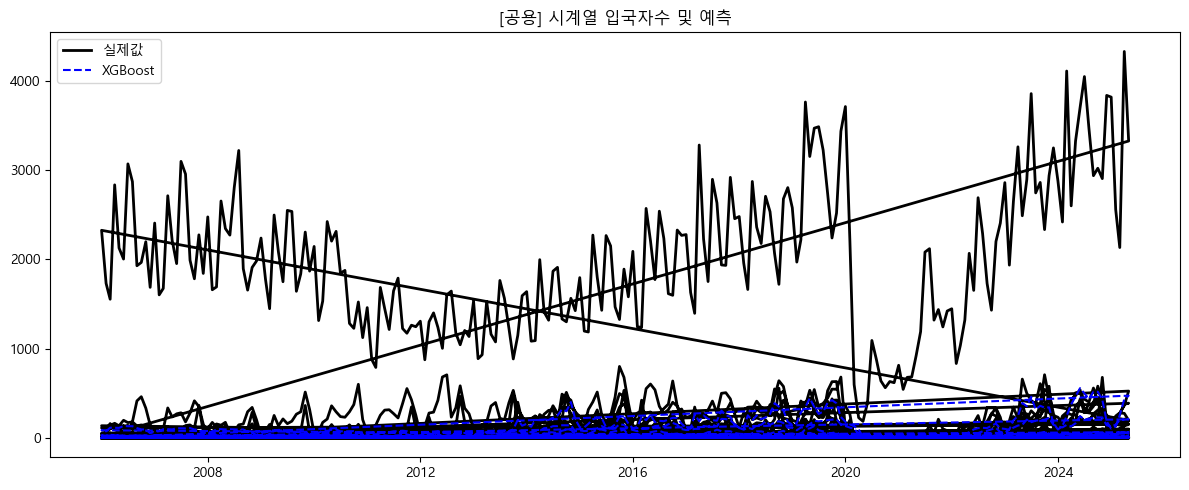

15:46:10 - cmdstanpy - INFO - Chain [1] start processing
15:46:10 - cmdstanpy - INFO - Chain [1] done processing
15:46:10 - cmdstanpy - ERROR - Chain [1] error: terminated by signal 3221225657 
Optimization terminated abnormally. Falling back to Newton.
15:46:11 - cmdstanpy - INFO - Chain [1] start processing
15:46:11 - cmdstanpy - INFO - Chain [1] done processing
15:46:11 - cmdstanpy - ERROR - Chain [1] error: terminated by signal 3221225657 


❌ Prophet 실패(관광): Error during optimization! Command 'C:\Users\Admin\anaconda3\envs\han\Lib\site-packages\prophet\stan_model\prophet_model.bin random seed=61472 data file=C:\Users\Admin\AppData\Local\Temp\tmppw5ue0mv\34nv1e_h.json init=C:\Users\Admin\AppData\Local\Temp\tmppw5ue0mv\1q3e2bc8.json output file=C:\Users\Admin\AppData\Local\Temp\tmppw5ue0mv\prophet_model6xs38p3q\prophet_model-20250714154611.csv method=optimize algorithm=newton iter=10000' failed: , XGB만 적용
[관광] XGBoost 예측 정확도 (테스트셋)
 - RMSE: 2566.0 / MAPE: 3507410414691181568.00% / R²: 0.955 → ✅ 예측력 매우 우수 (신뢰도 높음)


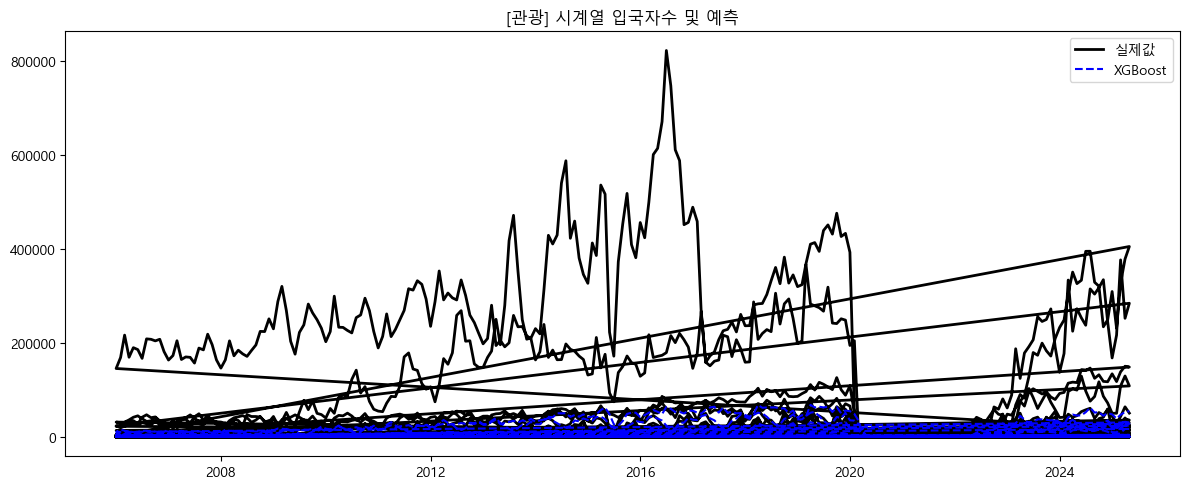

15:46:13 - cmdstanpy - INFO - Chain [1] start processing
15:46:13 - cmdstanpy - INFO - Chain [1] done processing
15:46:13 - cmdstanpy - ERROR - Chain [1] error: terminated by signal 3221225657 
Optimization terminated abnormally. Falling back to Newton.
15:46:14 - cmdstanpy - INFO - Chain [1] start processing
15:46:14 - cmdstanpy - INFO - Chain [1] done processing
15:46:14 - cmdstanpy - ERROR - Chain [1] error: terminated by signal 3221225657 


❌ Prophet 실패(상용): Error during optimization! Command 'C:\Users\Admin\anaconda3\envs\han\Lib\site-packages\prophet\stan_model\prophet_model.bin random seed=68771 data file=C:\Users\Admin\AppData\Local\Temp\tmppw5ue0mv\4igqh1n5.json init=C:\Users\Admin\AppData\Local\Temp\tmppw5ue0mv\ou7c11kc.json output file=C:\Users\Admin\AppData\Local\Temp\tmppw5ue0mv\prophet_modelbmah7b0b\prophet_model-20250714154614.csv method=optimize algorithm=newton iter=10000' failed: , XGB만 적용
[상용] XGBoost 예측 정확도 (테스트셋)
 - RMSE: 21.9 / MAPE: 815285754084533504.00% / R²: 0.961 → ✅ 예측력 매우 우수 (신뢰도 높음)


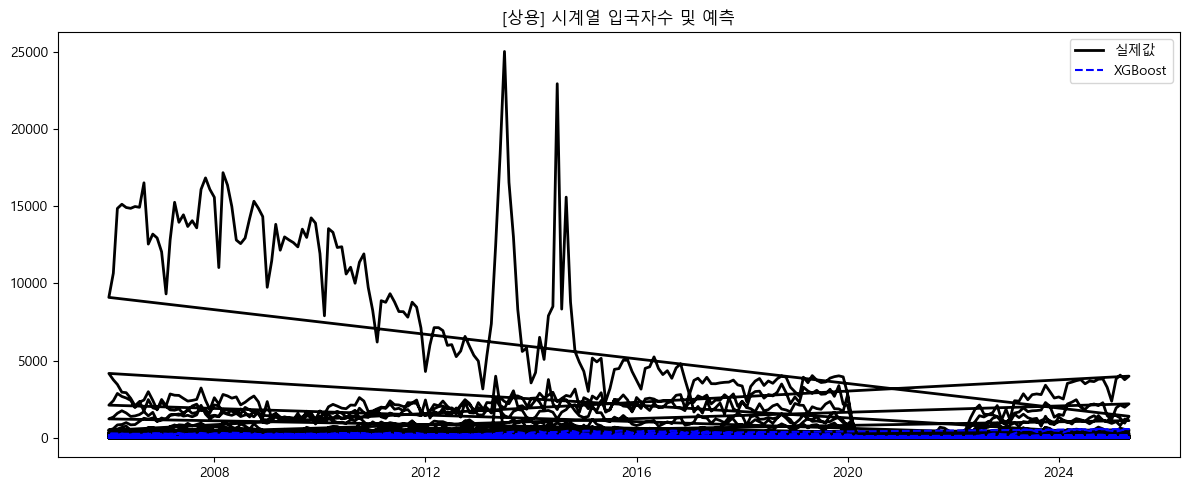

15:46:16 - cmdstanpy - INFO - Chain [1] start processing
15:46:16 - cmdstanpy - INFO - Chain [1] done processing
15:46:16 - cmdstanpy - ERROR - Chain [1] error: terminated by signal 3221225657 
Optimization terminated abnormally. Falling back to Newton.
15:46:17 - cmdstanpy - INFO - Chain [1] start processing
15:46:17 - cmdstanpy - INFO - Chain [1] done processing
15:46:17 - cmdstanpy - ERROR - Chain [1] error: terminated by signal 3221225657 


❌ Prophet 실패(유학연수): Error during optimization! Command 'C:\Users\Admin\anaconda3\envs\han\Lib\site-packages\prophet\stan_model\prophet_model.bin random seed=28003 data file=C:\Users\Admin\AppData\Local\Temp\tmppw5ue0mv\svorn3de.json init=C:\Users\Admin\AppData\Local\Temp\tmppw5ue0mv\rg3rj5tv.json output file=C:\Users\Admin\AppData\Local\Temp\tmppw5ue0mv\prophet_modelwniufibg\prophet_model-20250714154617.csv method=optimize algorithm=newton iter=10000' failed: , XGB만 적용
[유학연수] XGBoost 예측 정확도 (테스트셋)
 - RMSE: 39.7 / MAPE: 934801057411048576.00% / R²: 0.910 → ✅ 예측력 매우 우수 (신뢰도 높음)


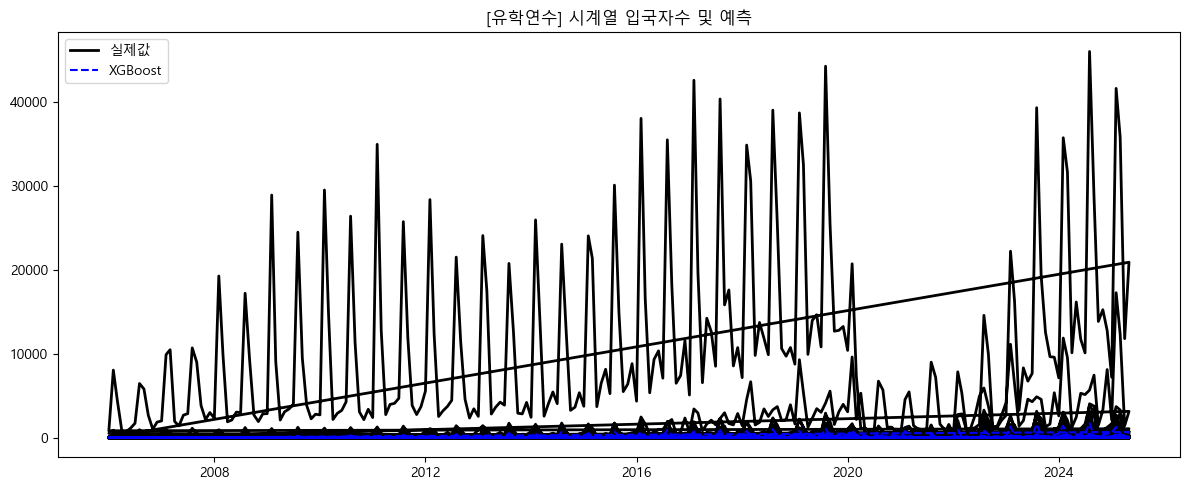


📅 원하는 연월 선택 (예시: 202501, 2025-01, ...)
+---------+---------+---------+---------+---------+---------+
| 2005-01 | 2005-02 | 2005-03 | 2005-04 | 2005-05 | 2005-06 |
+---------+---------+---------+---------+---------+---------+
| 2005-07 | 2005-08 | 2005-09 | 2005-10 | 2005-11 | 2005-12 |
+---------+---------+---------+---------+---------+---------+
| 2006-01 | 2006-02 | 2006-03 | 2006-04 | 2006-05 | 2006-06 |
+---------+---------+---------+---------+---------+---------+
| 2006-07 | 2006-08 | 2006-09 | 2006-10 | 2006-11 | 2006-12 |
+---------+---------+---------+---------+---------+---------+
| 2007-01 | 2007-02 | 2007-03 | 2007-04 | 2007-05 | 2007-06 |
+---------+---------+---------+---------+---------+---------+
| 2007-07 | 2007-08 | 2007-09 | 2007-10 | 2007-11 | 2007-12 |
+---------+---------+---------+---------+---------+---------+
| 2008-01 | 2008-02 | 2008-03 | 2008-04 | 2008-05 | 2008-06 |
+---------+---------+---------+---------+---------+---------+
| 2008-07 | 2008-08 | 2008-09 

In [17]:
import pandas as pd
import numpy as np
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from datetime import datetime
from tabulate import tabulate

plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# 데이터 로드 (한글 깨짐 방지, 경로 주의)
df = pd.read_csv('../data/외국인입국자_전처리완료_딥러닝용.csv', encoding='utf-8')
df['분기'] = ((df['월']-1)//3 + 1)
df['계절'] = df['월'].map({12:'겨울',1:'겨울',2:'겨울',3:'봄',4:'봄',5:'봄',6:'여름',7:'여름',8:'여름',9:'가을',10:'가을',11:'가을'})
df['코로나기간'] = (df['연도']>=2020).astype(int)
df['성수기'] = df['월'].isin([7,8,12]).astype(int)
df['명절'] = df['월'].isin([1,2,9,10]).astype(int)
df['연월'] = df['연도'].astype(str)+'-'+df['월'].astype(str).str.zfill(2)

# ========== 입력 검증 함수 ==========
def match_user_input(prompt, unique_vals):
    unique_clean = [v.strip().lower().replace(' ','') for v in unique_vals]
    while True:
        inp = input(prompt).strip().lower().replace(' ','')
        if not inp:
            return None
        matches = [unique_vals[i] for i, val in enumerate(unique_clean) if val == inp]
        if matches:
            return matches[0]
        else:
            print(f"❌ 일치하는 값이 없습니다. 다시 입력하세요. 가능 목록: {unique_vals}")

# 입력
country = match_user_input("국적 입력 (엔터시 전체): ", df['국적'].unique())
purpose = match_user_input("목적 입력 (엔터시 전체): ", df['목적'].unique())

# 데이터 필터링
if country:
    df = df[df['국적']==country]
else:
    print("🌍 모든 나라 사용")

purpose_list = [purpose] if purpose else sorted(df['목적'].unique())

# ====== 피처 엔지니어링 (목적, 국적별) ======
group_keys = ['국적', '목적']
for col, func, window in [
    ('lag_1', 'shift', 1),
    ('lag_3', 'shift', 3),
    ('lag_12', 'shift',12),
    ('cumsum', 'cumsum', None),
    ('rolling_3','rolling',3),
    ('rolling_6','rolling',6),
    ('rolling_12','rolling',12)
]:
    if func=='shift':
        df[col] = df.groupby(group_keys)['입국자수'].shift(window)
    elif func=='cumsum':
        df[col] = df.groupby(group_keys)['입국자수'].cumsum()
    elif func=='rolling':
        df[col] = (
            df.groupby(group_keys)['입국자수']
            .rolling(window, min_periods=1).mean()
            .reset_index(level=group_keys, drop=True)
        )
# 수치 인코딩
le_dict = {}
for col in ['계절']:
    le = LabelEncoder()
    df[col+'_enc'] = le.fit_transform(df[col])
    le_dict[col] = le

# ========== MAIN LOOP ==========
prophet_results = {}
xgb_results = {}
actuals = {}
purpose_valid = []

for pur in purpose_list:
    temp = df[df['목적']==pur].copy()
    if temp.empty:
        print(f"❌ 목적 '{pur}' 데이터 없음")
        continue

    # 예측 피처 선정
    temp['ds'] = pd.to_datetime(temp['연월'])
    temp['y'] = temp['입국자수']
    fit_cols = ['ds','y','성수기','명절','코로나기간']

    # 결측, 이상값 row 제거
    for col in fit_cols:
        temp = temp[temp[col].notnull() & ~temp[col].isin([np.inf, -np.inf])]
    if temp.shape[0] < 18:
        print(f"❗ '{pur}' 데이터({temp.shape[0]})개: Prophet 미적용, XGB만 적용")
        # 나머지는 XGB만
        pass
    else:
        # regressor 상수 제외
        reg_list = [col for col in ['성수기','명절','코로나기간'] if temp[col].nunique()>1]
        m = Prophet(yearly_seasonality=True)
        for reg in reg_list: m.add_regressor(reg)
        try:
            m.fit(temp[['ds','y']+reg_list])
        except Exception as e:
            print(f"❌ Prophet 실패({pur}): {e}, XGB만 적용")
        else:
            future = m.make_future_dataframe(periods=24, freq='M')
            future['월'] = future['ds'].dt.month
            future['성수기'] = future['월'].isin([7,8,12]).astype(int)
            future['명절'] = future['월'].isin([1,2,9,10]).astype(int)
            future['코로나기간'] = (future['ds'].dt.year>=2020).astype(int)
            # regressor 컬럼 맞추기
            for reg in reg_list:
                if reg not in future.columns:
                    future[reg] = 0
            forecast = m.predict(future)
            forecast[['yhat','yhat_lower','yhat_upper']] = forecast[['yhat','yhat_lower','yhat_upper']].clip(lower=0)
            prophet_results[pur] = forecast
            purpose_valid.append(pur)

    # XGBoost
    # 피처 선택
    temp = temp.dropna()
    features = ['연도','월','분기','계절_enc','코로나기간','성수기','명절','lag_1','lag_3','lag_12','cumsum','rolling_3','rolling_6','rolling_12']
    # 문자 col 인코딩
    for c in features:
        if temp[c].dtype=='O':
            temp[c] = LabelEncoder().fit_transform(temp[c])
    X = temp[features]
    y = temp['y']
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, shuffle=False, test_size=0.2)
    xgb = XGBRegressor(n_estimators=120, learning_rate=0.07, max_depth=4)
    xgb.fit(X_train, y_train)
    y_pred = xgb.predict(X_test)
    y_pred = np.clip(y_pred, 0, None)

    xgb_df = pd.DataFrame({'ds': temp.iloc[-len(y_test):]['ds'].values,'xgb_yhat':y_pred})
    xgb_results[pur] = xgb_df
    actuals[pur] = temp

    # ==== 예측, 성능표 ====
    def explain_score(r2, mape):
        if r2 >= 0.9:
            return "✅ 예측력 매우 우수 (신뢰도 높음)"
        elif r2 >= 0.7:
            return "👍 예측력 양호"
        elif r2 >= 0.5:
            return "⚠️ 예측력 보통 (개선 필요)"
        else:
            return "❗ 예측력 낮음 (참고용)"

    # Prophet 평가 (과거 12개월 기준)
    if pur in prophet_results:
        fcst = prophet_results[pur]
        y_real = temp['y'][-12:].values
        y_fcst = fcst['yhat'][:len(y_real)]
        rmse_p = np.sqrt(mean_squared_error(y_real, y_fcst))
        r2_p = r2_score(y_real, y_fcst)
        mape_p = mean_absolute_percentage_error(y_real, y_fcst)*100
        print(f"\n[{pur}] Prophet 예측 정확도 (최근 12개월)")
        print(f" - RMSE: {rmse_p:.1f} / MAPE: {mape_p:.2f}% / R²: {r2_p:.3f} → {explain_score(r2_p, mape_p)}")
        last = fcst.iloc[-1]
        print(f"[{pur}] Prophet 미래 마지막달({last['ds'].strftime('%Y-%m')}) 예측값: {int(last['yhat']):,}명 (신뢰구간: {int(last['yhat_lower']):,} ~ {int(last['yhat_upper']):,})")

    # XGB
    rmse_x = np.sqrt(mean_squared_error(y_test, y_pred))
    r2_x = r2_score(y_test, y_pred)
    mape_x = mean_absolute_percentage_error(y_test, y_pred)*100
    print(f"[{pur}] XGBoost 예측 정확도 (테스트셋)")
    print(f" - RMSE: {rmse_x:.1f} / MAPE: {mape_x:.2f}% / R²: {r2_x:.3f} → {explain_score(r2_x, mape_x)}")

    # 그래프(시계열 변화)
    plt.figure(figsize=(12,5))
    plt.plot(temp['ds'], temp['y'], label='실제값', color='black', linewidth=2)
    if pur in prophet_results:
        plt.plot(fcst['ds'], fcst['yhat'], label='Prophet', color='red')
        plt.fill_between(fcst['ds'], fcst['yhat_lower'], fcst['yhat_upper'], alpha=0.2, color='pink', label='Prophet 신뢰구간')
    plt.plot(xgb_df['ds'], xgb_df['xgb_yhat'], label='XGBoost', color='blue', linestyle='--')
    plt.title(f"[{pur}] 시계열 입국자수 및 예측")
    plt.legend()
    plt.tight_layout()
    plt.show()

# 전체 목적 Prophet 합계는 항상 출력
if len(prophet_results)>0:
    total_prophet = pd.concat(prophet_results.values()).groupby('ds').sum().reset_index()
    total_actuals = pd.concat(actuals.values()).groupby('ds').sum().reset_index()
    total_prophet[['yhat','yhat_lower','yhat_upper']] = total_prophet[['yhat','yhat_lower','yhat_upper']].clip(lower=0)
    y_real = total_actuals['y'][-12:].values
    y_fcst = total_prophet['yhat'][:len(y_real)]
    rmse_p = np.sqrt(mean_squared_error(y_real, y_fcst))
    r2_p = r2_score(y_real, y_fcst)
    mape_p = mean_absolute_percentage_error(y_real, y_fcst)*100
    print(f"\n[전체 목적 합계] Prophet 예측 정확도 (최근 12개월)")
    print(f" - RMSE: {rmse_p:.1f} / MAPE: {mape_p:.2f}% / R²: {r2_p:.3f} → {explain_score(r2_p, mape_p)}")
    last = total_prophet.iloc[-1]
    print(f"[전체 목적 합계] 미래({last['ds'].strftime('%Y-%m')}) 예측값: {int(last['yhat']):,}명 (신뢰구간: {int(last['yhat_lower']):,} ~ {int(last['yhat_upper']):,})")
    plt.figure(figsize=(14,6))
    plt.plot(total_actuals['ds'], total_actuals['y'], label='실제값 합계', color='black')
    plt.plot(total_prophet['ds'], total_prophet['yhat'], label='Prophet 합계', color='red')
    plt.fill_between(total_prophet['ds'], total_prophet['yhat_lower'], total_prophet['yhat_upper'], alpha=0.2, color='pink', label='Prophet 신뢰구간')
    plt.title("전체 목적별 Prophet 합계 (모든 조건)")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ===== 원하는 월 예측 =====
print("\n📅 원하는 연월 선택 (예시: 202501, 2025-01, ...)")
possible_months = sorted(list(set(df['연월'])))
rows = [possible_months[i:i+6] for i in range(0, len(possible_months), 6)]
print(tabulate(rows, tablefmt="grid"))

while True:
    query = input("예측 연월 입력(예: 202507 또는 2025-07): ").strip().replace('-', '')
    if len(query)==6:
        query = f"{query[:4]}-{query[4:]}"
    if query not in possible_months:
        print("❌ 지원하는 연월이 아님. 위 표 참고.")
    else:
        break

# 예측값 출력(목적별+전체)
for pur in purpose_list:
    if pur in prophet_results:
        fcst = prophet_results[pur]
        mask = fcst['ds'].dt.strftime('%Y-%m')==query
        if mask.any():
            row = fcst[mask].iloc[0]
            print(f"[{pur}] {query} 예측값: {int(row['yhat']):,}명 (신뢰구간: {int(row['yhat_lower']):,} ~ {int(row['yhat_upper']):,})")
        else:
            print(f"[{pur}] {query} 예측 데이터 없음")

if len(prophet_results)>0:
    mask = total_prophet['ds'].dt.strftime('%Y-%m')==query
    if mask.any():
        row = total_prophet[mask].iloc[0]
        print(f"[전체 목적 합계] {query} 예측값: {int(row['yhat']):,}명 (신뢰구간: {int(row['yhat_lower']):,} ~ {int(row['yhat_upper']):,})")

